# Final Project Data Science Track

# **Apakah Sektor Pertanian di Negara-Negara Anggota G20 Masih Relevan?**
## **Menilai Berdasarkan Sosial-Ekonomi dan Produktivitas Sumber Daya di Era Ekonomi Hijau**

# **Smooth Operators**
- Alifia Septi Anggraeni
- Devina Salsabila
- Fransiscus Kristian Susanto
- Ines Putri Oktoviani
- Muhammad Aspa Zikra
- Sendhy Maula Ammarulloh

# **Business Understanding**

#### **Latar Belakang**
Sektor pertanian masih menjadi sumber utama pangan dan pekerjaan di banyak negara, tetapi di era ekonomi hijau yang mengutamakan keberlanjutan, pertanian sering dianggap kurang relevan. Negara-negara anggota G20, dengan perbedaan tingkat kemajuan ekonomi, memiliki ketergantungan yang bervariasi terhadap sektor ini. Penting untuk menilai apakah pertanian masih relevan dengan fokus pada teknologi hijau dan efisiensi sumber daya.

#### **Business Problem**
Di tengah berkembangnya ekonomi hijau, sektor pertanian di negara-negara G20 menghadapi tantangan besar untuk tetap relevan. Negara maju beralih ke sektor industri dan teknologi, sementara negara berkembang masih bergantung pada pertanian. Bagaimana sektor ini bisa beradaptasi untuk mendukung keberlanjutan dan produktivitas sumber daya alam?

#### **Expected Outcomes**
- Menilai relevansi sektor pertanian di negara-negara G20.
- Menyusun rekomendasi kebijakan untuk memastikan sektor pertanian tetap berkelanjutan di era hijau.
- Mengidentifikasi peluang dan tantangan sektor pertanian dengan pendekatan teknologi dan keberlanjutan.

# **Reference Dataset**
1. [Dataset OECD](https://data-explorer.oecd.org/vis?df[ds]=DisseminateFinalDMZ&df[id]=DSD_GG%40DF_GREEN_GROWTH&df[ag]=OECD.ENV.EPI&dq=.A...&pd=%2C&to[TIME_PERIOD]=false&vw=tb)
2. [Dataset World Bank](https://databank.worldbank.org/reports.aspx?source=2&Topic=19#)

# **Import Libraries**

In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.cm as cm

# **Data Understanding**

## **Data OECD**

In [2]:
# Menentukan URL API
url = "https://sdmx.oecd.org/public/rest/data/OECD.ENV.EPI,DSD_GG@DF_GREEN_GROWTH,/EU27_2020+USA+GBR+TUR+ZAF+SAU+RUS+MEX+KOR+JPN+ITA+IDN+IND+FRA+DEU+CHN+CAN+BRA+AUS+ARG..SOC+POPDEN+POP_NETMIGR+POP_LIFEEXP+POP_FERTILITY+POP_Y_GT65+POP_Y15T64+POP_Y_LT14+POP_F+ECO+DEF+PPP+XR+GDP_RCAP+LTAX+GDP_PC+GDP_R+MAT+PBAL_HA+NBAL_HA+MWAS_LANDF+MWAS_RECO+MWAS_INC+MWAS_INT+DMC_MET+DMC_MIN+DMC_BIO+DMC_PROD+NRG+RE_TPES_EBIOM+NRGC+RE_NRG+RE_TPES+NRGS+NRG_INT+NRG_PROD..?startPeriod=2020&endPeriod=2022&dimensionAtObservation=AllDimensions&format=csvfilewithlabels"

# Menentukan header untuk meminta data dalam format CSV
headers = {
    "Accept": "text/csv"
}

# Mengirim permintaan GET ke API
response = requests.get(url, headers=headers)

# Memeriksa apakah permintaan berhasil
if response.status_code == 200:
    # Mengubah konten CSV menjadi pandas DataFrame
    data_oecd = StringIO(response.text)
    data_oecd = pd.read_csv(data_oecd)
else:
    print(f"Gagal mengambil data. Kode status: {response.status_code}")


In [3]:
# Menampilkan beberapa baris pertama dari DataFrame
data_oecd.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,UNIT_MULT,Unit multiplier,PRICE_BASE,Price base,BASE_PER,Base period,TIMELINESS,Timeliness,DECIMALS,Decimals
0,DATAFLOW,OECD.ENV.EPI:DSD_GG@DF_GREEN_GROWTH(1.1),Green Growth,I,TUR,Türkiye,A,Annual,NRG,Energy productivity,...,0,Units,_Z,Not applicable,NaN,NaN,1,"1 year lag, timely",2,Two
1,DATAFLOW,OECD.ENV.EPI:DSD_GG@DF_GREEN_GROWTH(1.1),Green Growth,I,TUR,Türkiye,A,Annual,NRG,Energy productivity,...,0,Units,_Z,Not applicable,NaN,NaN,1,"1 year lag, timely",2,Two
2,DATAFLOW,OECD.ENV.EPI:DSD_GG@DF_GREEN_GROWTH(1.1),Green Growth,I,CHN,China (People’s Republic of),A,Annual,GDP_PC,Value added,...,0,Units,_Z,Not applicable,NaN,NaN,1,"1 year lag, timely",2,Two
3,DATAFLOW,OECD.ENV.EPI:DSD_GG@DF_GREEN_GROWTH(1.1),Green Growth,I,CHN,China (People’s Republic of),A,Annual,GDP_PC,Value added,...,0,Units,_Z,Not applicable,NaN,NaN,1,"1 year lag, timely",2,Two
4,DATAFLOW,OECD.ENV.EPI:DSD_GG@DF_GREEN_GROWTH(1.1),Green Growth,I,ARG,Argentina,A,Annual,POP_Y_LT14,"Population, ages 0-14",...,0,Units,_Z,Not applicable,NaN,NaN,1,"1 year lag, timely",2,Two


In [4]:
# Menampilkan informasi ringkas tentang DataFrame
data_oecd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2994 entries, 0 to 2993
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   STRUCTURE                 2994 non-null   object 
 1   STRUCTURE_ID              2994 non-null   object 
 2   STRUCTURE_NAME            2994 non-null   object 
 3   ACTION                    2994 non-null   object 
 4   REF_AREA                  2994 non-null   object 
 5   Reference area            2994 non-null   object 
 6   FREQ                      2994 non-null   object 
 7   Frequency of observation  2994 non-null   object 
 8   MEASURE                   2994 non-null   object 
 9   Measure                   2994 non-null   object 
 10  UNIT_MEASURE              2994 non-null   object 
 11  Unit of measure           2994 non-null   object 
 12  ACTIVITY                  2994 non-null   object 
 13  Economic activity         2994 non-null   object 
 14  TIME_PER

In [5]:
# Memilih beberapa fitur tertentu dari DataFrame bernama data_oecd
# Hasil pemilihan fitur-fitur tersebut disimpan dalam variabel baru bernama data_temp_oecd
data_temp_oecd = data_oecd[['Reference area', 'Measure', 'Unit of measure', 'TIME_PERIOD', 'OBS_VALUE']]

In [6]:
# menampilkan beberapa feature pertama dari DataFrame
data_temp_oecd.head()

,Reference area,Measure,Unit of measure,TIME_PERIOD,OBS_VALUE
0,Türkiye,Energy productivity,Unspecified,2021,NaN
1,Türkiye,Energy productivity,Unspecified,2020,NaN
2,China (People’s Republic of),Value added,Percentage of gross value added,2020,38.02
3,China (People’s Republic of),Value added,Percentage of gross value added,2022,39.50
4,Argentina,"Population, ages 0-14",Percentage of population,2020,23.70


In [7]:
# Menampilkan informasi ringkas tentang DataFrame data_temp_oecd
data_temp_oecd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2994 entries, 0 to 2993
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Reference area   2994 non-null   object 
 1   Measure          2994 non-null   object 
 2   Unit of measure  2994 non-null   object 
 3   TIME_PERIOD      2994 non-null   int64  
 4   OBS_VALUE        2143 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 117.1+ KB


## **Data World Bank**

In [8]:
# URL raw file CSV di GitHub
url = 'https://raw.githubusercontent.com/smoothoperatord/finalproject/refs/heads/main/df_world_bank.csv'

# Membaca file CSV dari URL
df_world_bank = pd.read_csv(url)

In [9]:
# Menampilkan beberapa baris pertama dari DataFrame df_world_bank
df_world_bank.head()

,Unnamed: 0,Country Name,Year,Employment in agriculture (% of total employment) (modeled ILO estimate)
0,0,Afghanistan,1999,65.3547357159493
1,1,Afghanistan,2000,65.3479607149601
2,2,Afghanistan,2001,65.2541894141999
3,3,Afghanistan,2002,63.9316149892018
4,4,Afghanistan,2003,63.2560905870357


In [10]:
# Menampilkan informasi ringkas tentang DataFrame df_world_bank
df_world_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 4 columns):
 #   Column                                                                    Non-Null Count  Dtype 
---  ------                                                                    --------------  ----- 
 0   Unnamed: 0                                                                6650 non-null   int64 
 1   Country Name                                                              6650 non-null   object
 2   Year                                                                      6650 non-null   int64 
 3   Employment in agriculture (% of total employment) (modeled ILO estimate)  6650 non-null   object
dtypes: int64(2), object(2)
memory usage: 207.9+ KB


# **Data Preparation**

## **Data Transformation**

### **Data OECD**

In [11]:
# Menggabungkan beberapa fitur
data_temp_oecd['Measure'] = data_temp_oecd['Measure'] + ' (' + data_temp_oecd['Unit of measure'] + ')'

<ipython-input-11-c00c71ead197>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_temp_oecd['Measure'] = data_temp_oecd['Measure'] + ' (' + data_temp_oecd['Unit of measure'] + ')'


In [12]:
# Menghapus fitur 'Unit of measure' dari DataFrame data_temp_oecd
data_temp_oecd = data_temp_oecd.drop(columns='Unit of measure')

In [13]:
# Menampilkan beberapa baris pertama dari DataFrame data_temp_oecd
data_temp_oecd.head()

,Reference area,Measure,TIME_PERIOD,OBS_VALUE
0,Türkiye,Energy productivity (Unspecified),2021,NaN
1,Türkiye,Energy productivity (Unspecified),2020,NaN
2,China (People’s Republic of),Value added (Percentage of gross value added),2020,38.02
3,China (People’s Republic of),Value added (Percentage of gross value added),2022,39.50
4,Argentina,"Population, ages 0-14 (Percentage of population)",2020,23.70


In [14]:
# Membuat pivot table dari DataFrame data_temp_oecd
df_pivot_oecd = data_temp_oecd.pivot_table(index=['TIME_PERIOD', 'Reference area'], columns='Measure', values='OBS_VALUE')

In [15]:
# Menampilkan beberapa baris pertama dari DataFrame df_pivot_oecd
df_pivot_oecd.head()

Measure                                   Consumption of biomass (Percentage of domestic material consumption)  \
TIME_PERIOD Reference area                                                                                       
2020        Argentina                                                                 75.53                      
            Australia                                                                 28.94                      
            Brazil                                                                    67.87                      
            Canada                                                                    24.37                      
            China (People’s Republic of)                                              14.20                      

Measure                                   Consumption of metals (Percentage of domestic material consumption)  \
TIME_PERIOD Reference area                                                                                      
2020        Argentina                                                                  3.63                     
            Australia                                                                 40.87                     
            Brazil                                                                     5.12                     
            Canada                                                                    19.19                     
            China (People’s Republic of)                                              10.58                     

Measure                                   Consumption of non-metallic minerals (Percentage of domestic material consumption)  \
TIME_PERIOD Reference area                                                                                                     
2020        Argentina                                                                 20.84                                    
            Australia                                                                 30.19                                    
            Brazil                                                                    27.01                                    
            Canada                                                                    56.45                                    
            China (People’s Republic of)                                              75.22                                    

Measure                                   Energy consumption (Percentage of energy consumption)  \
TIME_PERIOD Reference area                                                                        
2020        Argentina                                                                20.002       
            Australia                                                                20.000       
            Brazil                                                                   20.000       
            Canada                                                                   20.000       
            China (People’s Republic of)                                             20.000       

Measure                                   Energy intensity per capita (Tonnes of oil equivalent per person)  \
TIME_PERIOD Reference area                                                                                    
2020        Argentina                                                                  1.62                   
            Australia                                                                  5.23                   
            Brazil                                                                     1.36                   
            Canada                                                                     7.49                   
            China (People’s Republic of)                                               2.45                   

Measure                                 

In [16]:
# Mengatur ulang index pivot table agar fitur-fitur index menjadi kolom biasa
df_pivot_oecd.reset_index(inplace=True)

In [17]:
# Menampilkan beberapa baris pertama dari DataFrame df_pivot_oecd setelah reset index
df_pivot_oecd.head()

Measure,TIME_PERIOD,Reference area,Consumption of biomass (Percentage of domestic material consumption),Consumption of metals (Percentage of domestic material consumption),Consumption of non-metallic minerals (Percentage of domestic material consumption),Energy consumption (Percentage of energy consumption),Energy intensity per capita (Tonnes of oil equivalent per person),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",Female population (Percentage of population),GDP deflator (Index),...,"Real GDP (US dollars, PPP converted)","Real GDP per capita (US dollars per person, PPP converted)",Renewable electricity generation (Percentage of electricity generation),Renewable energy supply (Percentage of energy supply),Renewable energy supply (Tonnes of oil equivalent),Renewable energy supply (excluding solid biofuels) (Percentage of energy supply),Total energy supply (Index),Total energy supply (Tonnes of oil equivalent),Total fertility rate (Live births per woman),Value added (Percentage of gross value added)
0,2020,Argentina,75.53,3.63,20.84,20.002,1.62,10198.63,50.39,527.85,...,748576.50,16496.91,29.89,9.27,6801798.0,5.36,120.02,73.40,1.60,27.876667
1,2020,Australia,28.94,40.87,30.19,20.000,5.23,9445.68,50.38,111.89,...,1266869.38,49380.44,22.49,7.39,9906339.5,4.41,124.06,134.12,1.59,33.330000
2,2020,Brazil,67.87,5.12,27.01,20.000,1.36,10134.41,50.71,130.39,...,2909408.50,13739.46,83.17,47.99,137782919.7,21.66,152.56,287.08,1.65,33.333333
3,2020,Canada,24.37,19.19,56.45,20.000,7.49,5799.08,50.32,107.78,...,1650813.75,43434.28,66.99,16.89,48081354.5,13.77,112.85,284.67,1.41,33.333333
4,2020,China (People’s Republic of),14.20,10.58,75.22,20.000,2.45,6899.00,48.92,111.35,...,24070658.00,16892.52,28.24,9.75,340145926.6,6.60,307.89,3489.01,1.24,33.333333


**Deskripsi Dataset:**

Dataset ini berasal dari sumber data yang disediakan oleh **OECD** (Organisation for Economic Co-operation and Development) dan mencakup berbagai informasi terkait konsumsi energi, pasokan energi, produktivitas energi, pengelolaan limbah, serta indikator lingkungan lainnya di berbagai negara. Data ini digunakan untuk menganalisis pola penggunaan energi di negara-negara OECD, kontribusi energi terbarukan, intensitas energi per kapita, serta dampaknya terhadap produktivitas ekonomi dan keberlanjutan sumber daya alam. Selain itu, dataset ini juga memberikan wawasan mengenai pengelolaan limbah domestik dan keseimbangan nutrisi seperti nitrogen dan fosfor, yang sangat penting untuk memantau keberlanjutan pembangunan dalam negara-negara OECD.

**Kolom dalam Dataset:**


| **Nama Kolom**                                                                         | **Deskripsi**                                                                                                                                       |
|----------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------|
| **Female population (Percentage of population)**                                       | Persentase penduduk perempuan terhadap total populasi negara.                                                                                       |
| **GDP deflator (Index)**                                                               | Indeks deflator PDB yang digunakan untuk mengukur perubahan harga dalam ekonomi relatif terhadap tahun dasar tertentu.                              |
| **Labour tax revenue (Percentage of GDP)**                                             | Pendapatan pajak tenaga kerja sebagai persentase dari Produk Domestik Bruto (PDB).                                                                  |
| **Labour tax revenue (Percentage of tax revenue)**                                     | Pendapatan pajak tenaga kerja sebagai persentase dari total pendapatan pajak.                                                                       |
| **Life expectancy at birth (Years)**                                                   | Harapan hidup rata-rata saat lahir, diukur dalam tahun.                                                                                             |
| **Net migration (Persons)**                                                            | Jumlah migrasi bersih yang menunjukkan perbedaan antara jumlah pendatang dan orang yang pergi dari suatu negara.                                    |
| **Population density (Inhabitants per square kilometre)**                              | Kepadatan populasi di suatu wilayah, diukur dalam jumlah penduduk per kilometer persegi.                                                            |
| **Population, ages 0-14 (Percentage of population)**                                   | Persentase populasi dalam kelompok umur 0-14 tahun terhadap total populasi.                                                                         |
| **Population, ages 15-64 (Percentage of population)**                                  | Persentase populasi dalam kelompok umur 15-64 tahun terhadap total populasi.                                                                        |
| **Population, ages 65 and above (Percentage of population)**                           | Persentase populasi dalam kelompok umur 65 tahun ke atas terhadap total populasi.                                                                   |
| **Purchasing power parity (National currency per US dollar)**                          | Paritas daya beli yang menunjukkan nilai tukar mata uang nasional terhadap dolar AS, berdasarkan daya beli relatif.                                 |
| **Total fertility rate (Live births per woman)**                                       | Rata-rata jumlah kelahiran hidup per wanita selama masa suburnya.                                                                                   |
| **Value added (Percentage of gross value added)**                                      | Persentase nilai tambah yang dihasilkan oleh sektor tertentu terhadap total nilai tambah bruto suatu negara.                                         |
| **Country Name**                                                                       | Nama negara yang datanya tercantum dalam dataset.                                                                                                  |
| **Year**                                                                               | Tahun data dikumpulkan atau diestimasi.                                                                                                            |
| **Energy consumption (Percentage of energy consumption)**                              | Persentase konsumsi energi dari total konsumsi energi negara tersebut.                                                                             |
| **Energy intensity per capita (Tonnes of oil equivalent per person)**                  | Intensitas energi rata-rata per kapita, diukur dalam ton setara minyak per orang.                                                                  |
| **Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)**  | Produktivitas energi, dihitung sebagai PDB per satuan Total Energy Supply (TES), diukur dalam dolar AS per ton setara minyak.                       |
| **Real GDP (Index)**                                                                   | Indeks PDB riil berdasarkan nilai acuan tertentu untuk analisis tren ekonomi.                                                                      |
| **Real GDP (US dollars, PPP converted)**                                               | PDB riil negara dalam dolar AS yang dikonversi dengan metode Purchasing Power Parity (PPP).                                                        |
| **Renewable electricity generation (Percentage of electricity generation)**            | Persentase listrik yang dihasilkan dari sumber energi terbarukan dibandingkan dengan total produksi listrik.                                        |
| **Renewable energy supply (Percentage of energy supply)**                              | Persentase pasokan energi yang berasal dari sumber energi terbarukan dibandingkan dengan total pasokan energi.                                      |
| **Renewable energy supply (Tonnes of oil equivalent)**                                 | Jumlah pasokan energi dari sumber energi terbarukan, diukur dalam ton setara minyak.                                                               |
| **Renewable energy supply (excluding solid biofuels) (Percentage of energy supply)**   | Persentase pasokan energi dari sumber energi terbarukan, kecuali bahan bakar bio padat, dibandingkan dengan total pasokan energi.                   |
| **Total energy supply (Index)**                                                        | Indeks total pasokan energi berdasarkan nilai acuan tertentu.                                                                                      |
| **Total energy supply (Tonnes of oil equivalent)**                                     | Jumlah total pasokan energi, diukur dalam ton setara minyak.                                                                                       |
| **Consumption of biomass (Percentage of domestic material consumption)**              | Persentase konsumsi biomassa terhadap total konsumsi material domestik.                                                                            |
| **Consumption of metals (Percentage of domestic material consumption)**               | Persentase konsumsi logam terhadap total konsumsi material domestik.                                                                               |
| **Consumption of non-metallic minerals (Percentage of domestic material consumption)** | Persentase konsumsi mineral non-logam terhadap total konsumsi material domestik.                                                                   |
| **Municipal waste disposed to landfills (Percentage of treated waste)**                | Persentase limbah kota yang dibuang ke tempat pembuangan akhir dari total limbah yang diolah.                                                      |
| **Municipal waste generation per capita (Kilogrammes per person)**                     | Jumlah limbah kota yang dihasilkan per kapita, diukur dalam kilogram per orang.                                                                    |
| **Municipal waste incineration (Percentage of treated waste)**                         | Persentase limbah kota yang dibakar dari total limbah yang diolah.                                                                                  |
| **Municipal waste recycled or composted (Percentage of treated waste)**               | Persentase limbah kota yang didaur ulang atau diolah menjadi kompos dari total limbah yang diolah.                                                  |
| **Nitrogen balance (Kilogrammes per hectare)**                                         | Neraca nitrogen, diukur dalam kilogram per hektar, yang mencerminkan jumlah nitrogen yang tersedia di lahan.                                       |
| **Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)**  | Produktivitas material non-energi, dihitung sebagai PDB per satuan Domestic Material Consumption (DMC), diukur dalam dolar AS per kilogram.         |
| **Phosphorus balance (Kilogrammes per hectare)**                                       | Neraca fosfor, diukur dalam kilogram per hektar, yang mencerminkan jumlah fosfor yang tersedia di lahan.                                           |

In [18]:
# Menampilkan informasi ringkas tentang DataFrame df_pivot_oecd
df_pivot_oecd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 38 columns):
 #   Column                                                                              Non-Null Count  Dtype  
---  ------                                                                              --------------  -----  
 0   TIME_PERIOD                                                                         60 non-null     int64  
 1   Reference area                                                                      60 non-null     object 
 2   Consumption of biomass (Percentage of domestic material consumption)                57 non-null     float64
 3   Consumption of metals (Percentage of domestic material consumption)                 57 non-null     float64
 4   Consumption of non-metallic minerals (Percentage of domestic material consumption)  57 non-null     float64
 5   Energy consumption (Percentage of energy consumption)                               60 non-null     f

In [19]:
# Membuat salinan dari DataFrame df_pivot_oecd dan menyimpannya dalam variabel df_oecd
df_oecd = df_pivot_oecd.copy()

In [20]:
# Mengganti nama kolom pada DataFrame df_oecd
df_oecd.rename(columns={'TIME_PERIOD': 'Year', 'Reference area': 'Country'}, inplace=True)

In [21]:
# Menampilkan beberapa baris pertama dari DataFrame df_oecd setelah mengganti nama kolom
df_oecd.head()

Measure,Year,Country,Consumption of biomass (Percentage of domestic material consumption),Consumption of metals (Percentage of domestic material consumption),Consumption of non-metallic minerals (Percentage of domestic material consumption),Energy consumption (Percentage of energy consumption),Energy intensity per capita (Tonnes of oil equivalent per person),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",Female population (Percentage of population),GDP deflator (Index),...,"Real GDP (US dollars, PPP converted)","Real GDP per capita (US dollars per person, PPP converted)",Renewable electricity generation (Percentage of electricity generation),Renewable energy supply (Percentage of energy supply),Renewable energy supply (Tonnes of oil equivalent),Renewable energy supply (excluding solid biofuels) (Percentage of energy supply),Total energy supply (Index),Total energy supply (Tonnes of oil equivalent),Total fertility rate (Live births per woman),Value added (Percentage of gross value added)
0,2020,Argentina,75.53,3.63,20.84,20.002,1.62,10198.63,50.39,527.85,...,748576.50,16496.91,29.89,9.27,6801798.0,5.36,120.02,73.40,1.60,27.876667
1,2020,Australia,28.94,40.87,30.19,20.000,5.23,9445.68,50.38,111.89,...,1266869.38,49380.44,22.49,7.39,9906339.5,4.41,124.06,134.12,1.59,33.330000
2,2020,Brazil,67.87,5.12,27.01,20.000,1.36,10134.41,50.71,130.39,...,2909408.50,13739.46,83.17,47.99,137782919.7,21.66,152.56,287.08,1.65,33.333333
3,2020,Canada,24.37,19.19,56.45,20.000,7.49,5799.08,50.32,107.78,...,1650813.75,43434.28,66.99,16.89,48081354.5,13.77,112.85,284.67,1.41,33.333333
4,2020,China (People’s Republic of),14.20,10.58,75.22,20.000,2.45,6899.00,48.92,111.35,...,24070658.00,16892.52,28.24,9.75,340145926.6,6.60,307.89,3489.01,1.24,33.333333


In [22]:
# Mengurutkan nama-nama negara pada DataFrame df_oecd
print("Daftar negara dalam DataFrame OECD (sementara):")
oecd_countries = df_oecd['Country'].unique().tolist()
oecd_countries

Daftar negara dalam DataFrame OECD (sementara):


['Argentina',
 'Australia',
 'Brazil',
 'Canada',
 'China (People’s Republic of)',
 'European Union (27 countries from 01/02/2020)',
 'France',
 'Germany',
 'India',
 'Indonesia',
 'Italy',
 'Japan',
 'Korea',
 'Mexico',
 'Russia',
 'Saudi Arabia',
 'South Africa',
 'Türkiye',
 'United Kingdom',
 'United States']

- **Negara yang dipilih** adalah negara-negara anggota **G20** sesuai dengan daftar resmi yang dapat ditemukan pada sumber berikut: [G20 Leaders' Summit 2023](https://sdg.iisd.org/events/g20-leaders-summit-2023/).  
- Anggota G20 meliputi negara-negara dengan pengaruh ekonomi dan politik besar di tingkat global.  

In [23]:
# Mengganti beberapa nama negara di DataFrame df_oecd
df_oecd['Country'] = df_oecd['Country'].replace('China (People’s Republic of)', 'People\'s Republic of China')
df_oecd['Country'] = df_oecd['Country'].replace('European Union (27 countries from 01/02/2020)', 'European Union')
df_oecd['Country'] = df_oecd['Country'].replace('Korea', 'Republic of Korea')

In [24]:
# Mencetak jumlah negara yang ada dalam DataFrame df_oecd
print(f"Jumlah negara dalam DataFrame OECD: {len(oecd_countries)}")

# Mengurutkan nama-nama negara dalam DataFrame df_oecd
print("Daftar negara dalam DataFrame OECD:")
oecd_countries = df_oecd['Country'].unique().tolist()
oecd_countries

Jumlah negara dalam DataFrame OECD: 20
Daftar negara dalam DataFrame OECD:


['Argentina',
 'Australia',
 'Brazil',
 'Canada',
 "People's Republic of China",
 'European Union',
 'France',
 'Germany',
 'India',
 'Indonesia',
 'Italy',
 'Japan',
 'Republic of Korea',
 'Mexico',
 'Russia',
 'Saudi Arabia',
 'South Africa',
 'Türkiye',
 'United Kingdom',
 'United States']

### **Data World Bank**

In [25]:
# Menghapus kolom 'Unnamed: 0' dari DataFrame df_world_bank
df_world_bank = df_world_bank.drop('Unnamed: 0', axis=1)

In [26]:
# Menampilkan beberapa baris pertama dari DataFrame df_world_bank
df_world_bank.head()

,Country Name,Year,Employment in agriculture (% of total employment) (modeled ILO estimate)
0,Afghanistan,1999,65.3547357159493
1,Afghanistan,2000,65.3479607149601
2,Afghanistan,2001,65.2541894141999
3,Afghanistan,2002,63.9316149892018
4,Afghanistan,2003,63.2560905870357


**Deskripsi Dataset:**

Dataset ini diambil dari sumber data Bank Dunia dan mencakup informasi yang berkaitan dengan tingkat pekerjaan di sektor pertanian di berbagai negara di seluruh dunia. Data ini digunakan untuk menganalisis proporsi tenaga kerja yang terlibat dalam sektor pertanian dibandingkan dengan total tenaga kerja di suatu negara, berdasarkan estimasi yang dibuat oleh **ILO** (International Labour Organization).

**Kolom dalam Dataset:**

* **Country Name**: Kolom ini mencantumkan nama negara yang tercatat dalam dataset. Setiap baris data mengacu pada satu negara dan mencerminkan informasi terkait negara tersebut.
   
* **Year**: Kolom ini menunjukkan tahun yang terkait dengan data yang tercatat. Ini menandakan waktu di mana data tersebut dikumpulkan, yang memungkinkan analisis tren per tahun terhadap perkembangan sektor pertanian di berbagai negara.
   
* **Employment in Agriculture (% of total employment) (modeled ILO estimate)**: Kolom ini mencatat persentase tenaga kerja yang bekerja di sektor pertanian dari total tenaga kerja di negara tersebut. Data ini merupakan estimasi yang dimodelkan oleh ILO dan menunjukkan kontribusi sektor pertanian terhadap keseluruhan ekonomi kerja negara tersebut.

In [27]:
# Mengurutkan nama-nama negara pada DataFrame df_world_bank
print("Daftar negara dalam DataFrame World Bank (sementara):")
world_bank_countries = df_world_bank['Country Name'].unique().tolist()
world_bank_countries

Daftar negara dalam DataFrame World Bank (sementara):


['Afghanistan',
 'Africa Eastern and Southern',
 'Africa Western and Central',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Arab World',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas, The',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Caribbean small states',
 'Cayman Islands',
 'Central African Republic',
 'Central Europe and the Baltics',
 'Chad',
 'Channel Islands',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo, Dem. Rep.',
 'Congo, Rep.',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Early-demographic dividend',
 'East

In [28]:
# Mengganti beberapa nama negara di DataFrame df_world_bank
df_world_bank['Country Name'] = df_world_bank['Country Name'].replace('China', 'People\'s Republic of China')
df_world_bank['Country Name'] = df_world_bank['Country Name'].replace('Korea, Rep.', 'Republic of Korea')
df_world_bank['Country Name'] = df_world_bank['Country Name'].replace('Russian Federation', 'Russia')
df_world_bank['Country Name'] = df_world_bank['Country Name'].replace('Turkiye', 'Türkiye')

In [29]:
# Mencetak jumlah negara dalam DataFrame df_world_bank
print(f"Jumlah negara dalam DataFrame World Bank: {len(world_bank_countries)}")

# Mengurutkan nama-nama negara dalam DataFrame df_world_bank
print("Daftar negara dalam DataFrame World Bank (sementara):")
world_bank_countries = df_world_bank['Country Name'].unique().tolist()
world_bank_countries

Jumlah negara dalam DataFrame World Bank: 266
Daftar negara dalam DataFrame World Bank (sementara):


['Afghanistan',
 'Africa Eastern and Southern',
 'Africa Western and Central',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Arab World',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas, The',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Caribbean small states',
 'Cayman Islands',
 'Central African Republic',
 'Central Europe and the Baltics',
 'Chad',
 'Channel Islands',
 'Chile',
 "People's Republic of China",
 'Colombia',
 'Comoros',
 'Congo, Dem. Rep.',
 'Congo, Rep.',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Early-demograp

In [30]:
# Menetapkan negara-negara yang ada di df_oecd dan df_world_bank agar sama, dan menyimpannya di variabel common_countries
common_countries = set(oecd_countries) & set(world_bank_countries)

# Mencetak jumlah negara yang ada pada kedua DataFrame
print(f"Jumlah negara yang sama di kedua DataFrame: {len(common_countries)}")

# Mengurutkan negara-negara berdasarkan abjad
print("Negara yang sama di kedua DataFrame:")
sorted(list(common_countries))

Jumlah negara yang sama di kedua DataFrame: 20
Negara yang sama di kedua DataFrame:


['Argentina',
 'Australia',
 'Brazil',
 'Canada',
 'European Union',
 'France',
 'Germany',
 'India',
 'Indonesia',
 'Italy',
 'Japan',
 'Mexico',
 "People's Republic of China",
 'Republic of Korea',
 'Russia',
 'Saudi Arabia',
 'South Africa',
 'Türkiye',
 'United Kingdom',
 'United States']

In [31]:
# Memfilter DataFrame df_world_bank untuk negara-negara yang ada di common_countries dan antara tahun 2020 dan 2022
df_world_bank = df_world_bank[
    (df_world_bank['Country Name'].isin(common_countries)) &
    (df_world_bank['Year'].between(2020, 2022))
]

# Menampilkan DataFrame yang sudah difilter
df_world_bank

,Country Name,Year,Employment in agriculture (% of total employment) (modeled ILO estimate)
271,Argentina,2020,7.28575178937575
272,Argentina,2021,7.33360756511422
273,Argentina,2022,7.2059057084887
346,Australia,2020,2.76599346095224
347,Australia,2021,2.49483264299078
348,Australia,2022,2.19955444973428
746,Brazil,2020,9.31407124144575
747,Brazil,2021,9.49560849139376
748,Brazil,2022,8.73144095316781
971,Canada,2020,1.55635277929941


In [80]:
# Mengganti nama feature 'Country Name' menjadi 'Country' pada DataFrame
df_world_bank.rename(columns={'Country Name': 'Country'}, inplace=True)

# Mengubah karakter '%' dengan 'Percentage' di nama feature pada DataFrame
df_world_bank.columns = df_world_bank.columns.str.replace('%', 'Percentage')

## **Data Merging**

In [33]:
# Mengubah tipe data feature 'Year' menjadi integer pada kedua DataFrame
df_oecd['Year'] = df_oecd['Year'].astype(int)
df_world_bank['Year'] = df_world_bank['Year'].astype(int)

# Melakukan inner join antara kedua DataFrame berdasarkan feature 'Country' dan 'Year'
df = pd.merge(df_world_bank, df_oecd, on=['Country', 'Year'], how='inner')

In [34]:
# Menampilkan DataFrame hasil inner join
df

,Country,Year,Employment in agriculture (Percentage of total employment) (modeled ILO estimate),Consumption of biomass (Percentage of domestic material consumption),Consumption of metals (Percentage of domestic material consumption),Consumption of non-metallic minerals (Percentage of domestic material consumption),Energy consumption (Percentage of energy consumption),Energy intensity per capita (Tonnes of oil equivalent per person),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",Female population (Percentage of population),...,"Real GDP (US dollars, PPP converted)","Real GDP per capita (US dollars per person, PPP converted)",Renewable electricity generation (Percentage of electricity generation),Renewable energy supply (Percentage of energy supply),Renewable energy supply (Tonnes of oil equivalent),Renewable energy supply (excluding solid biofuels) (Percentage of energy supply),Total energy supply (Index),Total energy supply (Tonnes of oil equivalent),Total fertility rate (Live births per woman),Value added (Percentage of gross value added)
0,Argentina,2020,7.28575178937575,75.53,3.63,20.84,20.002,1.62,10198.63,50.39,...,748576.50,16496.91,29.89,9.27,6801798.0,5.36,120.02,73.40,1.60,27.876667
1,Argentina,2021,7.33360756511422,73.20,3.57,23.23,20.000,1.72,10493.02,50.39,...,828091.12,18077.14,27.63,8.74,6896383.4,5.02,129.05,78.92,1.58,27.893333
2,Argentina,2022,7.2059057084887,72.22,3.54,24.24,20.000,1.78,10622.92,50.39,...,872596.56,18873.14,33.22,9.16,7520217.7,NaN,134.32,82.14,1.48,27.950000
3,Australia,2020,2.76599346095224,28.94,40.87,30.19,20.000,5.23,9445.68,50.38,...,1266869.38,49380.44,22.49,7.39,9906339.5,4.41,124.06,134.12,1.59,33.330000
4,Australia,2021,2.49483264299078,30.87,40.16,28.97,20.002,5.07,10280.95,50.38,...,1339039.50,52126.89,26.54,8.40,10941245.2,5.19,120.48,130.24,1.65,33.333333
5,Australia,2022,2.19955444973428,30.95,39.99,29.06,20.000,4.90,10676.33,50.38,...,1358035.25,52274.48,30.75,9.51,12101130.0,NaN,117.66,127.20,1.64,33.336667
6,Brazil,2020,9.31407124144575,67.87,5.12,27.01,20.000,1.36,10134.41,50.71,...,2909408.50,13739.46,83.17,47.99,137782919.7,21.66,152.56,287.08,1.65,33.333333
7,Brazil,2021,9.49560849139376,66.45,5.34,28.21,19.998,1.40,10226.40,50.73,...,3057820.50,14334.59,77.36,44.13,131947923.2,20.32,158.90,299.01,1.64,33.333333
8,Brazil,2022,8.73144095316781,66.10,5.42,28.48,19.998,1.40,9398.90,50.76,...,2824617.25,13148.24,87.68,47.06,141423635.2,NaN,159.70,300.53,1.63,NaN
9,Canada,2020,1.55635277929941,24.37,19.19,56.45,20.000,7.49,5799.08,50.32,...,1650813.75,43434.28,66.99,16.89,48081354.5,13.77,112.85,284.67,1.41,33.333333


In [35]:
# Menampilkan beberapa instance pertama dari DataFrame
df.head()

,Country,Year,Employment in agriculture (Percentage of total employment) (modeled ILO estimate),Consumption of biomass (Percentage of domestic material consumption),Consumption of metals (Percentage of domestic material consumption),Consumption of non-metallic minerals (Percentage of domestic material consumption),Energy consumption (Percentage of energy consumption),Energy intensity per capita (Tonnes of oil equivalent per person),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",Female population (Percentage of population),...,"Real GDP (US dollars, PPP converted)","Real GDP per capita (US dollars per person, PPP converted)",Renewable electricity generation (Percentage of electricity generation),Renewable energy supply (Percentage of energy supply),Renewable energy supply (Tonnes of oil equivalent),Renewable energy supply (excluding solid biofuels) (Percentage of energy supply),Total energy supply (Index),Total energy supply (Tonnes of oil equivalent),Total fertility rate (Live births per woman),Value added (Percentage of gross value added)
0,Argentina,2020,7.28575178937575,75.53,3.63,20.84,20.002,1.62,10198.63,50.39,...,748576.50,16496.91,29.89,9.27,6801798.0,5.36,120.02,73.40,1.60,27.876667
1,Argentina,2021,7.33360756511422,73.20,3.57,23.23,20.000,1.72,10493.02,50.39,...,828091.12,18077.14,27.63,8.74,6896383.4,5.02,129.05,78.92,1.58,27.893333
2,Argentina,2022,7.2059057084887,72.22,3.54,24.24,20.000,1.78,10622.92,50.39,...,872596.56,18873.14,33.22,9.16,7520217.7,NaN,134.32,82.14,1.48,27.950000
3,Australia,2020,2.76599346095224,28.94,40.87,30.19,20.000,5.23,9445.68,50.38,...,1266869.38,49380.44,22.49,7.39,9906339.5,4.41,124.06,134.12,1.59,33.330000
4,Australia,2021,2.49483264299078,30.87,40.16,28.97,20.002,5.07,10280.95,50.38,...,1339039.50,52126.89,26.54,8.40,10941245.2,5.19,120.48,130.24,1.65,33.333333


In [36]:
# Menampilkan informasi ringkas tentang DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 39 columns):
 #   Column                                                                              Non-Null Count  Dtype  
---  ------                                                                              --------------  -----  
 0   Country                                                                             60 non-null     object 
 1   Year                                                                                60 non-null     int64  
 2   Employment in agriculture (Percentage of total employment) (modeled ILO estimate)   60 non-null     object 
 3   Consumption of biomass (Percentage of domestic material consumption)                57 non-null     float64
 4   Consumption of metals (Percentage of domestic material consumption)                 57 non-null     float64
 5   Consumption of non-metallic minerals (Percentage of domestic material consumption)  57 non-null     f

- **Dataset** memiliki **36 kolom bertipe data float**, **1 kolom bertipe data integer**, dan **2 kolom bertipe data object**.  
- Dataset terdiri dari **60 baris** dan **39 kolom**.  
- Terdapat **missing value** pada beberapa kolom, seperti **Consumption of biomass**, **Consumption of metals**, dan **Consumption of non-metallic minerals**.  
- Kolom **Employment in agriculture (Percentage of total employment) (modeled ILO estimate)** memiliki tipe data **object**, namun seharusnya bertipe **float**.  

In [37]:
# Mengonversi feature 'Employment in agriculture (Percentage of total employment) (modeled ILO estimate)' ke tipe data numerik
# Jika terdapat nilai non-numerik, nilai tersebut akan diubah menjadi NaN
df['Employment in agriculture (Percentage of total employment) (modeled ILO estimate)'] = pd.to_numeric(
    df['Employment in agriculture (Percentage of total employment) (modeled ILO estimate)'],
    errors='coerce'  # Mengubah nilai yang tidak dapat dikonversi menjadi NaN
)

# Mengatur tipe data feature menjadi float64 secara eksplisit
df['Employment in agriculture (Percentage of total employment) (modeled ILO estimate)'] = df[
    'Employment in agriculture (Percentage of total employment) (modeled ILO estimate)'
].astype('float64')

# Memeriksa tipe data semua feature di DataFrame untuk memastikan perubahan berhasil
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 39 columns):
 #   Column                                                                              Non-Null Count  Dtype  
---  ------                                                                              --------------  -----  
 0   Country                                                                             60 non-null     object 
 1   Year                                                                                60 non-null     int64  
 2   Employment in agriculture (Percentage of total employment) (modeled ILO estimate)   60 non-null     float64
 3   Consumption of biomass (Percentage of domestic material consumption)                57 non-null     float64
 4   Consumption of metals (Percentage of domestic material consumption)                 57 non-null     float64
 5   Consumption of non-metallic minerals (Percentage of domestic material consumption)  57 non-null     f


- Tipe data pada kolom **Employment in agriculture (Percentage of total employment) (modeled ILO estimate)** telah berhasil diubah menjadi **float**.

## **Data Cleaning**

### **Missing Values**

In [38]:
# Menghitung jumlah missing value dan persentasenya untuk setiap feature
missing_values = df.isna().sum()  # Menghitung jumlah nilai NaN (missing values) untuk setiap kolom
missing_percentage = (missing_values / len(df)).round(2) * 100  # Menghitung persentase missing values

# Membuat DataFrame untuk menampilkan jumlah dan persentase missing values secara berdampingan
missing_data_summary = pd.DataFrame({
    'Missing Values': missing_values,  # Jumlah missing values per fitur
    'Percentage Missing': missing_percentage  # Persentase missing values per fitur
})

# Menampilkan ringkasan missing values
missing_data_summary

,Missing Values,Percentage Missing
Country,0,0.0
Year,0,0.0
Employment in agriculture (Percentage of total employment) (modeled ILO estimate),0,0.0
Consumption of biomass (Percentage of domestic material consumption),3,5.0
Consumption of metals (Percentage of domestic material consumption),3,5.0
Consumption of non-metallic minerals (Percentage of domestic material consumption),3,5.0
Energy consumption (Percentage of energy consumption),0,0.0
Energy intensity per capita (Tonnes of oil equivalent per person),0,0.0
"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",3,5.0
Female population (Percentage of population),3,5.0



- Terdapat **missing value** yang signifikan pada:  
  - Kolom **Phosphorus balance (Kilogrammes per hectare)** dan **Nitrogen balance (Kilogrammes per hectare)** dengan proporsi mencapai **78%**.  
  - Kolom **Consumption of biomass**, **Consumption of metals**, dan **Consumption of non-metallic minerals** dengan proporsi sekitar **60%**.  

In [39]:
# Menyaring fitur dengan persentase nilai hilang di atas 30%
columns_to_drop = missing_percentage[missing_percentage > 30]

# Menampilkan fitur dengan persentase nilai hilang di atas 30%
columns_to_drop

,0
Municipal waste disposed to landfills (Percentage of treated waste),65.0
Municipal waste generation per capita (Kilogrammes per person),62.0
Municipal waste incineration (Percentage of treated waste),65.0
Municipal waste recycled or composted (Percentage of treated waste),65.0
Nitrogen balance (Kilogrammes per hectare),78.0
Phosphorus balance (Kilogrammes per hectare),78.0
Renewable energy supply (excluding solid biofuels) (Percentage of energy supply),43.0


In [40]:
# Menyaring fitur dengan persentase nilai hilang di atas 30%
columns_to_drop = missing_percentage[missing_percentage > 30].index

# Menghapus fitur dengan persentase nilai hilang di atas 30%
df.drop(columns=columns_to_drop, inplace=True)

In [41]:
# Menghitung jumlah missing value dan persentasenya untuk setiap fitur
missing_values = df.isna().sum()
missing_percentage = (missing_values / len(df)).round(2) * 100

# Membuat DataFrame untuk menampilkan jumlah dan persentase missing values secara berdampingan
missing_data_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage Missing': missing_percentage
})

# Menampilkan ringkasan missing values
missing_data_summary

,Missing Values,Percentage Missing
Country,0,0.0
Year,0,0.0
Employment in agriculture (Percentage of total employment) (modeled ILO estimate),0,0.0
Consumption of biomass (Percentage of domestic material consumption),3,5.0
Consumption of metals (Percentage of domestic material consumption),3,5.0
Consumption of non-metallic minerals (Percentage of domestic material consumption),3,5.0
Energy consumption (Percentage of energy consumption),0,0.0
Energy intensity per capita (Tonnes of oil equivalent per person),0,0.0
"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",3,5.0
Female population (Percentage of population),3,5.0


In [42]:
# Menghitung jumlah nilai yang hilang per baris, tidak termasuk kolom 'Year' dan 'Country'
df['missing_count'] = df.drop(columns=['Year', 'Country']).isna().sum(axis=1)

# Menghitung persentase nilai yang hilang per baris
df['missing_percentage'] = (df['missing_count'] / (len(df.columns) - 2)).round(2) * 100

# Menampilkan beberapa instance pertama dari DataFrame
df.head()

,Country,Year,Employment in agriculture (Percentage of total employment) (modeled ILO estimate),Consumption of biomass (Percentage of domestic material consumption),Consumption of metals (Percentage of domestic material consumption),Consumption of non-metallic minerals (Percentage of domestic material consumption),Energy consumption (Percentage of energy consumption),Energy intensity per capita (Tonnes of oil equivalent per person),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",Female population (Percentage of population),...,"Real GDP per capita (US dollars per person, PPP converted)",Renewable electricity generation (Percentage of electricity generation),Renewable energy supply (Percentage of energy supply),Renewable energy supply (Tonnes of oil equivalent),Total energy supply (Index),Total energy supply (Tonnes of oil equivalent),Total fertility rate (Live births per woman),Value added (Percentage of gross value added),missing_count,missing_percentage
0,Argentina,2020,7.285752,75.53,3.63,20.84,20.002,1.62,10198.63,50.39,...,16496.91,29.89,9.27,6801798.0,120.02,73.40,1.60,27.876667,0,0.0
1,Argentina,2021,7.333608,73.20,3.57,23.23,20.000,1.72,10493.02,50.39,...,18077.14,27.63,8.74,6896383.4,129.05,78.92,1.58,27.893333,0,0.0
2,Argentina,2022,7.205906,72.22,3.54,24.24,20.000,1.78,10622.92,50.39,...,18873.14,33.22,9.16,7520217.7,134.32,82.14,1.48,27.950000,0,0.0
3,Australia,2020,2.765993,28.94,40.87,30.19,20.000,5.23,9445.68,50.38,...,49380.44,22.49,7.39,9906339.5,124.06,134.12,1.59,33.330000,0,0.0
4,Australia,2021,2.494833,30.87,40.16,28.97,20.002,5.07,10280.95,50.38,...,52126.89,26.54,8.40,10941245.2,120.48,130.24,1.65,33.333333,0,0.0


In [43]:
# Menyaring instance dengan lebih dari 30% nilai yang hilang
missing_value_instances = df[df['missing_percentage'] >= 30]

# Menampilkan instance dengan lebih dari 30% nilai yang hilang
missing_value_instances

,Country,Year,Employment in agriculture (Percentage of total employment) (modeled ILO estimate),Consumption of biomass (Percentage of domestic material consumption),Consumption of metals (Percentage of domestic material consumption),Consumption of non-metallic minerals (Percentage of domestic material consumption),Energy consumption (Percentage of energy consumption),Energy intensity per capita (Tonnes of oil equivalent per person),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",Female population (Percentage of population),...,"Real GDP per capita (US dollars per person, PPP converted)",Renewable electricity generation (Percentage of electricity generation),Renewable energy supply (Percentage of energy supply),Renewable energy supply (Tonnes of oil equivalent),Total energy supply (Index),Total energy supply (Tonnes of oil equivalent),Total fertility rate (Live births per woman),Value added (Percentage of gross value added),missing_count,missing_percentage
15,European Union,2020,4.315174,NaN,NaN,NaN,20.000,2.93,NaN,NaN,...,NaN,38.38,17.24,225987138.4,89.08,1310.55,NaN,NaN,20,65.0
16,European Union,2021,4.133801,NaN,NaN,NaN,20.002,3.10,NaN,NaN,...,NaN,37.31,17.07,236724775.8,94.28,1387.13,NaN,NaN,20,65.0
17,European Union,2022,3.988079,NaN,NaN,NaN,20.000,2.92,NaN,NaN,...,NaN,38.66,17.85,233279441.4,88.81,1306.59,NaN,NaN,20,65.0


In [44]:
# Menyaring instance dengan kurang dari 30% nilai yang hilang
df = df[df['missing_percentage'] <= 30]

# Menghapus feature yang digunakan untuk perhitungan
df = df.drop(columns=['missing_count', 'missing_percentage'])

# Menampilkan beberapa instance pertama dari DataFrame
df.head()

,Country,Year,Employment in agriculture (Percentage of total employment) (modeled ILO estimate),Consumption of biomass (Percentage of domestic material consumption),Consumption of metals (Percentage of domestic material consumption),Consumption of non-metallic minerals (Percentage of domestic material consumption),Energy consumption (Percentage of energy consumption),Energy intensity per capita (Tonnes of oil equivalent per person),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",Female population (Percentage of population),...,Real GDP (Index),"Real GDP (US dollars, PPP converted)","Real GDP per capita (US dollars per person, PPP converted)",Renewable electricity generation (Percentage of electricity generation),Renewable energy supply (Percentage of energy supply),Renewable energy supply (Tonnes of oil equivalent),Total energy supply (Index),Total energy supply (Tonnes of oil equivalent),Total fertility rate (Live births per woman),Value added (Percentage of gross value added)
0,Argentina,2020,7.285752,75.53,3.63,20.84,20.002,1.62,10198.63,50.39,...,5577.98,748576.50,16496.91,29.89,9.27,6801798.0,120.02,73.40,1.60,27.876667
1,Argentina,2021,7.333608,73.20,3.57,23.23,20.000,1.72,10493.02,50.39,...,9492.69,828091.12,18077.14,27.63,8.74,6896383.4,129.05,78.92,1.58,27.893333
2,Argentina,2022,7.205906,72.22,3.54,24.24,20.000,1.78,10622.92,50.39,...,16951.99,872596.56,18873.14,33.22,9.16,7520217.7,134.32,82.14,1.48,27.950000
3,Australia,2020,2.765993,28.94,40.87,30.19,20.000,5.23,9445.68,50.38,...,295.29,1266869.38,49380.44,22.49,7.39,9906339.5,124.06,134.12,1.59,33.330000
4,Australia,2021,2.494833,30.87,40.16,28.97,20.002,5.07,10280.95,50.38,...,329.83,1339039.50,52126.89,26.54,8.40,10941245.2,120.48,130.24,1.65,33.333333


In [45]:
# Mengisi semua missing value dengan forward fill dan backfill berdasarkan 'Country'
df = df.groupby(['Country']).apply(lambda group: group.fillna(method='ffill').fillna(method='bfill'))

<ipython-input-45-972d6c5c364d>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.groupby(['Country']).apply(lambda group: group.fillna(method='ffill').fillna(method='bfill'))
<ipython-input-45-972d6c5c364d>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['Country']).apply(lambda group: group.fillna(method='ffill').fillna(method='bfill'))


In [46]:
# Menghitung jumlah missing value dan persentasenya untuk setiap feature
missing_values = df.isna().sum()
missing_percentage = (missing_values / len(df)).round(2) * 100

# Membuat DataFrame untuk menampilkan hasilnya berdampingan
missing_data_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage Missing': missing_percentage
})

# Menampilkan ringkasan missing values
missing_data_summary

,Missing Values,Percentage Missing
Country,0,0.0
Year,0,0.0
Employment in agriculture (Percentage of total employment) (modeled ILO estimate),0,0.0
Consumption of biomass (Percentage of domestic material consumption),0,0.0
Consumption of metals (Percentage of domestic material consumption),0,0.0
Consumption of non-metallic minerals (Percentage of domestic material consumption),0,0.0
Energy consumption (Percentage of energy consumption),0,0.0
Energy intensity per capita (Tonnes of oil equivalent per person),0,0.0
"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",0,0.0
Female population (Percentage of population),0,0.0


In [47]:
# Mengisi missing value dengan nilai 0
df.fillna(0, inplace=True)

In [48]:
# Me-reset index untuk DataFrame yang telah diisi missing value
df = df.reset_index(drop=True)

In [49]:
# Menghitung jumlah missing value dan persentasenya untuk setiap fitur
missing_values = df.isna().sum()
missing_percentage = (missing_values / len(df)).round(2) * 100

# Membuat DataFrame untuk menampilkan hasil jumlah missing values dan persentase secara berdampingan
missing_data_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage Missing': missing_percentage
})

# Menampilkan ringkasan missing values
missing_data_summary

,Missing Values,Percentage Missing
Country,0,0.0
Year,0,0.0
Employment in agriculture (Percentage of total employment) (modeled ILO estimate),0,0.0
Consumption of biomass (Percentage of domestic material consumption),0,0.0
Consumption of metals (Percentage of domestic material consumption),0,0.0
Consumption of non-metallic minerals (Percentage of domestic material consumption),0,0.0
Energy consumption (Percentage of energy consumption),0,0.0
Energy intensity per capita (Tonnes of oil equivalent per person),0,0.0
"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",0,0.0
Female population (Percentage of population),0,0.0


**Penanganan Missing Value**:
- Menghapus kolom yang memiliki **missing value lebih dari 30%**.  
- Menyaring **instance** yang memiliki **kurang dari 30% missing value**.  
- Mengisi semua **missing value** dengan **forward fill** dan **backfill** berdasarkan **'Country'**.  
- Mengisi **missing value** pada kolom lainnya dengan **nilai 0**.

### **Duplicates**

In [50]:
# Menghitung jumlah instance duplikat dalam DataFrame
df.duplicated().sum()

0


**Pemeriksaan Duplikasi**:
- Telah dilakukan pengecekan terhadap **duplikasi data** dan tidak ditemukan **data duplikat**.

### **Outliers**

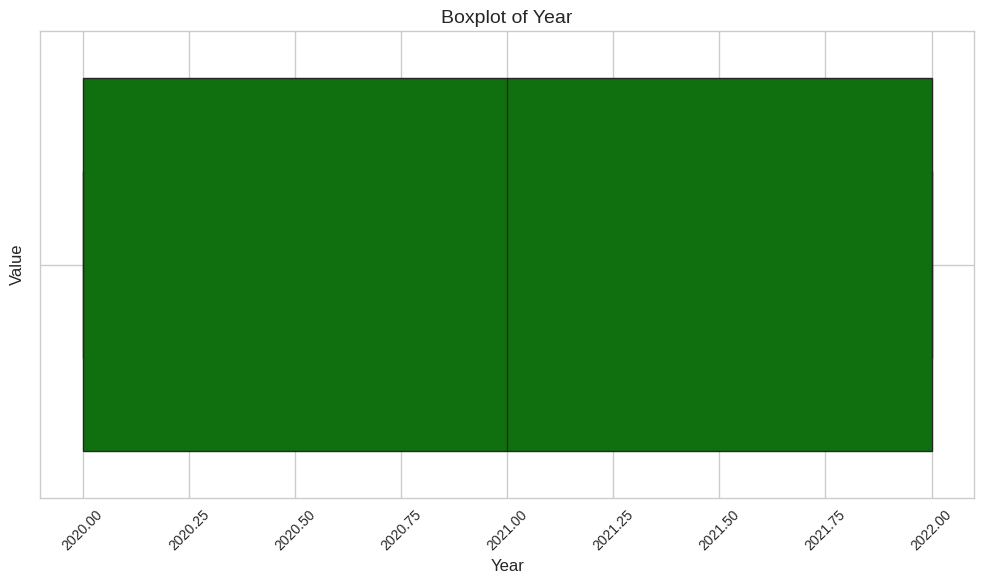

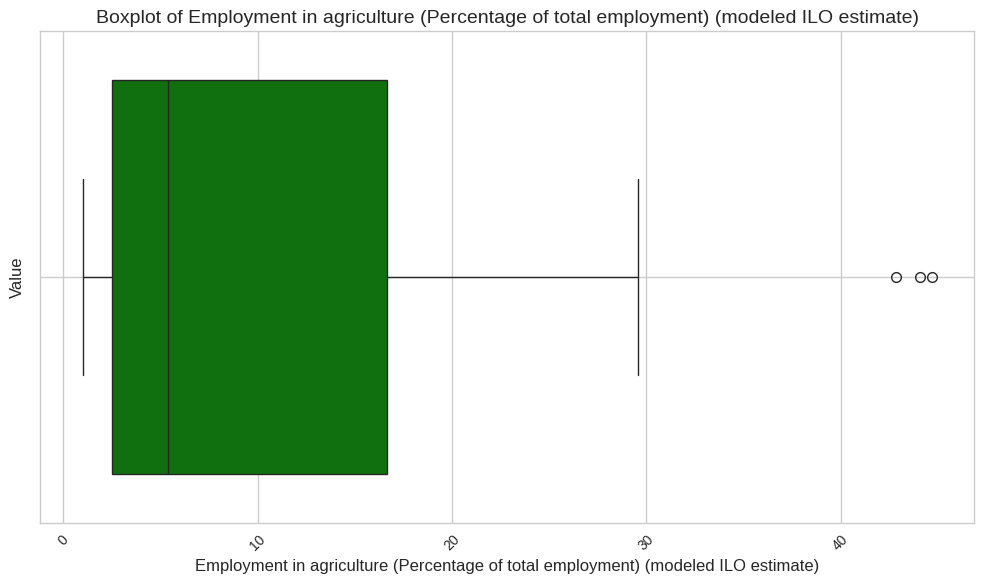

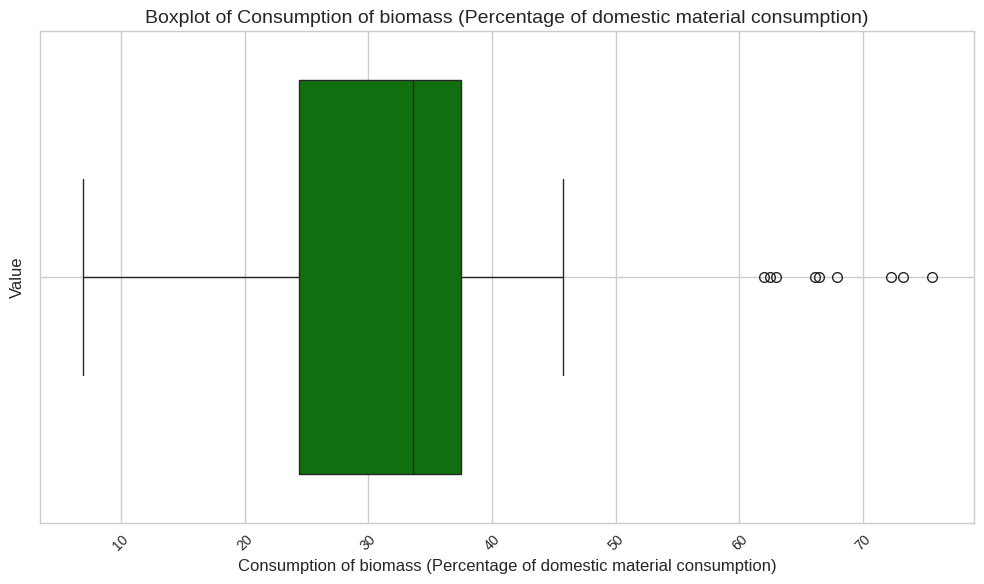

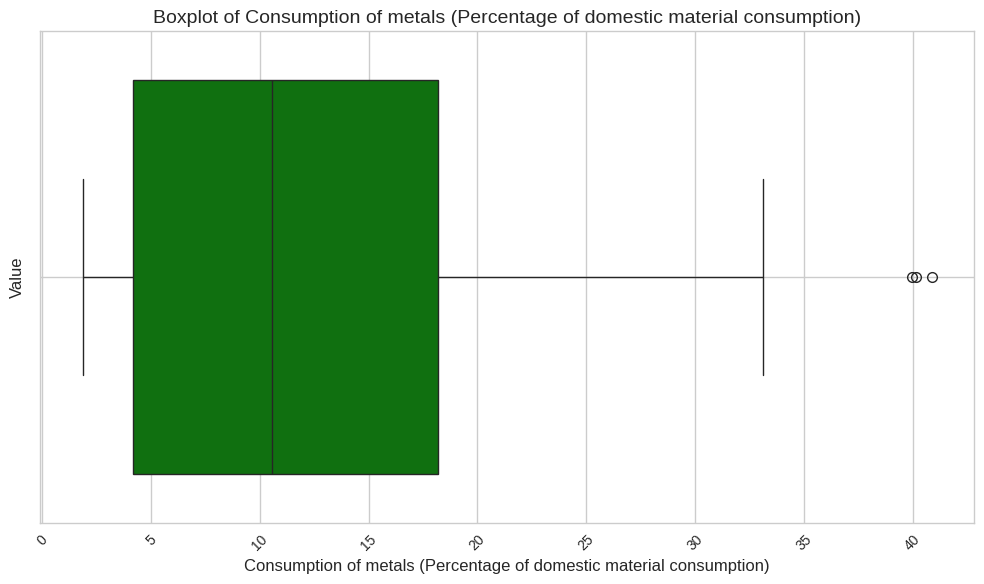

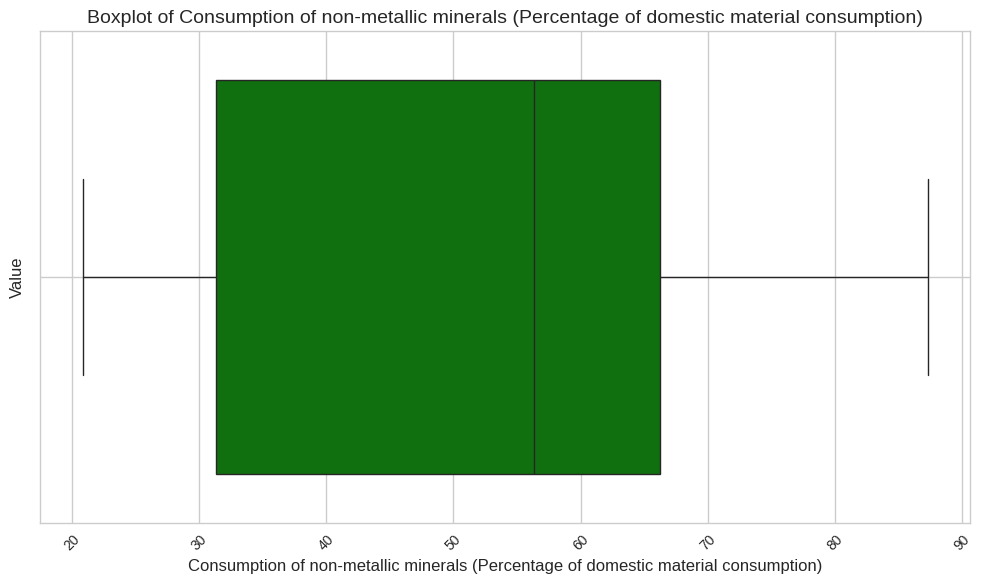

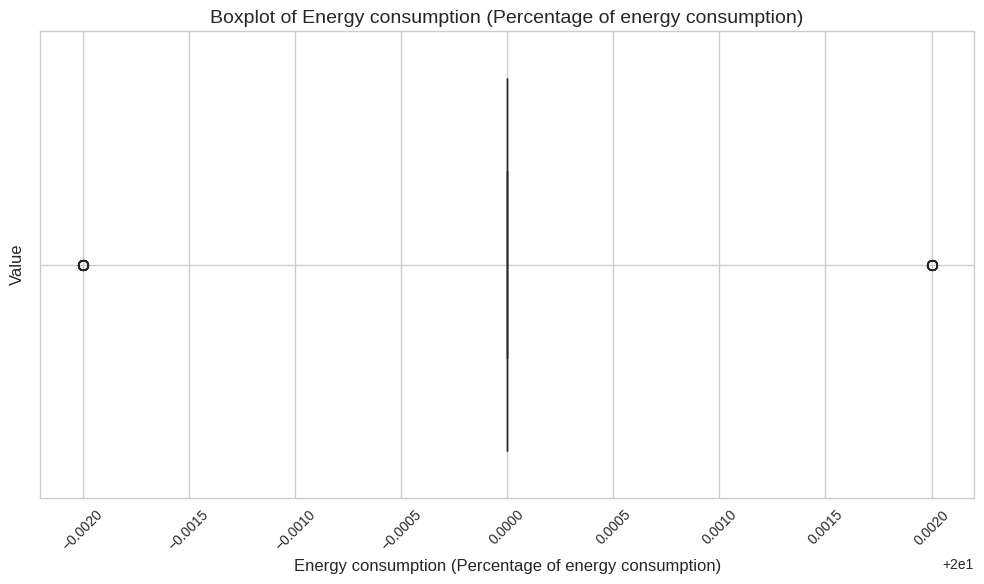

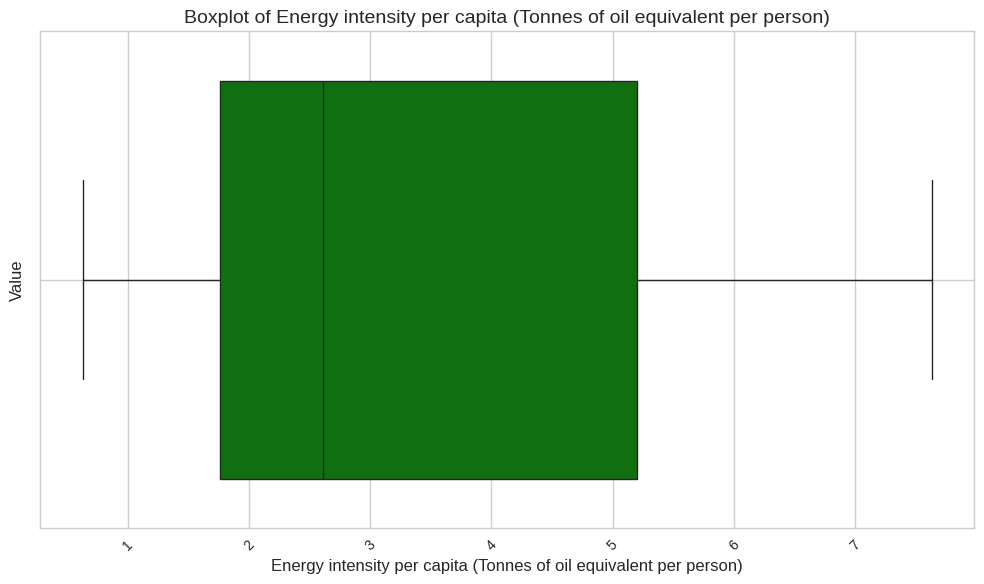

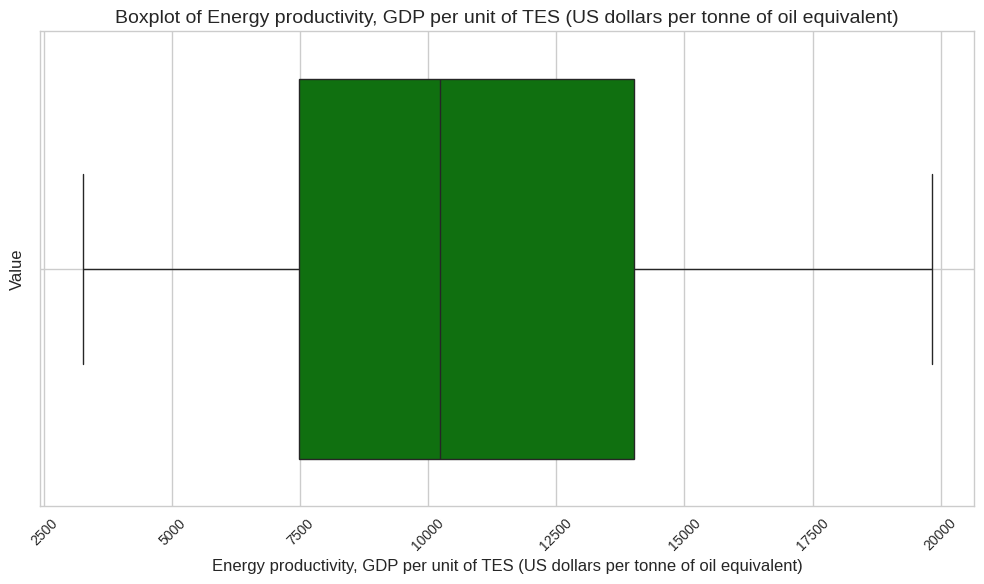

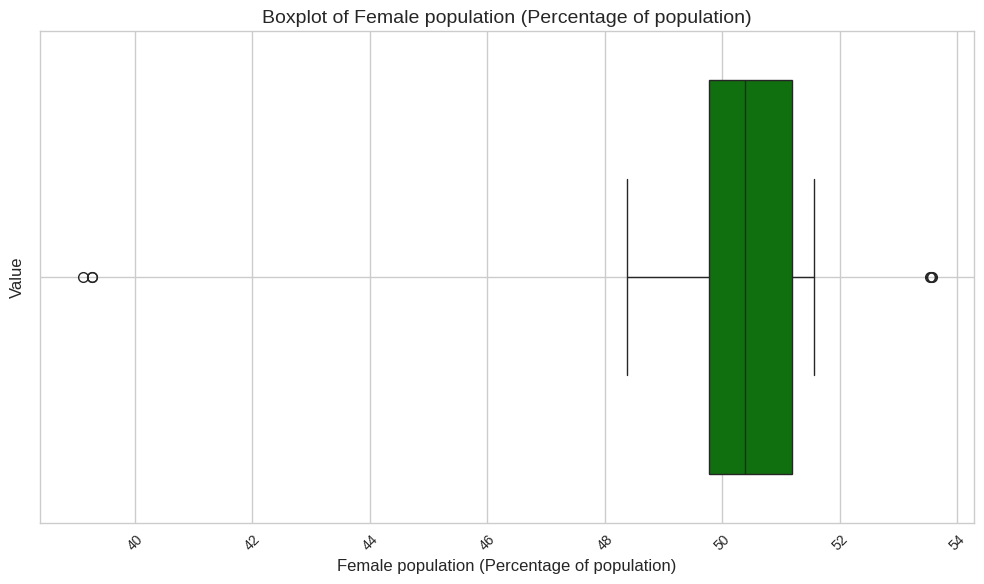

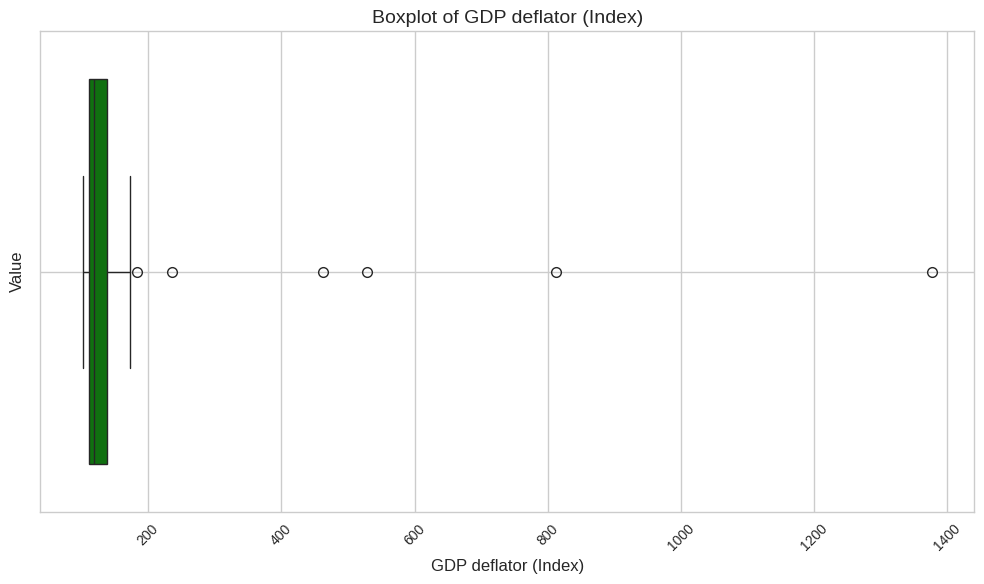

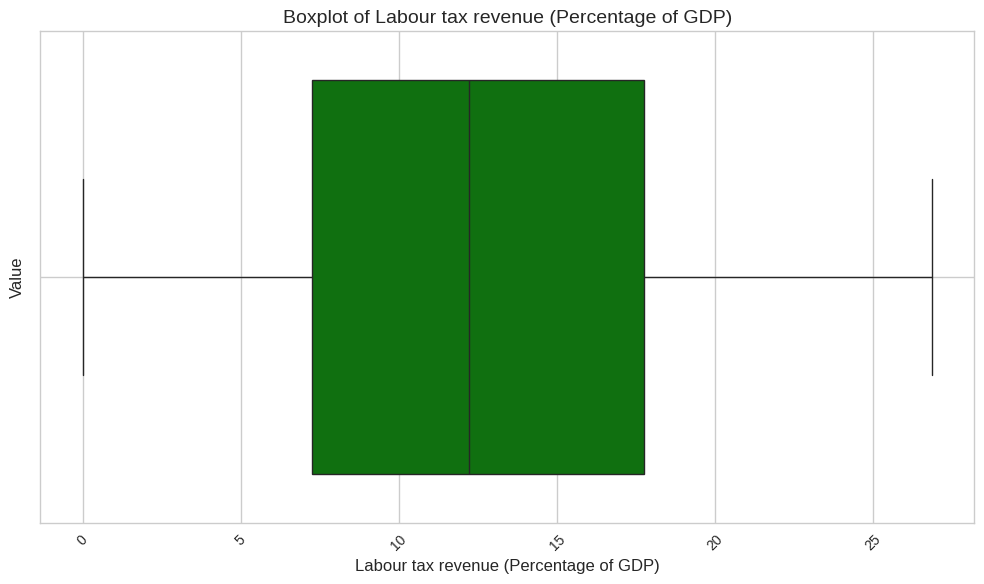

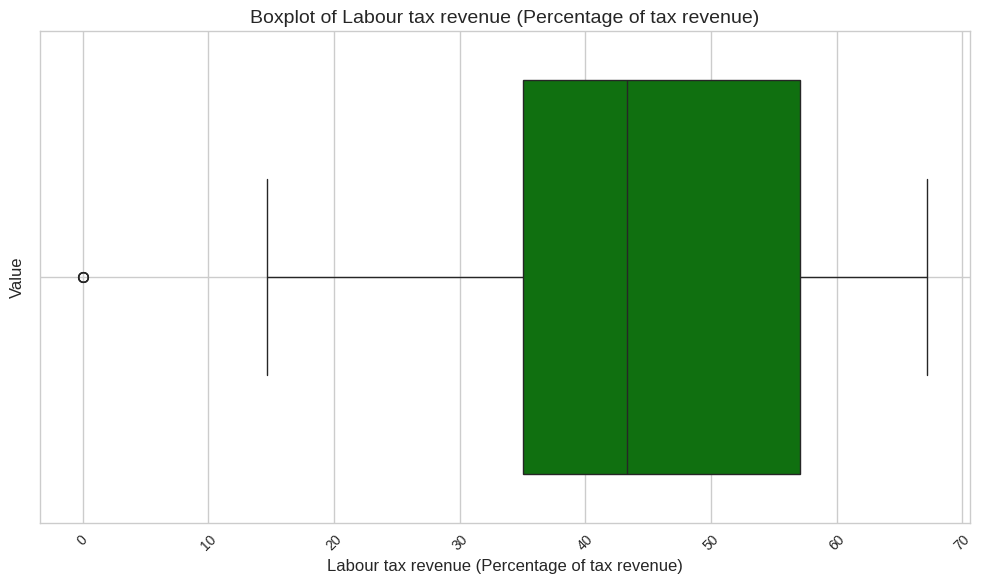

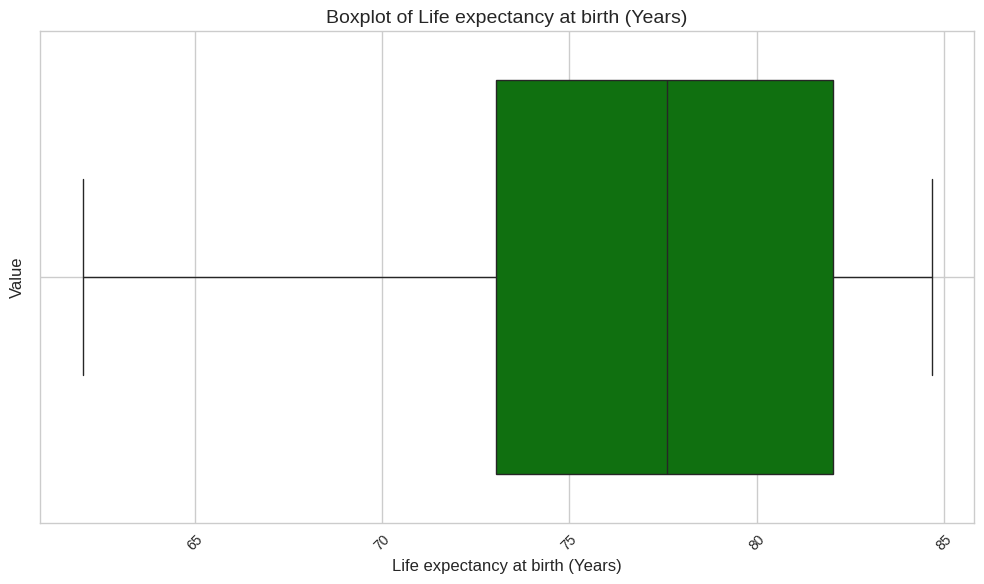

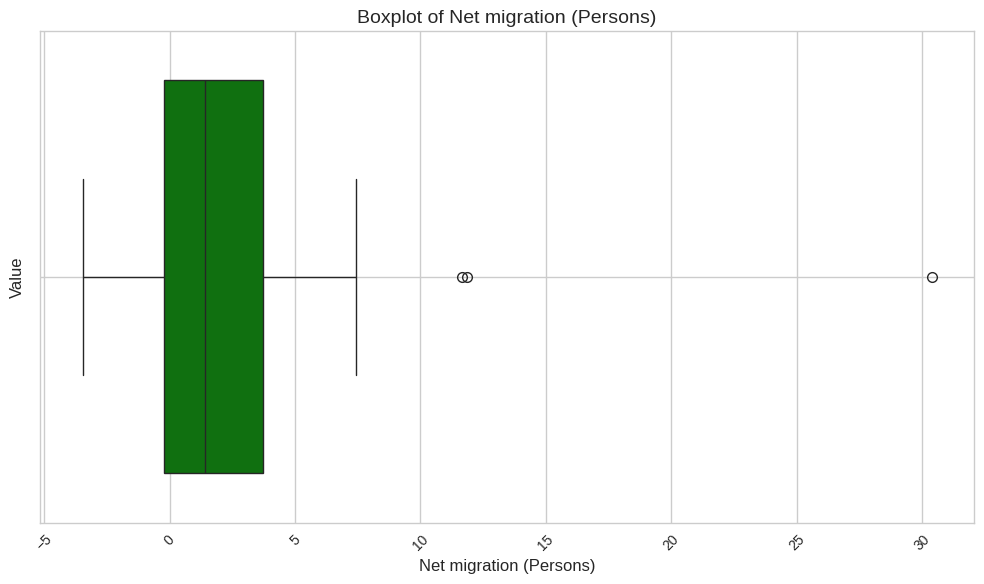

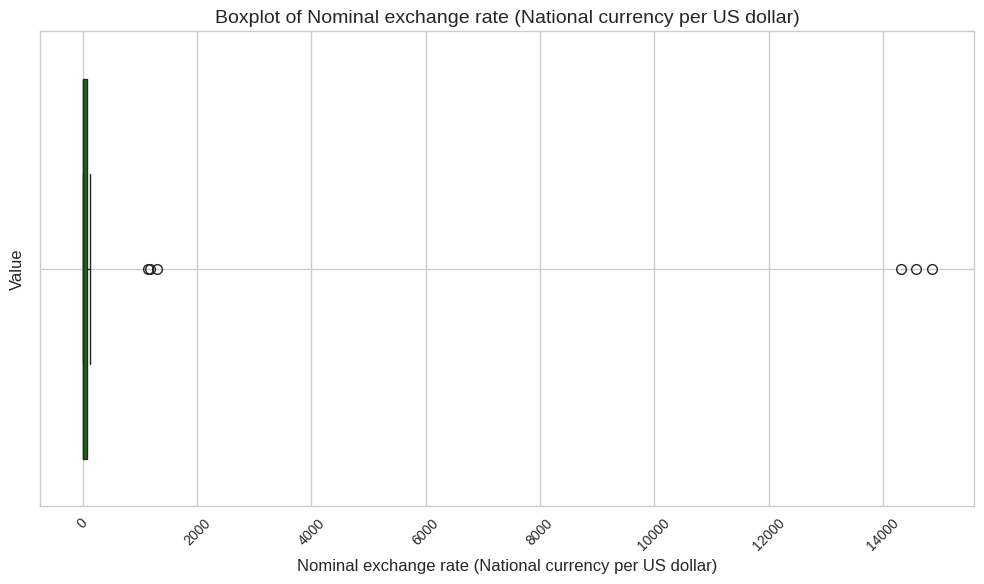

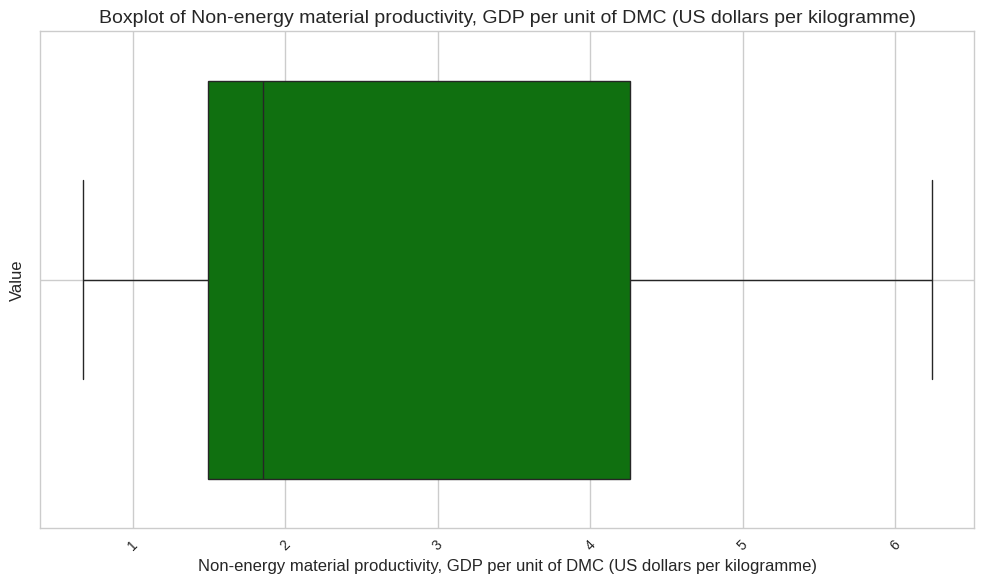

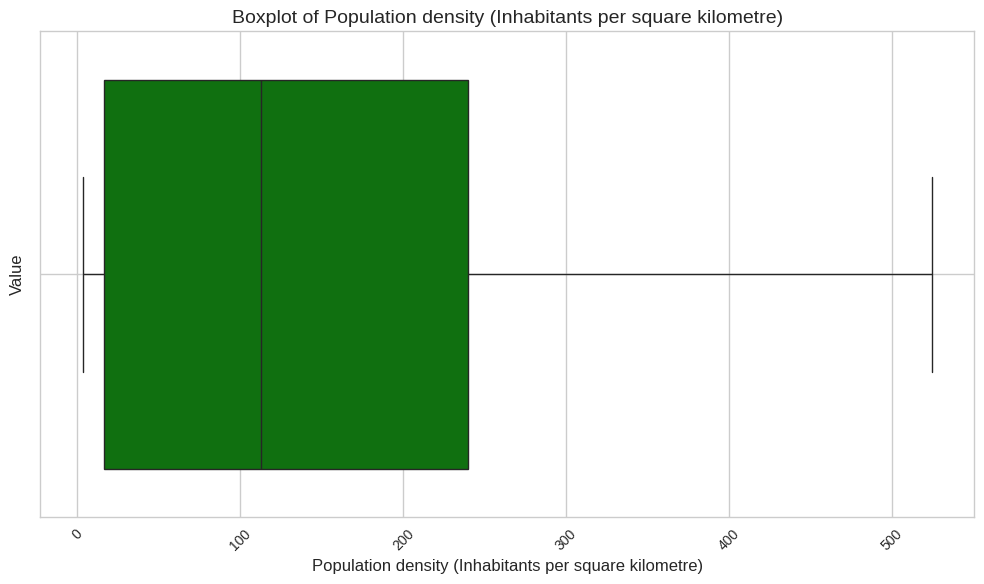

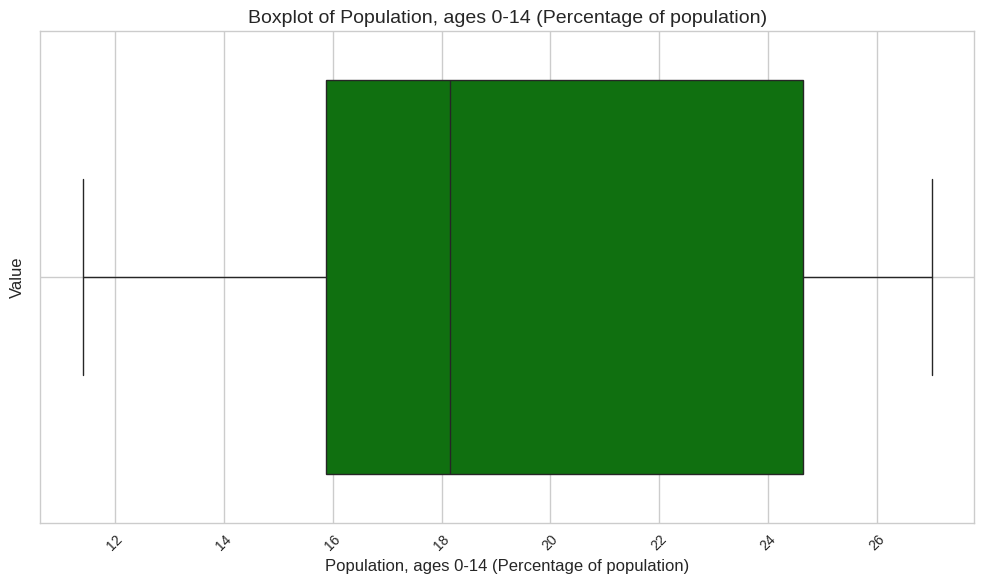

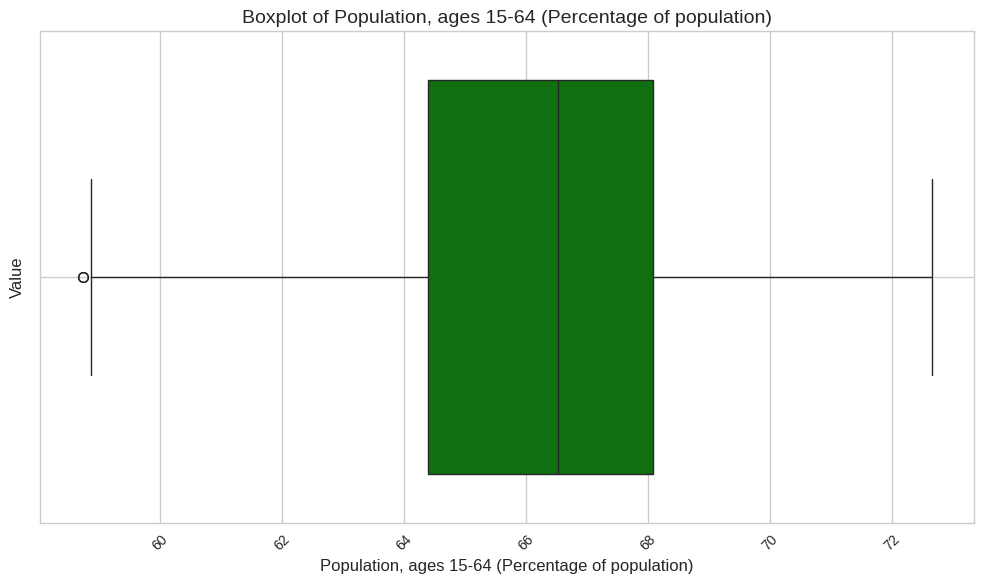

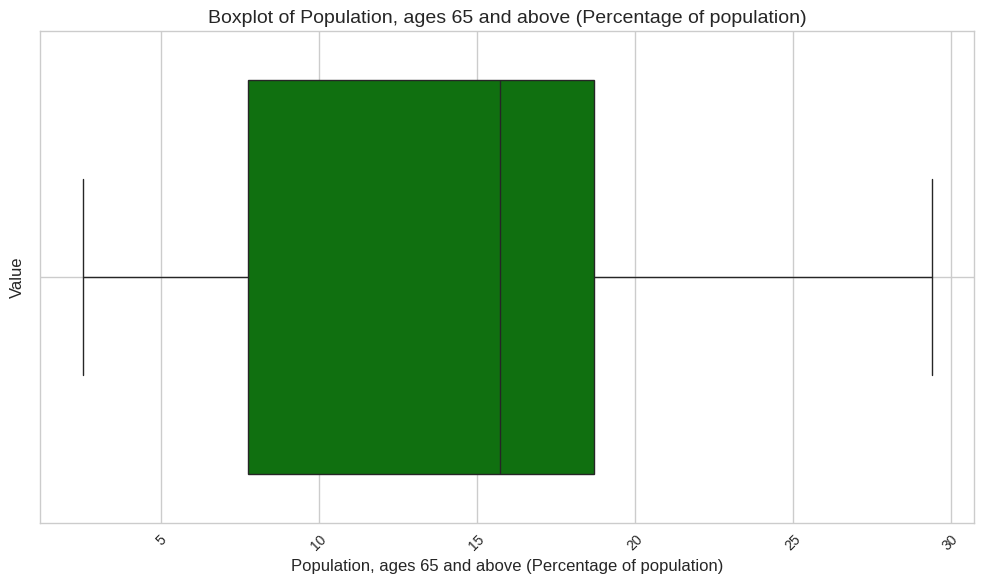

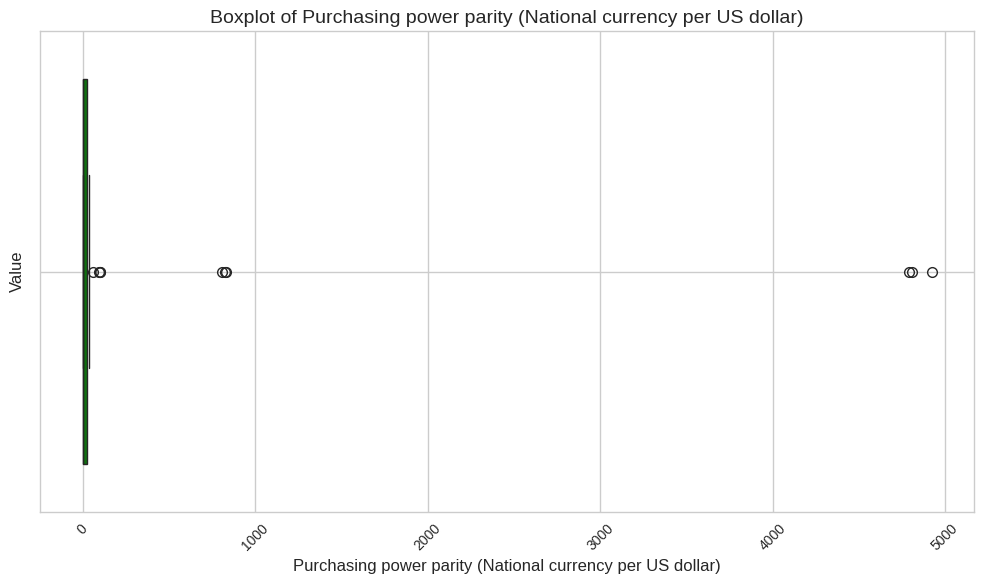

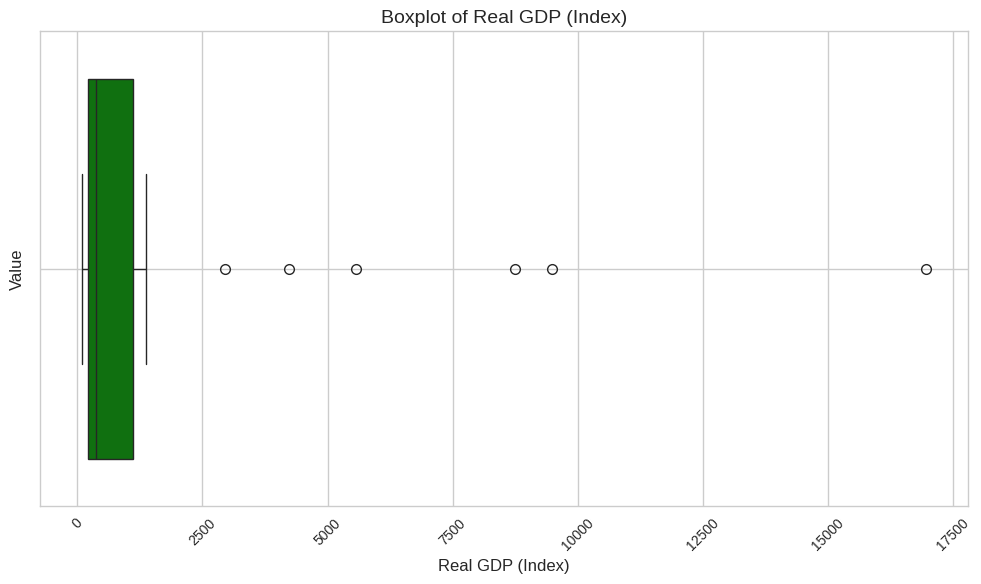

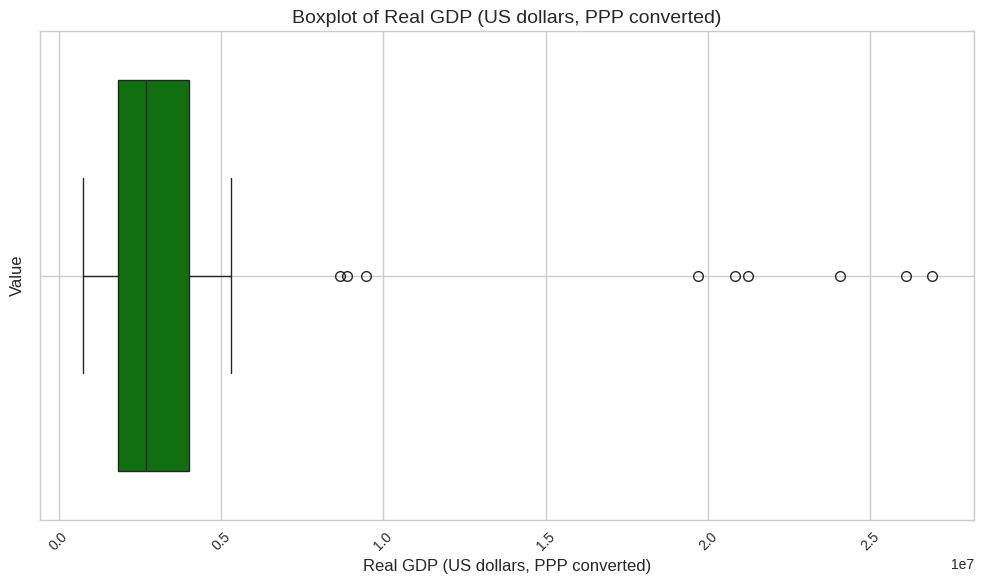

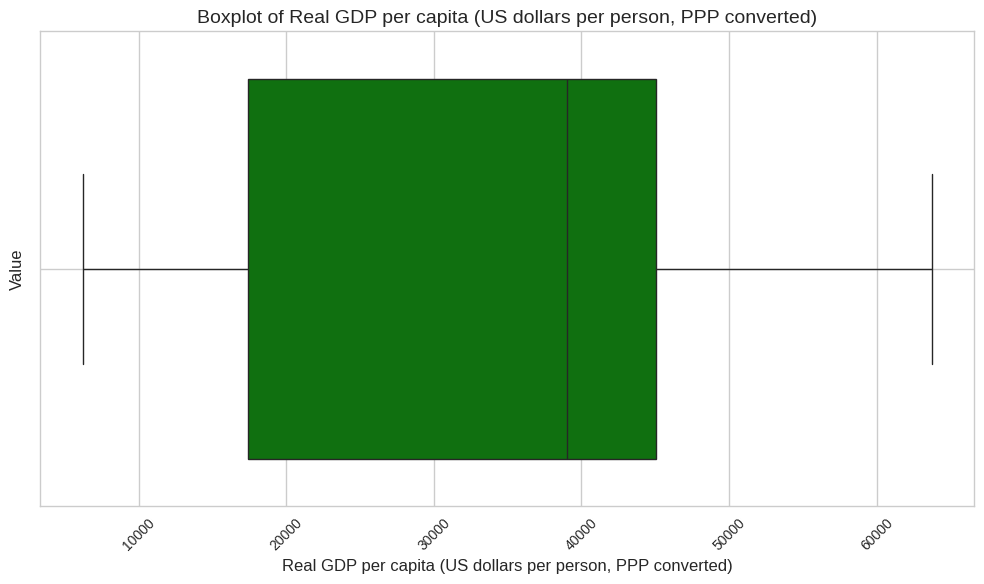

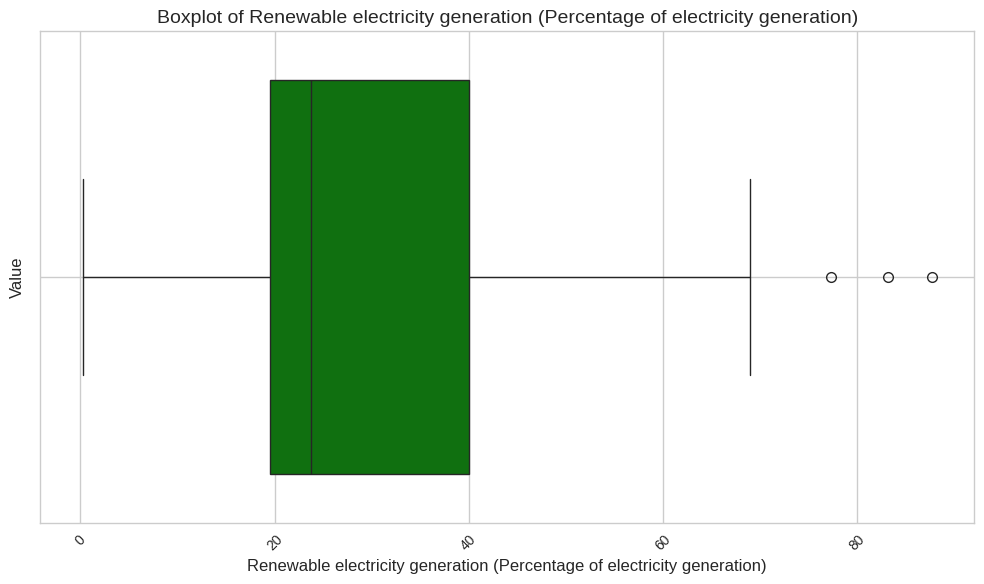

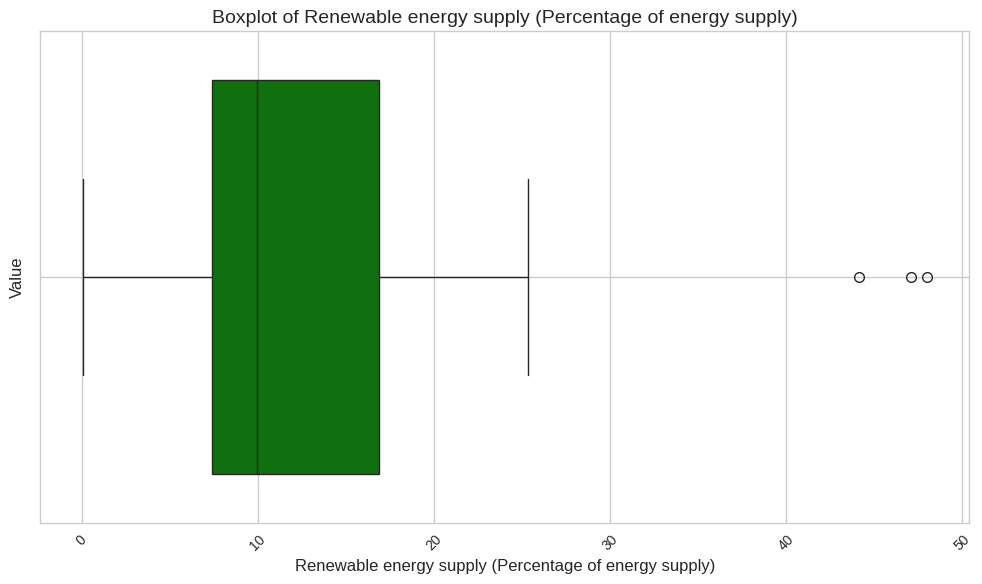

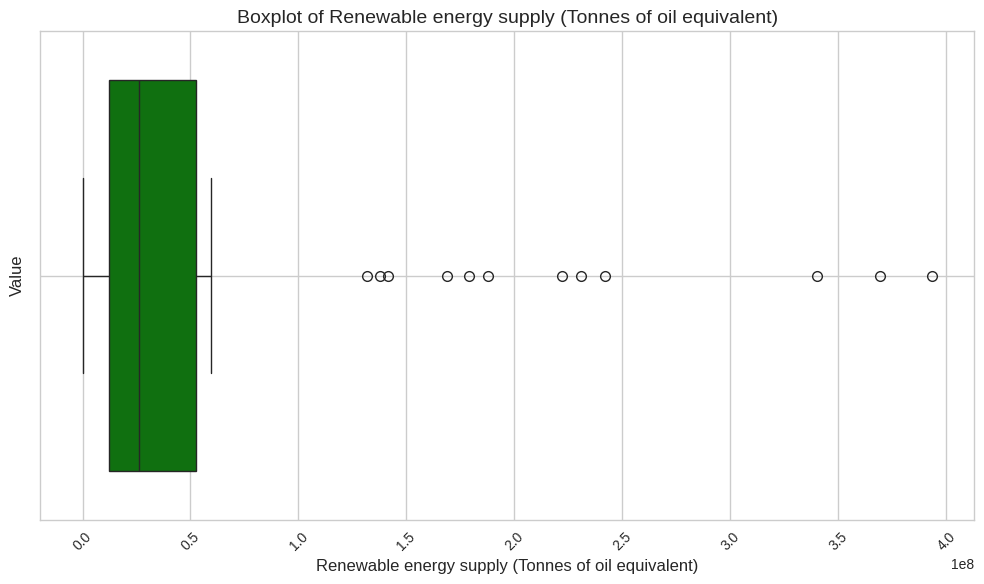

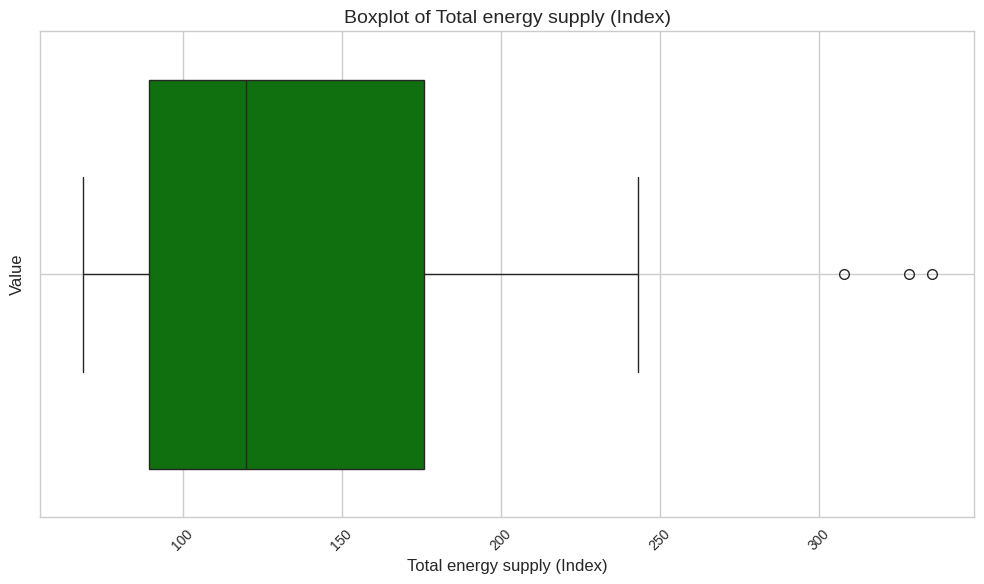

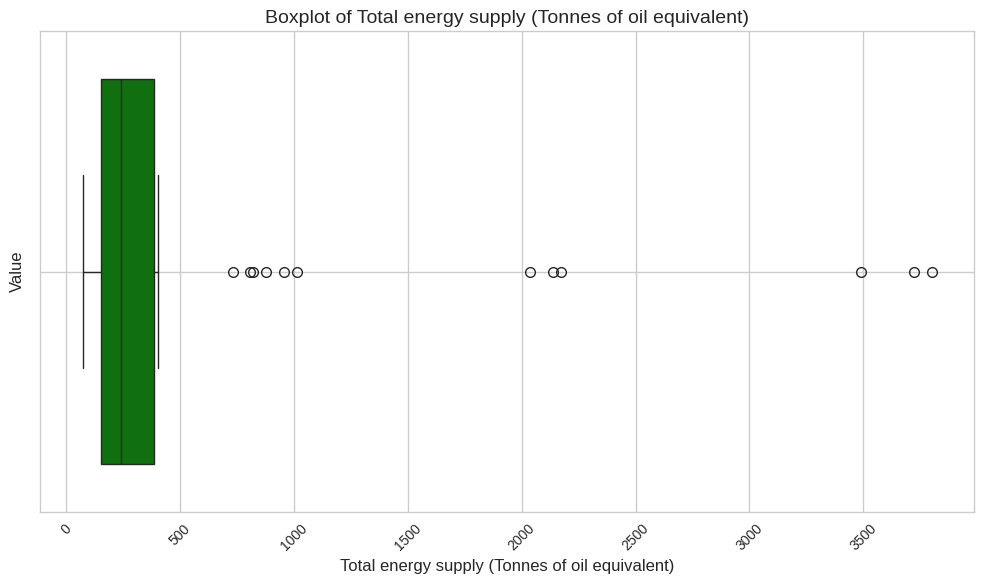

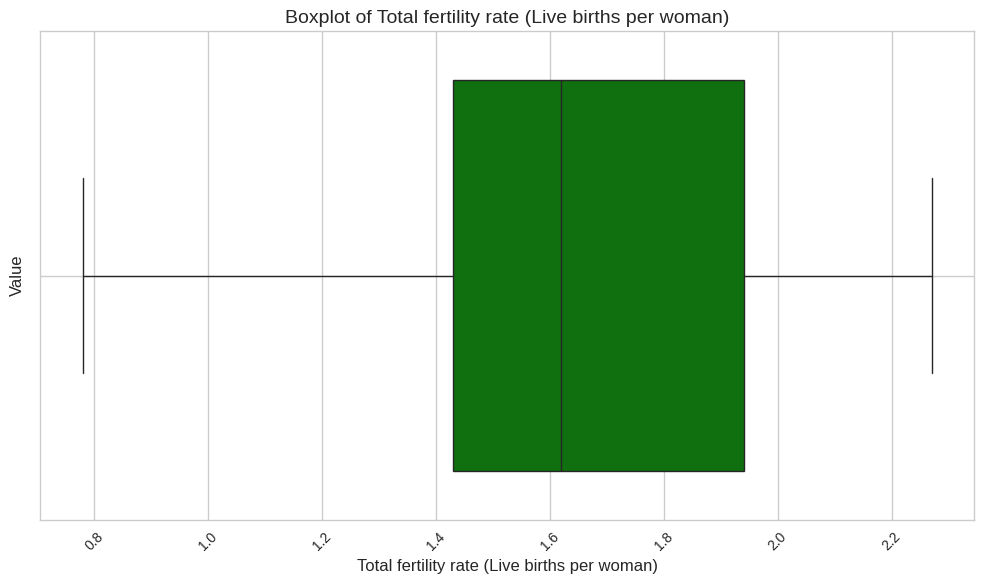

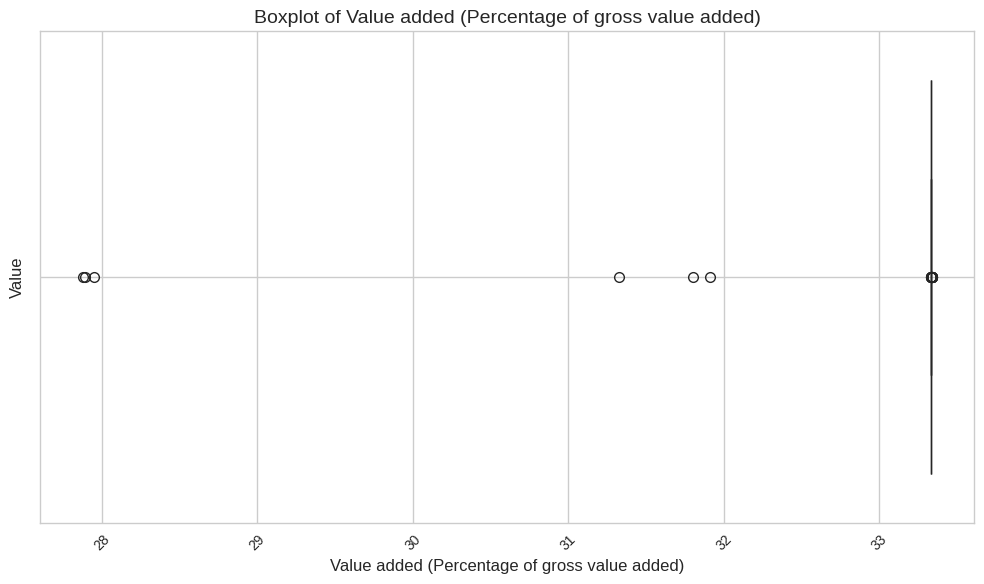

In [51]:
# Memilih feature numerik
numerical_cols = df.select_dtypes(include=['number']).columns

# Mengatur gaya visualisasi menggunakan seaborn-whitegrid
plt.style.use('seaborn-v0_8-whitegrid')

# Melakukan looping untuk membuat boxplot untuk setiap feature numerik
for col in numerical_cols:
    plt.figure(figsize=(10, 6))  # Menyesuaikan ukuran grafik
    sns.boxplot(x=df[col], color='green')  # Membuat boxplot dengan warna skyblue
    plt.title(f'Boxplot of {col}', fontsize=14)  # Menambahkan judul boxplot dengan ukuran font
    plt.xlabel(col, fontsize=12)  # Menambahkan label untuk sumbu x
    plt.ylabel('Value', fontsize=12)  # Menambahkan label untuk sumbu y
    plt.xticks(rotation=45)  # Memutar label sumbu x agar lebih mudah dibaca
    plt.grid(True)  # Menambahkan grid agar lebih jelas
    plt.tight_layout()  # Menyesuaikan layout agar tidak terjadi tumpang tindih
    plt.show()  # Menampilkan grafik



**Penanganan Outlier**:
- Terdapat **outlier yang cukup jelas** pada kolom **Value Added**, **Purchasing Power Parity**, dan **Nominal Exchange Rate**.
- Outlier tetap dipertahankan karena dataset mencakup data dari berbagai negara, yang dapat mencerminkan kondisi ekonomi yang sangat beragam.

### **Imbalance Data**

In [52]:
# Memeriksa distribusi data berdasarkan variabel 'Country'
country_counts = df['Country'].value_counts()

# Menghitung jumlah tahun unik di fitur 'Year'
num_years = df['Year'].nunique()

# Menghitung persentase distribusi data untuk setiap 'Country'
country_percentages = (country_counts / num_years).round(2) * 100

# Membuat DataFrame untuk menampilkan hasil distribusi dan persentase
imbalance_summary = pd.DataFrame({
    'Counts': country_counts,  # Jumlah data untuk setiap 'Country'
    'Percentage (%)': country_percentages  # Persentase data relatif terhadap total tahun
})

# Menampilkan ringkasan distribusi data (imbalance)
imbalance_summary

,Counts,Percentage (%)
Country,,
Argentina,3,100.0
Mexico,3,100.0
United Kingdom,3,100.0
Türkiye,3,100.0
South Africa,3,100.0
Saudi Arabia,3,100.0
Russia,3,100.0
Republic of Korea,3,100.0
People's Republic of China,3,100.0



**Pemeriksaan Imbalance Data**:
- Setelah dilakukan pengecekan **imbalance data**, semua negara memiliki **jumlah data yang sama**, yaitu **3 tahun** per negara.

## **Statistics for Data Science**

### **Feature and Data Type Elaboration**

In [53]:
# Membuat salinan untuk eksplorasi data
df_exploration = df.copy()

# Menampilkan beberapa instance pertama dari DataFrame
df_exploration.head()

,Country,Year,Employment in agriculture (Percentage of total employment) (modeled ILO estimate),Consumption of biomass (Percentage of domestic material consumption),Consumption of metals (Percentage of domestic material consumption),Consumption of non-metallic minerals (Percentage of domestic material consumption),Energy consumption (Percentage of energy consumption),Energy intensity per capita (Tonnes of oil equivalent per person),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",Female population (Percentage of population),...,Real GDP (Index),"Real GDP (US dollars, PPP converted)","Real GDP per capita (US dollars per person, PPP converted)",Renewable electricity generation (Percentage of electricity generation),Renewable energy supply (Percentage of energy supply),Renewable energy supply (Tonnes of oil equivalent),Total energy supply (Index),Total energy supply (Tonnes of oil equivalent),Total fertility rate (Live births per woman),Value added (Percentage of gross value added)
0,Argentina,2020,7.285752,75.53,3.63,20.84,20.002,1.62,10198.63,50.39,...,5577.98,748576.50,16496.91,29.89,9.27,6801798.0,120.02,73.40,1.60,27.876667
1,Argentina,2021,7.333608,73.20,3.57,23.23,20.000,1.72,10493.02,50.39,...,9492.69,828091.12,18077.14,27.63,8.74,6896383.4,129.05,78.92,1.58,27.893333
2,Argentina,2022,7.205906,72.22,3.54,24.24,20.000,1.78,10622.92,50.39,...,16951.99,872596.56,18873.14,33.22,9.16,7520217.7,134.32,82.14,1.48,27.950000
3,Australia,2020,2.765993,28.94,40.87,30.19,20.000,5.23,9445.68,50.38,...,295.29,1266869.38,49380.44,22.49,7.39,9906339.5,124.06,134.12,1.59,33.330000
4,Australia,2021,2.494833,30.87,40.16,28.97,20.002,5.07,10280.95,50.38,...,329.83,1339039.50,52126.89,26.54,8.40,10941245.2,120.48,130.24,1.65,33.333333


In [54]:
# Membuat variabel untuk menyimpan informasi fitur
feature_info = {}

# Mengulangi melalui setiap fitur di DataFrame
for column in df_exploration.columns:
    feature_info[column] = {}
    feature_info[column]['data_type'] = df_exploration[column].dtype

    # Mendeskripsikan fitur dan tipe data
    if column == 'Country':
        feature_info[column]['data_type'] = 'object'
        feature_info[column]['description'] = 'Fitur kategorikal nominal yang mewakili nama negara.'
        feature_info[column]['data_type_elaboration'] = 'Nominal'
    elif column == 'Year':
        feature_info[column]['data_type'] = 'int64'
        feature_info[column]['description'] = 'Fitur kategorikal ordinal yang mewakili tahun.'
        feature_info[column]['data_type_elaboration'] = 'Ordinal'
    elif 'Employment in agriculture' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili persentase pekerjaan di sektor pertanian.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Energy' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang berkaitan dengan konsumsi, intensitas, atau pasokan energi.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Renewable electricity' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang menunjukkan listrik terbarukan.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Renewable energy' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang menunjukkan energi terbarukan.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Consumption of' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang menunjukkan persentase konsumsi bahan material domestik (misalnya biomassa, logam).'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Non-energy material productivity' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili produktivitas terkait dengan material non-energi.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Female population' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili produktivitas terkait dengan jumlah populasi wanita.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'GDP' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili produktivitas terkait dengan GDP.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Labour tax revenue' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili produktivitas terkait dengan pendapatan pajak tenaga kerja.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Life expectancy at birth' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili produktivitas terkait dengan harapan hidup pada saat lahir.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Net migration' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili produktivitas terkait dengan migrasi bersih.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Nominal exchange rate' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili produktivitas terkait dengan nilai tukar nominal.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Population' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili produktivitas terkait dengan populasi.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Total energy' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili produktivitas terkait dengan total energi.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Total fertility' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili produktivitas terkait dengan tingkat kelahiran total.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    elif 'Value added' in column:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Fitur numerik yang mewakili produktivitas terkait dengan nilai tambah.'
        feature_info[column]['data_type_elaboration'] = 'Numerik'
    else:
        feature_info[column]['data_type'] = 'float64'
        feature_info[column]['description'] = 'Deskripsi fitur tidak tersedia.'
        feature_info[column]['data_type_elaboration'] = 'Penjelasan tipe data tidak tersedia.'

# Mencetak informasi fitur
for column, info in feature_info.items():
    print(f"Fitur: {column}")
    print(f"  Tipe Data: {info['data_type']}")
    print(f"  Penjelasan Tipe Data: {info['data_type_elaboration']}")
    print(f"  Deskripsi: {info['description']}")
    print("-" * 20)

Fitur: Country
  Tipe Data: object
  Penjelasan Tipe Data: Nominal
  Deskripsi: Fitur kategorikal nominal yang mewakili nama negara.
--------------------
Fitur: Year
  Tipe Data: int64
  Penjelasan Tipe Data: Ordinal
  Deskripsi: Fitur kategorikal ordinal yang mewakili tahun.
--------------------
Fitur: Employment in agriculture (Percentage of total employment) (modeled ILO estimate)
  Tipe Data: float64
  Penjelasan Tipe Data: Numerik
  Deskripsi: Fitur numerik yang mewakili persentase pekerjaan di sektor pertanian.
--------------------
Fitur: Consumption of biomass (Percentage of domestic material consumption)
  Tipe Data: float64
  Penjelasan Tipe Data: Numerik
  Deskripsi: Fitur numerik yang menunjukkan persentase konsumsi bahan material domestik (misalnya biomassa, logam).
--------------------
Fitur: Consumption of metals (Percentage of domestic material consumption)
  Tipe Data: float64
  Penjelasan Tipe Data: Numerik
  Deskripsi: Fitur numerik yang menunjukkan persentase konsums


- **Fitur "Country"** mewakili negara, dengan tipe data nominal yang menunjukkan kategorisasi berdasarkan negara.
- **Fitur "Year"** menunjukkan tahun dalam format ordinal, memberikan informasi terkait data tahunan.
- **Fitur terkait konsumsi energi dan material** (misalnya **Consumption of biomass**, **Consumption of metals**, **Energy consumption**) memberikan gambaran tentang tren penggunaan energi dan sumber daya di berbagai negara.
- **Fitur "Employment in agriculture"** menunjukkan persentase pekerja di sektor pertanian, penting untuk memahami porsi sektor pertanian dalam ekonomi.
- **Fitur "GDP" dan **GDP deflator** memberikan gambaran penting mengenai kondisi ekonomi dan daya beli negara.
- **Fitur "Population"** (seperti **Female population**, **Population density**, **Population by age group**) memberikan wawasan demografis terkait distribusi populasi.
- **Fitur "Renewable energy"** mengungkapkan kontribusi energi terbarukan terhadap total energi yang digunakan dan pasokan energi.
- **Fitur "Value added"** menunjukkan kontribusi sektor ekonomi terhadap PDB suatu negara.

### **Statistical Five Summaries**

In [55]:
# Menampilkan lima nilai summary statistik (min, Q1, median, Q3, max)
df_exploration.describe().loc[['min','25%','50%','75%','max']].T.round(2)

,min,25%,50%,75%,max
Year,2020.00,2020.00,2021.00,2022.00,2.022000e+03
Employment in agriculture (Percentage of total employment) (modeled ILO estimate),1.00,2.49,5.37,16.66,4.468000e+01
Consumption of biomass (Percentage of domestic material consumption),6.91,24.37,33.63,37.50,7.553000e+01
Consumption of metals (Percentage of domestic material consumption),1.86,4.15,10.58,18.17,4.087000e+01
Consumption of non-metallic minerals (Percentage of domestic material consumption),20.84,31.36,56.33,66.24,8.729000e+01
Energy consumption (Percentage of energy consumption),20.00,20.00,20.00,20.00,2.000000e+01
Energy intensity per capita (Tonnes of oil equivalent per person),0.63,1.76,2.61,5.20,7.630000e+00
"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)",3254.87,7485.53,10226.40,14009.99,1.982395e+04
Female population (Percentage of population),39.11,49.77,50.39,51.18,5.356000e+01
GDP deflator (Index),101.74,110.74,118.97,137.57,1.376190e+03



- **Real GDP per capita** memiliki rentang yang luas, dengan nilai minimal 6,207  dan  maksimal  63,717, menunjukkan disparitas ekonomi yang signifikan antar negara.
- **Renewable electricity generation** menunjukkan variasi besar dalam kontribusi energi terbarukan terhadap total konsumsi energi, dengan rentang antara 0,23% hingga 87,68%.
- **Renewable energy supply** menunjukkan sebagian besar negara memiliki kontribusi rendah terhadap pasokan energi terbarukan, dengan nilai minimum 0,04% dan maksimal 47,99%.
- **Renewable energy supply (Tonnes of oil equivalent)** memiliki distribusi yang lebih besar, menunjukkan peningkatan signifikan dalam jumlah energi terbarukan yang dipasok, dengan nilai maksimum mencapai lebih dari 393 juta ton setara minyak.
- **Total energy supply (Index)** menunjukkan variasi dalam indeks pasokan energi antar negara, dari yang terendah 68,62 hingga tertinggi 335,29.
- **Total energy supply (Tonnes of oil equivalent)** memiliki rentang yang besar antara 73,40 hingga 3,799,54 ton setara minyak, mencerminkan ketergantungan negara terhadap sumber energi.
- **Total fertility rate** relatif seragam, dengan rentang yang cukup sempit antara 0,78 hingga 2,27 kelahiran per wanita, menunjukkan tingkat kelahiran yang lebih rendah di banyak negara.
- **Value added (Percentage of gross value added)** stabil, dengan sebagian besar negara berada pada kisaran 33%, menunjukkan konsistensi kontribusi sektor tertentu terhadap PDB.

## **Data Exploration**

#### **Data Distribution**

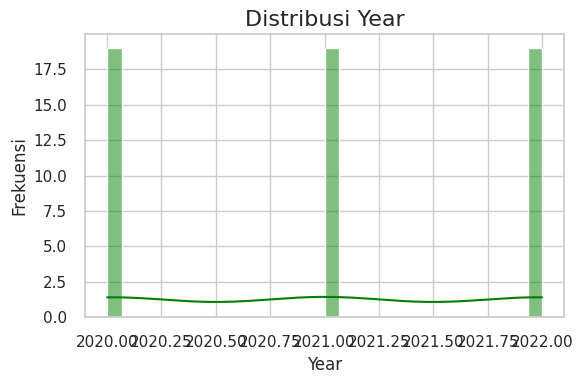

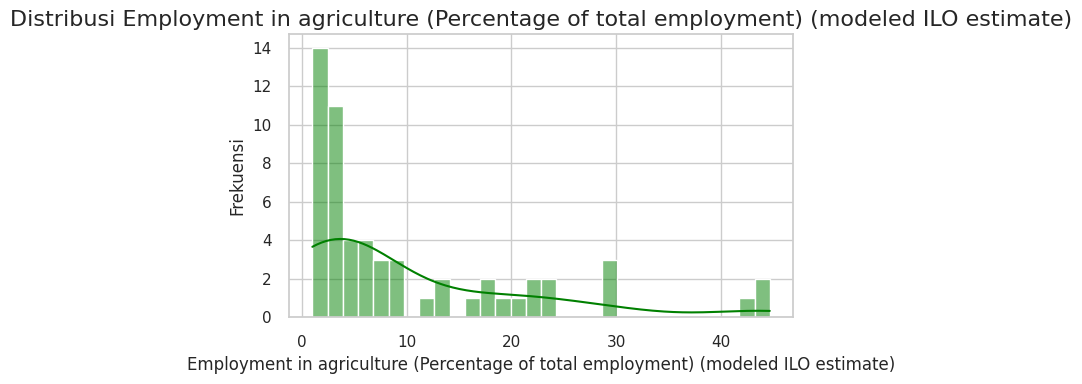

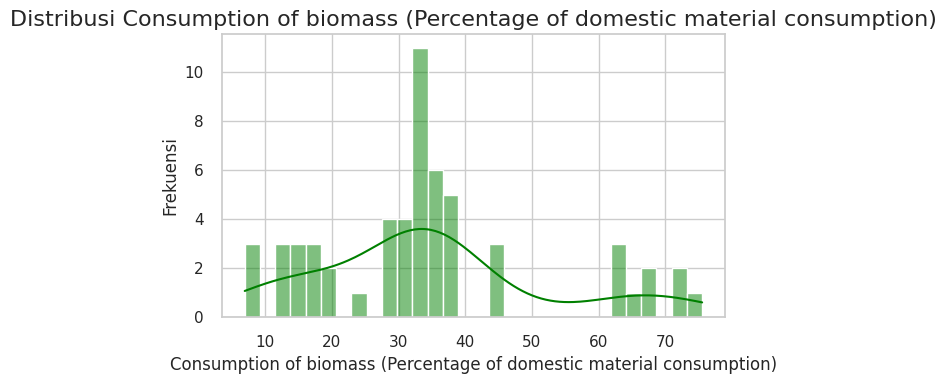

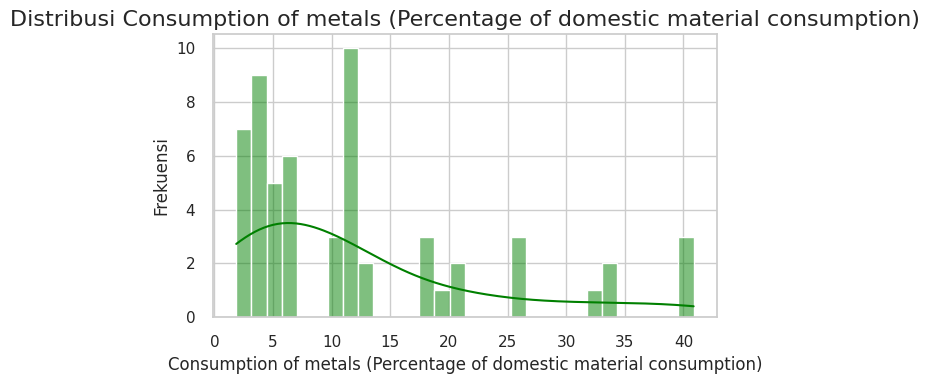

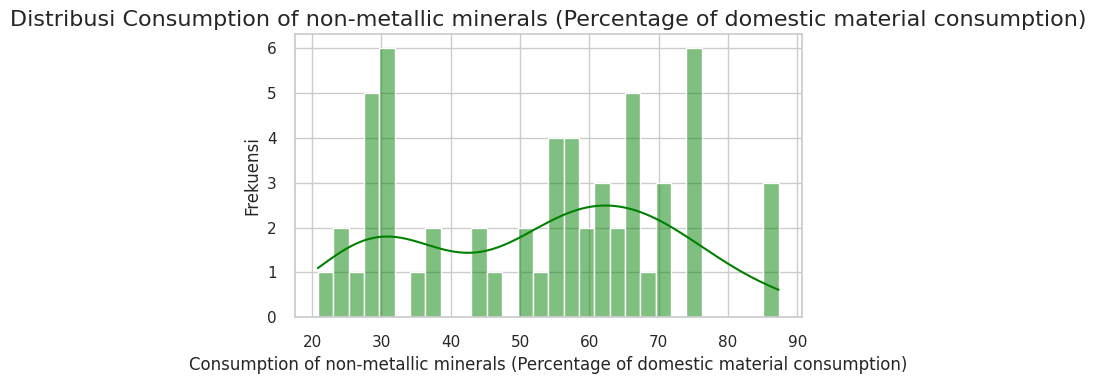

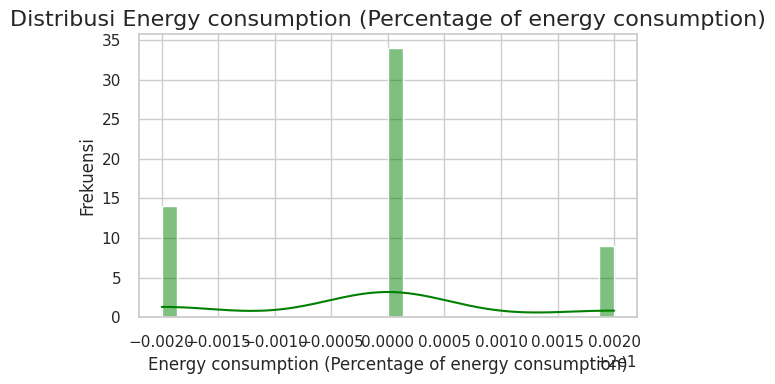

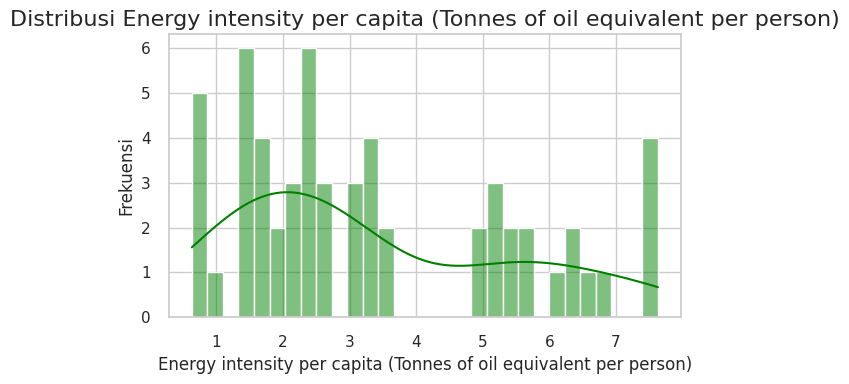

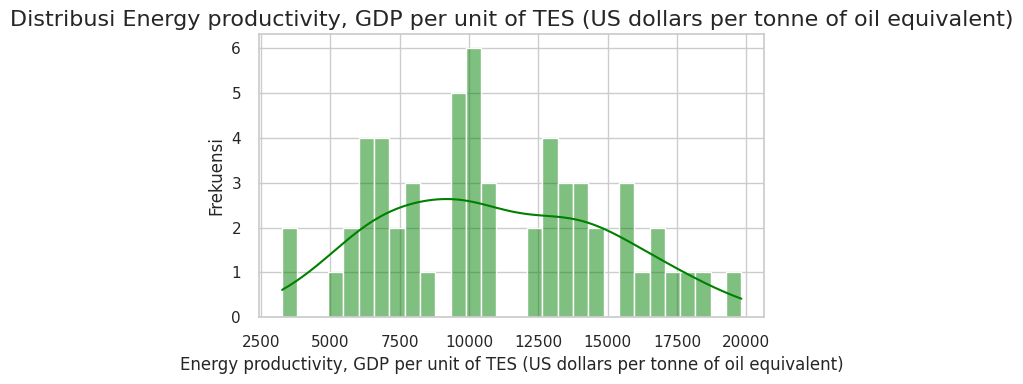

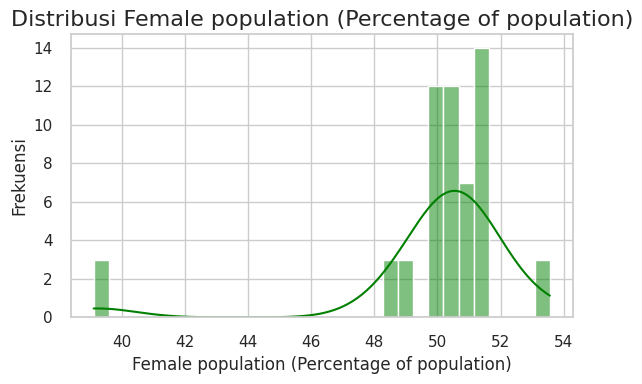

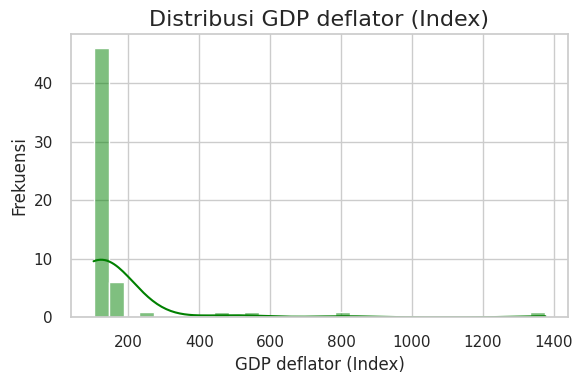

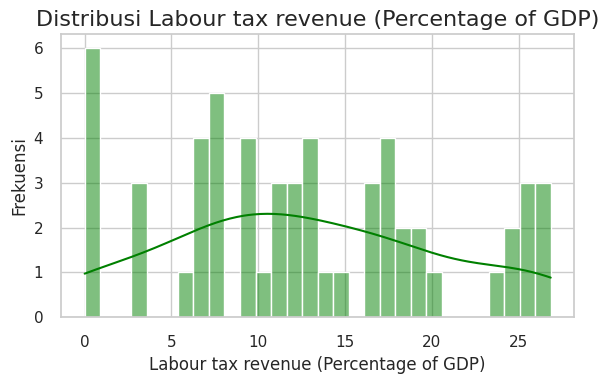

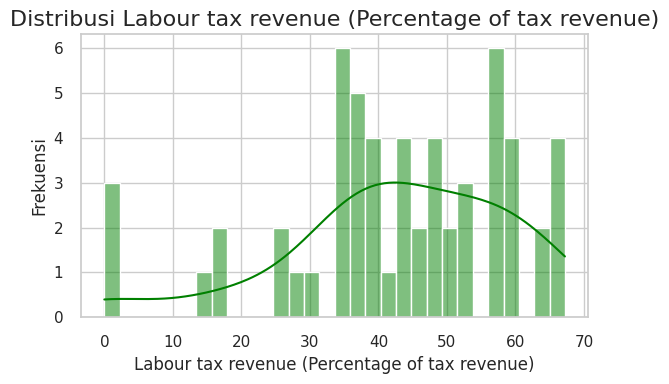

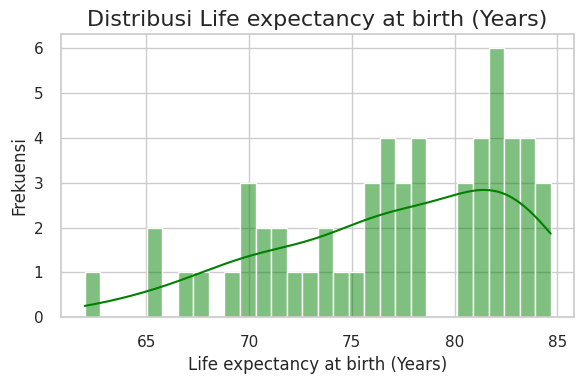

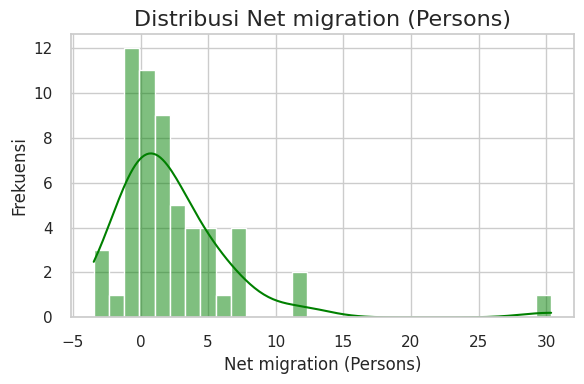

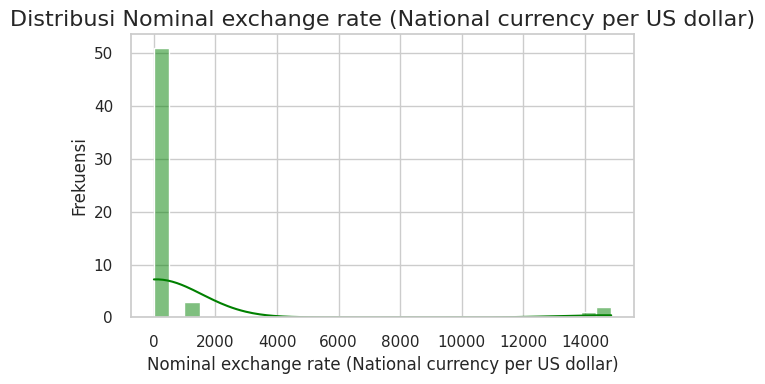

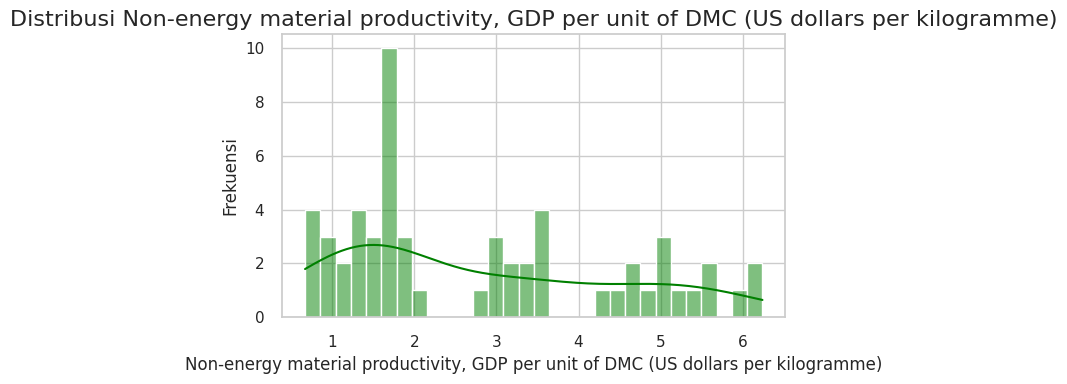

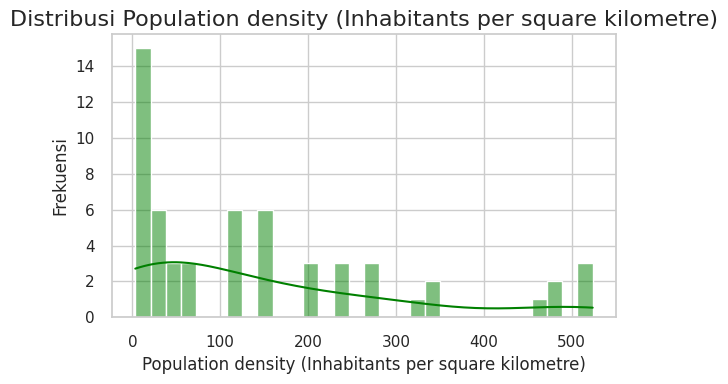

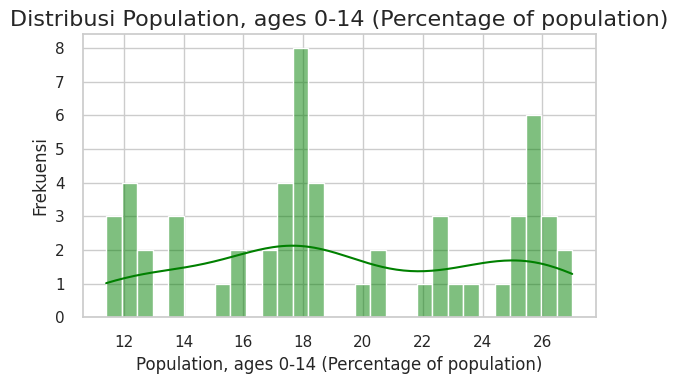

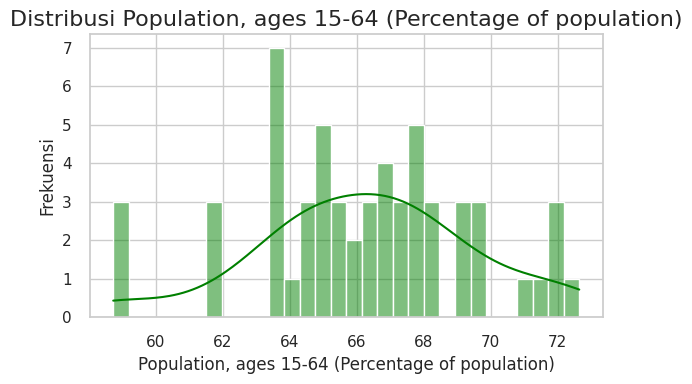

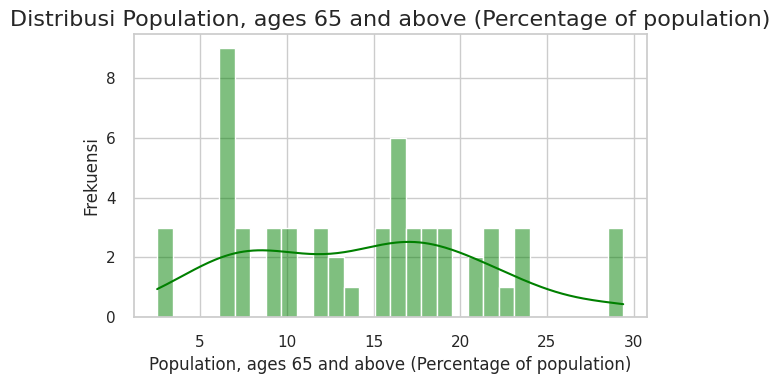

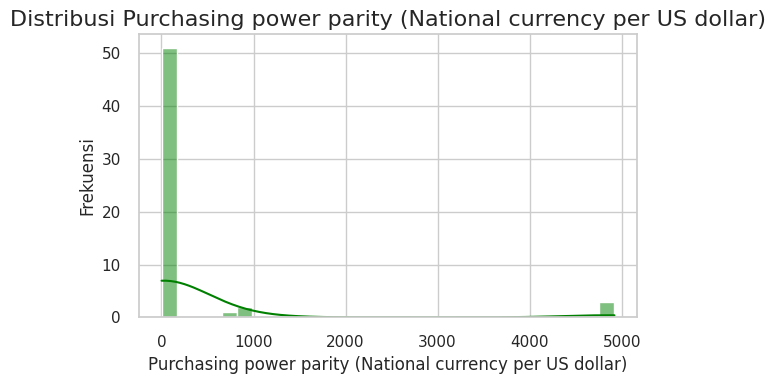

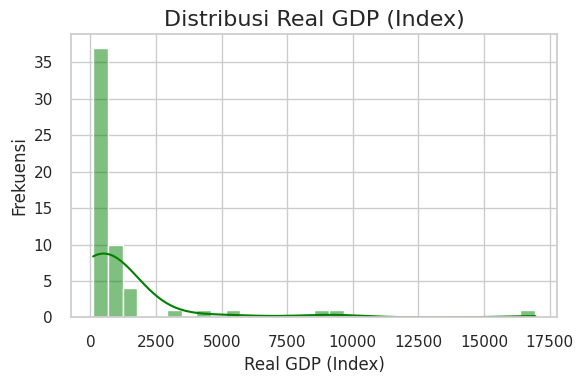

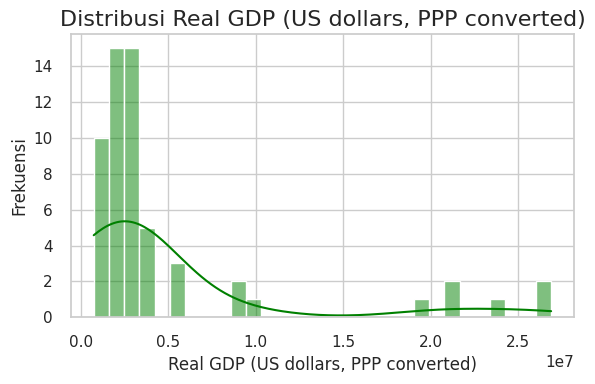

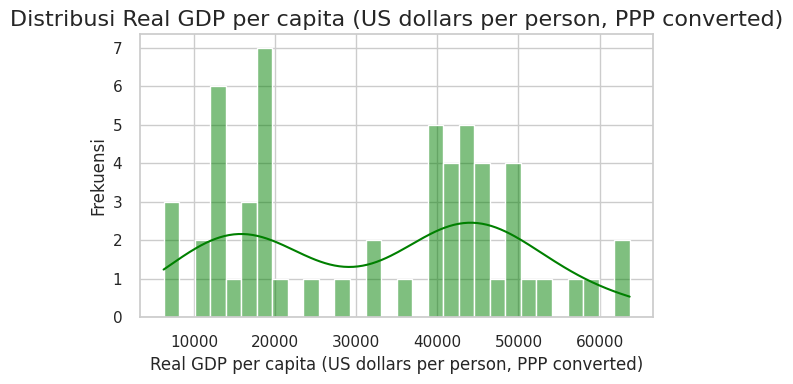

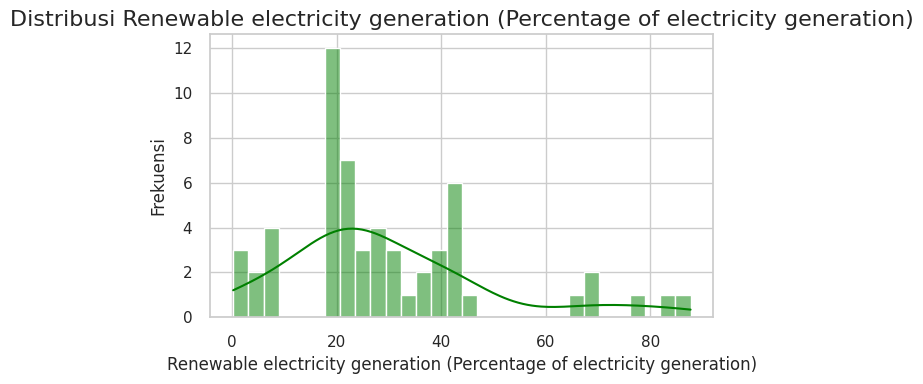

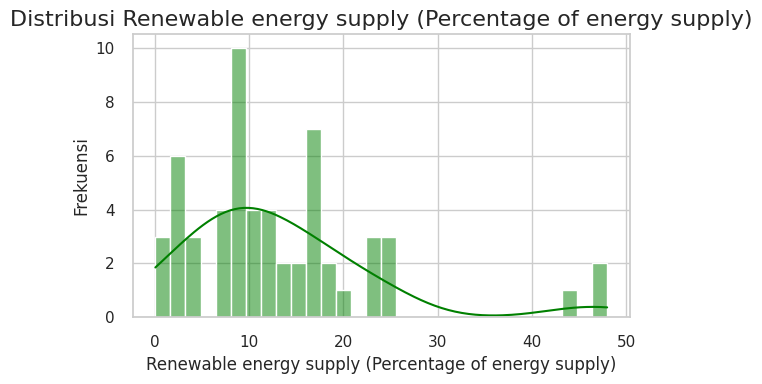

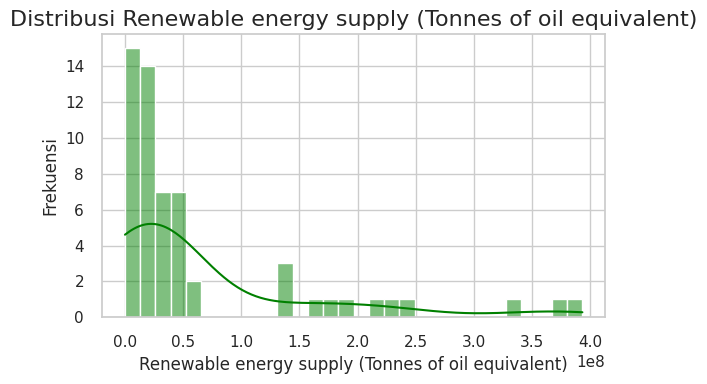

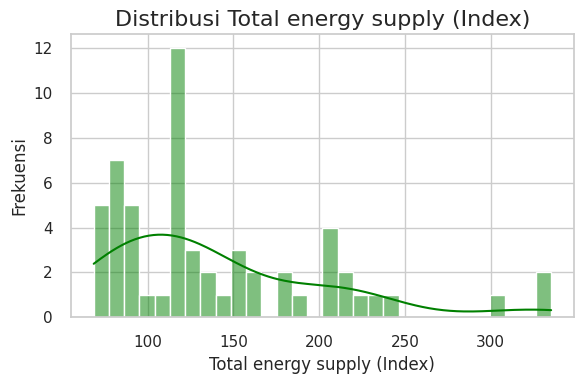

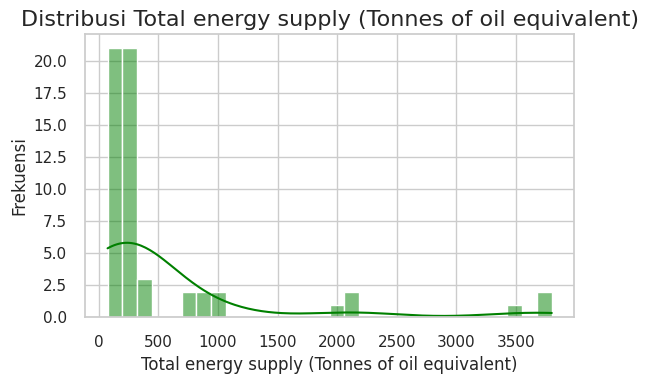

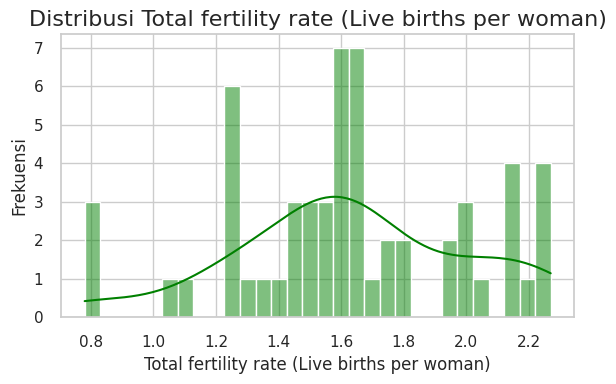

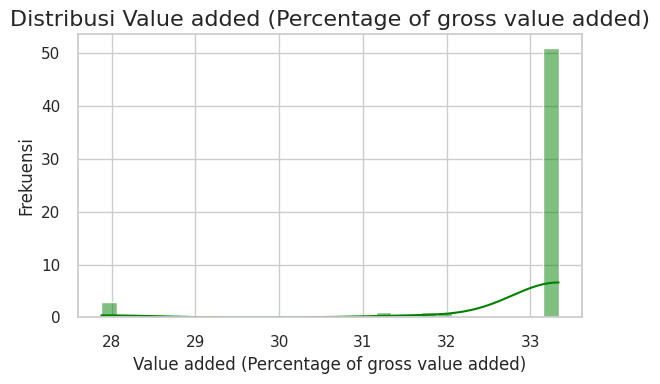

In [56]:
# Memilih feature numerik untuk analisis distribusi
numerical_cols = df_exploration.select_dtypes(include=['float64', 'int64']).columns

# Mengatur gaya visualisasi dengan grid putih untuk tampilan bersih
sns.set(style="whitegrid")

# Membuat histogram untuk setiap feature numerik
for col in numerical_cols:
    plt.figure(figsize=(6, 4))  # Mengatur ukuran grafik untuk tampilan proporsional
    sns.histplot(df_exploration[col], kde=True, color="green", bins=30)  # Histogram dengan KDE dan 30 bins
    plt.title(f'Distribusi {col}', fontsize=16)  # Menambahkan judul dengan ukuran font lebih besar
    plt.xlabel(col, fontsize=12)  # Label untuk sumbu x dengan ukuran font sedang
    plt.ylabel('Frekuensi', fontsize=12)  # Label untuk sumbu y
    plt.tight_layout()  # Menyesuaikan layout untuk menghindari elemen terpotong
    plt.show()

* **Employment in Agriculture**: Sebagian besar negara memiliki tingkat rendah pekerjaan di sektor pertanian (sekitar 0 sampai 10%), dengan distribusi yang menunjukkan penurunan jumlah negara dengan proporsi pekerjaan pertanian lebih tinggi, mencerminkan perkembangan industri dan ekonomi negara-negara tersebut.

* **Real GDP Distribution**: Sebagian besar negara memiliki GDP rendah (di bawah 1), namun ada beberapa negara dengan GDP jauh lebih tinggi, mencerminkan ketimpangan ekonomi antar negara.

* **Population Density**: Mayoritas wilayah memiliki kepadatan penduduk rendah (di bawah 100), dengan sedikit wilayah yang sangat padat, menunjukkan adanya campuran daerah urban dan rural dalam populasi wilayah tersebut.

### **Scatter Plot for the Relationship Between Two Feature**

#### **Employment in Agriculture vs. Real GDP by Country**

<ipython-input-57-d468e01a6032>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', len(df_exploration['Country'].unique()))  # Menggunakan tab20 untuk 19 warna


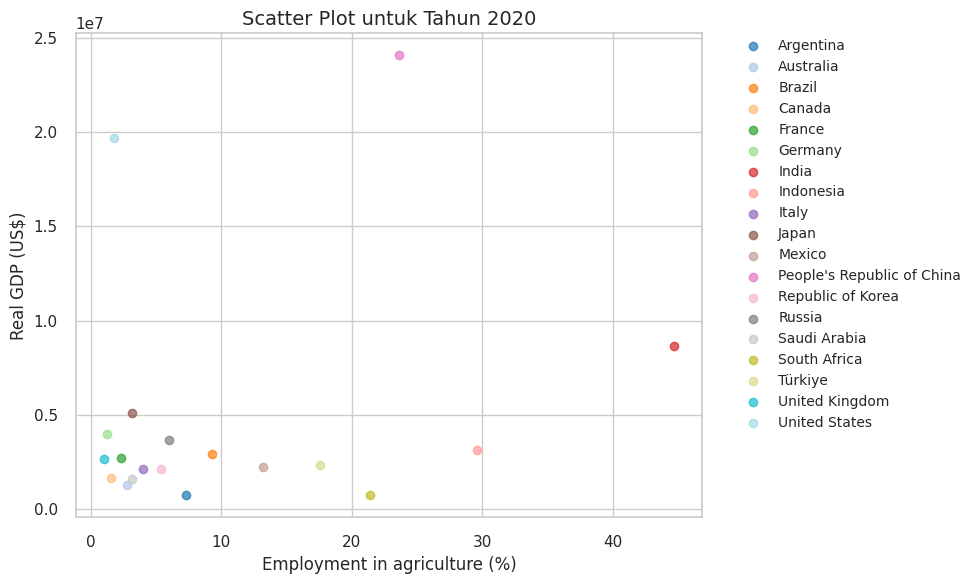

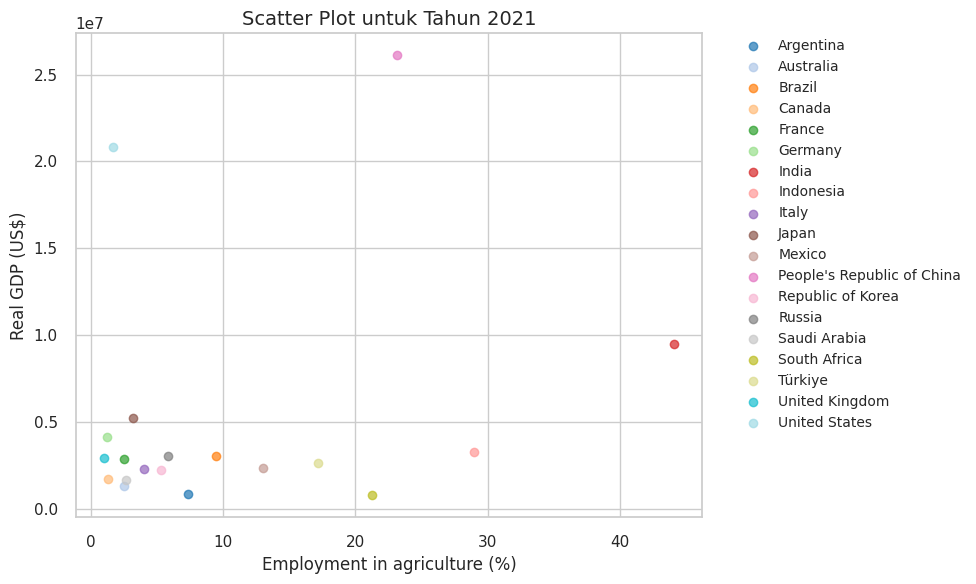

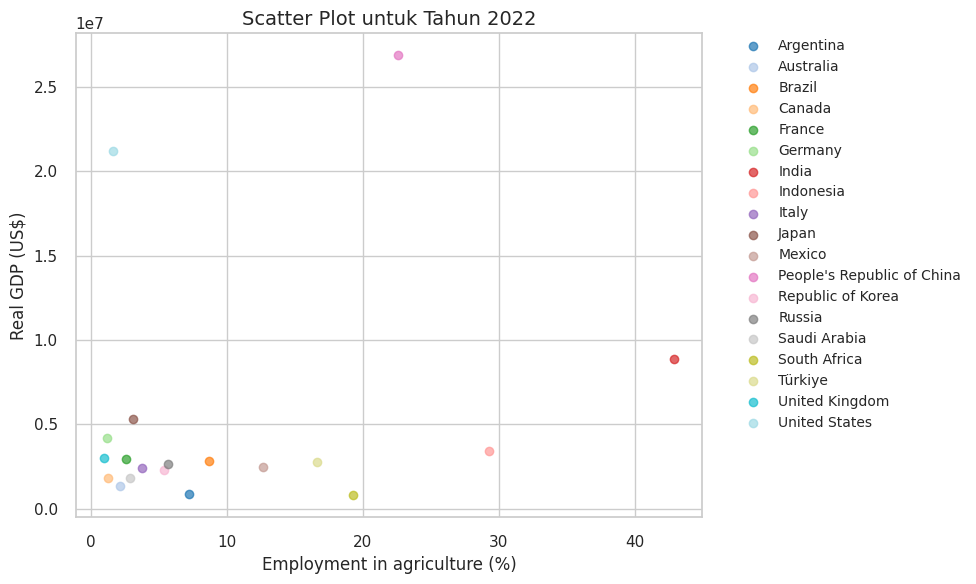

In [57]:
# Membuat scatter plot untuk setiap tahun unik dalam data
for year in df_exploration['Year'].unique():
    plt.figure(figsize=(10, 6))  # Menentukan ukuran grafik yang sesuai

    # Menentukan palet warna untuk 19 negara
    colors = cm.get_cmap('tab20', len(df_exploration['Country'].unique()))  # Menggunakan tab20 untuk 19 warna

    # Iterasi untuk setiap negara unik
    for idx, country in enumerate(df_exploration['Country'].unique()):
        # Membuat subset data berdasarkan tahun dan negara
        subset = df_exploration[(df_exploration['Year'] == year) & (df_exploration['Country'] == country)]

        # Memeriksa apakah subset tidak kosong sebelum memplot
        if not subset.empty:
            # Menggunakan warna yang berbeda untuk setiap negara
            plt.scatter(
                subset['Employment in agriculture (Percentage of total employment) (modeled ILO estimate)'],
                subset['Real GDP (US dollars, PPP converted)'],
                label=country,  # Menambahkan label berdasarkan negara
                alpha=0.7,  # Transparansi scatter untuk visualisasi yang lebih bersih
                color=colors(idx)  # Menentukan warna untuk setiap negara
            )

    # Menambahkan label sumbu x dan y
    plt.xlabel('Employment in agriculture (%)', fontsize=12)
    plt.ylabel('Real GDP (US$)', fontsize=12)

    # Menambahkan judul dengan informasi tahun
    plt.title(f'Scatter Plot untuk Tahun {year}', fontsize=14)

    # Menempatkan legenda di luar area plot agar tidak tumpang tindih
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)

    # Menambahkan grid untuk memperjelas data poin
    plt.grid(True)

    # Menampilkan plot
    plt.tight_layout()  # Menyesuaikan layout agar elemen tidak terpotong
    plt.show()

* **Korelasi Real GDP dan Employment in Agriculture**: Pada scatter plot, data menunjukkan korelasi negatif yang lemah antara Real GDP dan persentase pekerja di sektor pertanian. Negara dengan GDP rendah cenderung memiliki tingkat pekerjaan di pertanian yang lebih tinggi, sementara negara dengan GDP tinggi biasanya memiliki persentase pekerjaan di pertanian yang lebih rendah.

* **Pola Negara Tertentu**: Amerika Serikat, dengan GDP tinggi dan sektor pertanian rendah, menunjukkan pola negara maju dengan sektor industri dominan. India, dengan GDP rendah namun sektor pertanian tinggi, mencerminkan negara berkembang dengan ketergantungan besar pada pertanian.

* **Pengecualian China**: China muncul sebagai anomali dengan sektor pertanian yang stabil di tengah, namun memiliki GDP yang sangat tinggi, menandakan keseimbangan antara industrialisasi dan pertanian yang mendorong ekonomi besar.

#### **Employment in Agriculture vs. Energy productivity, GDP per unit of TES by Country**

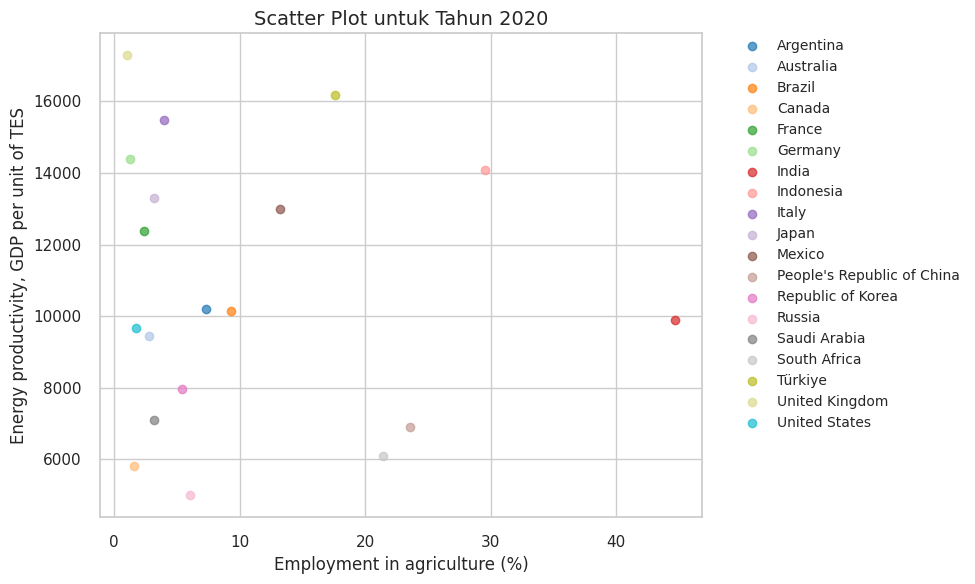

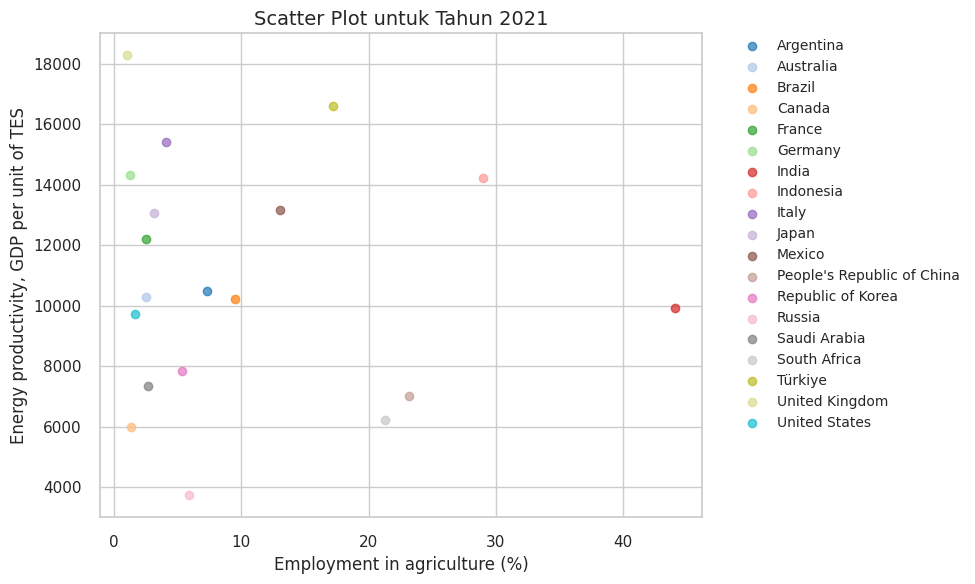

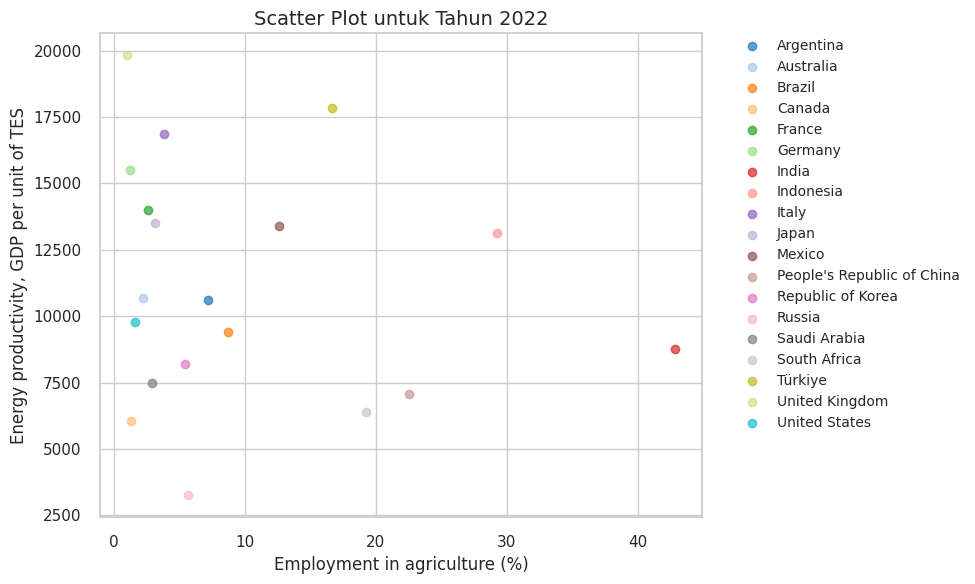

In [58]:
# Tentukan palet warna yang lebih variatif
colors = sns.color_palette("tab20", n_colors=len(df_exploration['Country'].unique()))  # Menggunakan palet tab20 untuk warna yang lebih beragam

# Membuat scatter plot untuk setiap tahun unik dalam data
for year in df_exploration['Year'].unique():
    plt.figure(figsize=(10, 6))  # Menentukan ukuran grafik yang sesuai

    # Iterasi untuk setiap negara unik
    for idx, country in enumerate(df_exploration['Country'].unique()):
        # Membuat subset data berdasarkan tahun dan negara
        subset = df_exploration[(df_exploration['Year'] == year) & (df_exploration['Country'] == country)]

        # Memeriksa apakah subset tidak kosong sebelum memplot
        if not subset.empty:
            plt.scatter(
                subset['Employment in agriculture (Percentage of total employment) (modeled ILO estimate)'],
                subset['Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)'],  # Nama feature sebenarnya
                label=country,  # Menambahkan label untuk negara
                color=colors[idx],  # Menggunakan warna dari palet
                alpha=0.7  # Transparansi untuk visualisasi yang lebih bersih
            )

    # Menambahkan label pada sumbu x dan y
    plt.xlabel('Employment in agriculture (%)', fontsize=12)
    plt.ylabel('Energy productivity, GDP per unit of TES', fontsize=12)

    # Menambahkan judul dengan informasi tahun
    plt.title(f'Scatter Plot untuk Tahun {year}', fontsize=14)

    # Menempatkan legenda di luar area plot untuk memberikan ruang
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)

    # Menambahkan grid untuk memperjelas plot
    plt.grid(True)

    # Menyesuaikan layout agar elemen tidak terpotong
    plt.tight_layout()

    # Menampilkan plot
    plt.show()

* **Korelasi antara Energy Productivity dan Employment in Agriculture**: Scatter plot menunjukkan korelasi positif yang lemah antara produktivitas energi dan persentase pekerjaan di sektor pertanian. Seiring meningkatnya produktivitas energi, persentase pekerjaan di pertanian tetap rendah, mengindikasikan bahwa negara-negara dengan produktivitas energi tinggi cenderung lebih terindustrialisasi dan mengurangi ketergantungan pada pertanian.

* **Pola Umum Negara**: Data menunjukkan bahwa negara-negara dengan produktivitas energi tinggi cenderung memiliki sektor pertanian yang lebih kecil, mencerminkan pergeseran ekonomi dari agraris ke industri dan teknologi.

* **Variasi Data**: Titik-titik data tersebar lebih jauh, mengindikasikan bahwa meskipun produktivitas energi meningkat, terdapat variasi besar antara negara-negara dalam hal struktur ekonomi dan ketergantungan pada sektor pertanian.

### **Correlation Between Features**

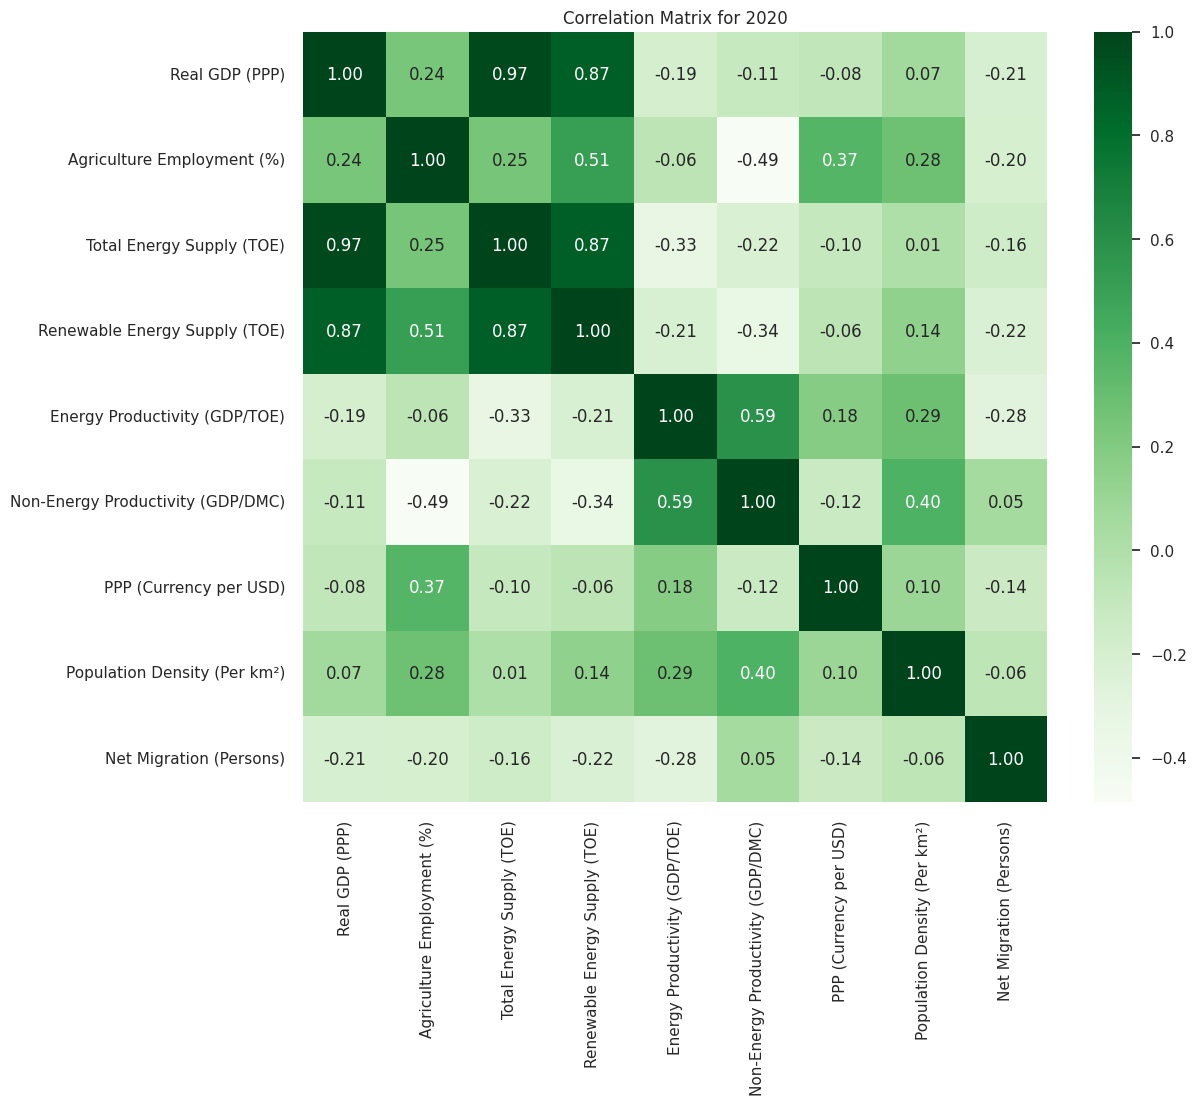

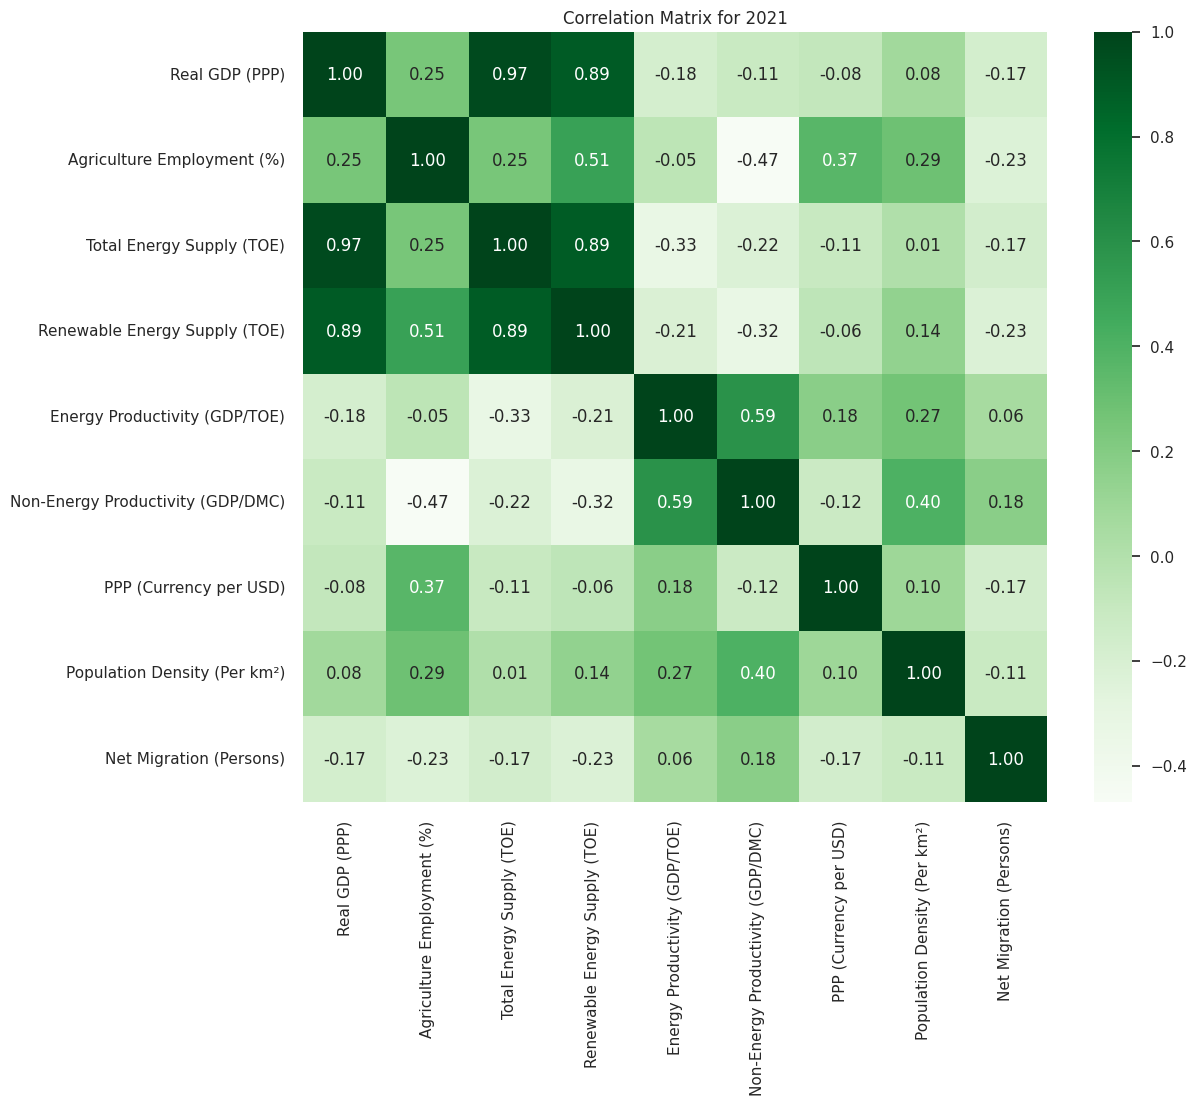

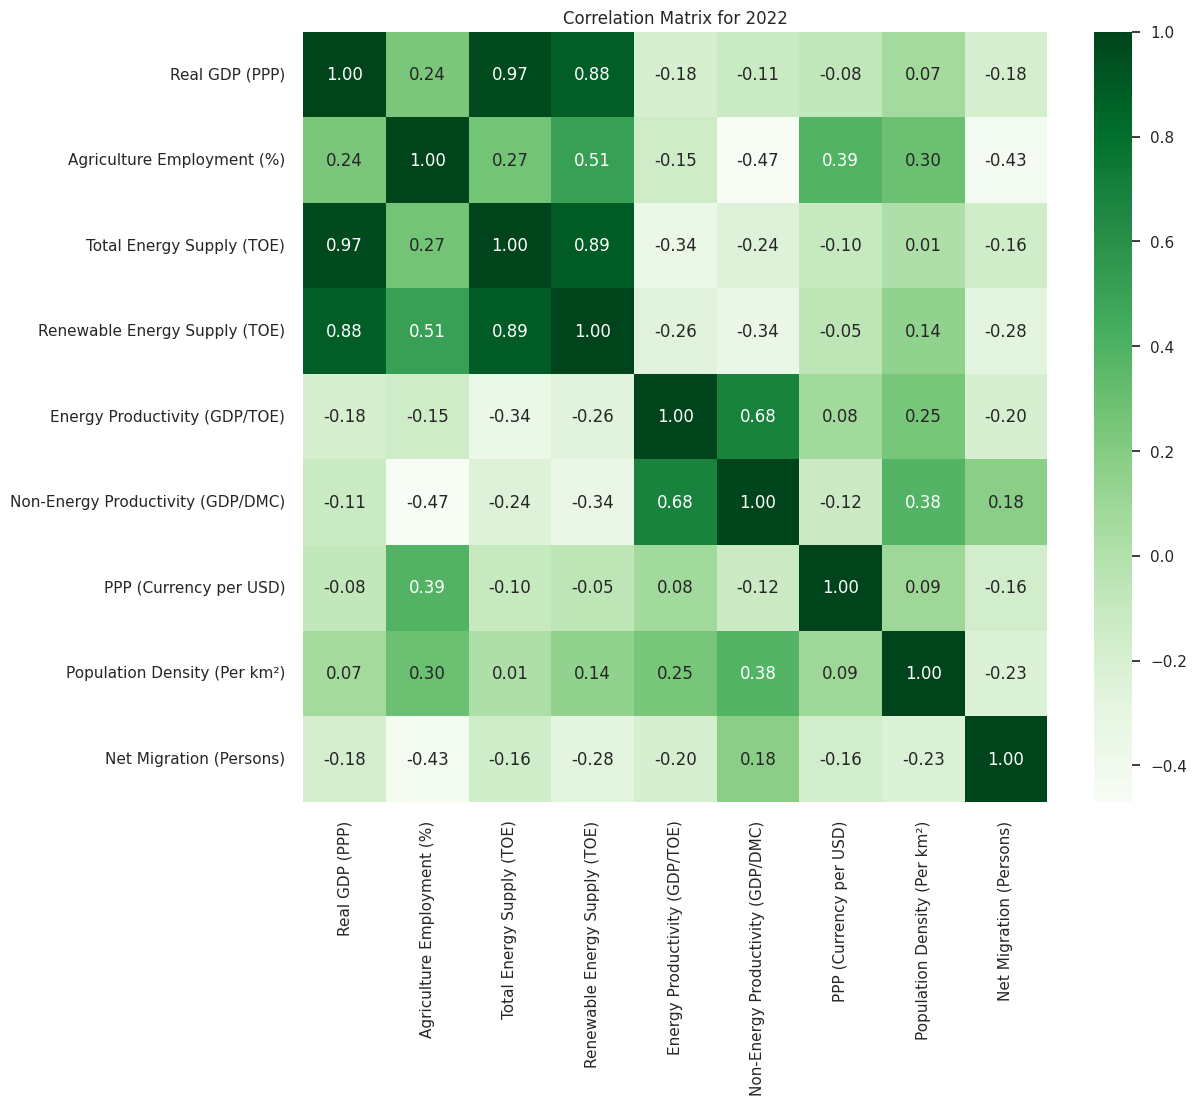

In [59]:
# Mendefinisikan dictionary untuk mengganti nama kolom
column_mapping = {
    'Real GDP (US dollars, PPP converted)': 'Real GDP (PPP)',
    'Employment in agriculture (Percentage of total employment) (modeled ILO estimate)': 'Agriculture Employment (%)',
    'Total energy supply (Tonnes of oil equivalent)': 'Total Energy Supply (TOE)',
    'Renewable energy supply (Tonnes of oil equivalent)': 'Renewable Energy Supply (TOE)',
    'Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)': 'Energy Productivity (GDP/TOE)',
    'Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)': 'Non-Energy Productivity (GDP/DMC)',
    'Purchasing power parity (National currency per US dollar)': 'PPP (Currency per USD)',
    'Population density (Inhabitants per square kilometre)': 'Population Density (Per km²)',
    'Net migration (Persons)': 'Net Migration (Persons)'
}

# Mengelompokkan data berdasarkan tahun
grouped = df_exploration.groupby('Year')

# Looping setiap tahun
for year, year_data in grouped:
    # Memilih fitur numerik dan mengganti nama kolom sesuai mapping
    numerical_features = year_data[[
        'Real GDP (US dollars, PPP converted)',
        'Employment in agriculture (Percentage of total employment) (modeled ILO estimate)',
        'Total energy supply (Tonnes of oil equivalent)',
        'Renewable energy supply (Tonnes of oil equivalent)',
        'Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)',
        'Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)',
        'Purchasing power parity (National currency per US dollar)',
        'Population density (Inhabitants per square kilometre)',
        'Net migration (Persons)'
    ]].rename(columns=column_mapping)

    # Menghitung matriks korelasi untuk tahun tersebut
    year_correlation = numerical_features.corr()

    # Memvisualisasikan matriks korelasi untuk tahun tersebut
    plt.figure(figsize=(12, 10))
    # Menggunakan palet warna 'Greens'
    sns.heatmap(year_correlation, annot=True, cmap='Greens', fmt=".2f")
    plt.title(f'Correlation Matrix for {year}')
    plt.show()

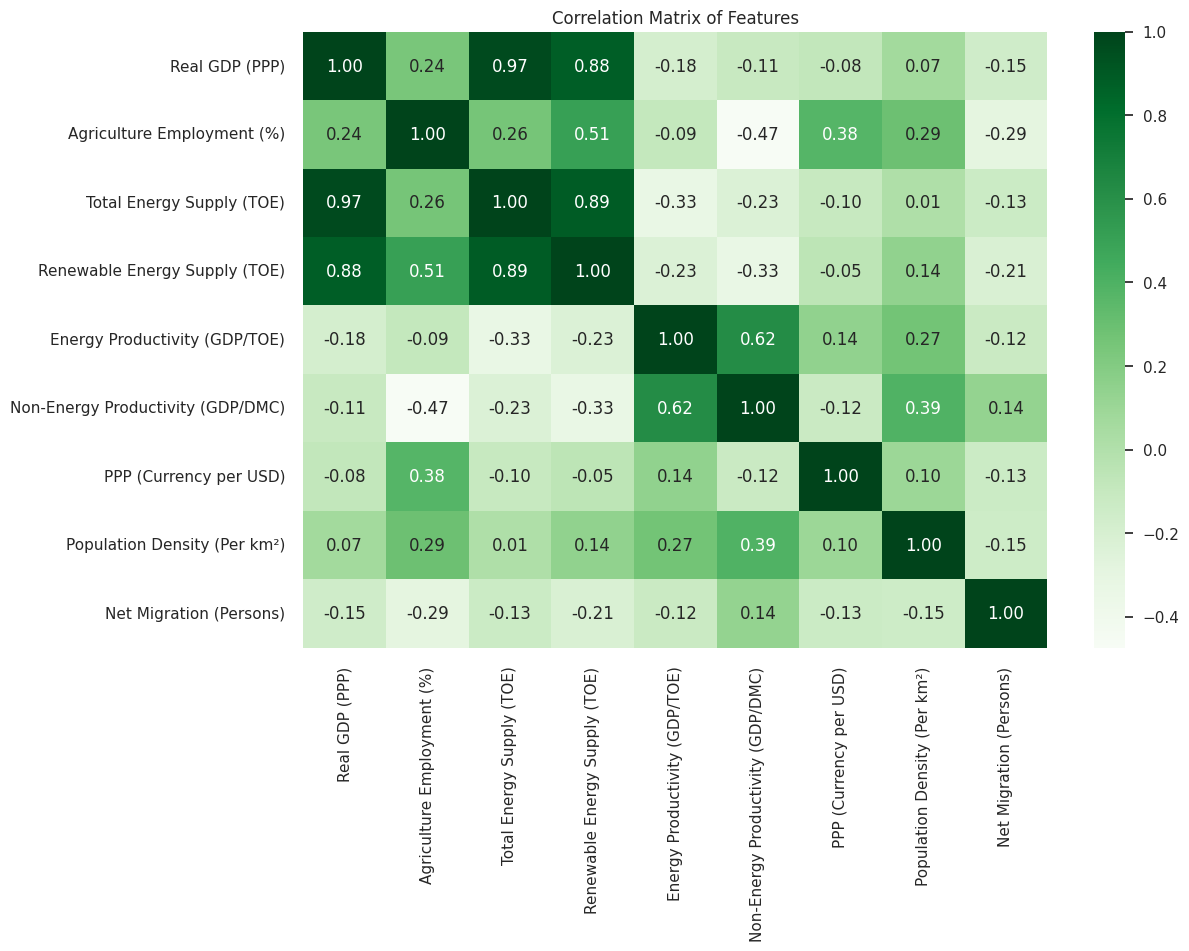

In [60]:
# Mendefinisikan dictionary untuk mengganti nama kolom
column_mapping = {
    'Real GDP (US dollars, PPP converted)': 'Real GDP (PPP)',
    'Employment in agriculture (Percentage of total employment) (modeled ILO estimate)': 'Agriculture Employment (%)',
    'Total energy supply (Tonnes of oil equivalent)': 'Total Energy Supply (TOE)',
    'Renewable energy supply (Tonnes of oil equivalent)': 'Renewable Energy Supply (TOE)',
    'Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)': 'Energy Productivity (GDP/TOE)',
    'Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)': 'Non-Energy Productivity (GDP/DMC)',
    'Purchasing power parity (National currency per US dollar)': 'PPP (Currency per USD)',
    'Population density (Inhabitants per square kilometre)': 'Population Density (Per km²)',
    'Net migration (Persons)': 'Net Migration (Persons)'
}

# Menghitung matriks korelasi untuk beberapa fitur pada G20
correlation_matrix = df_exploration[
    [
        'Real GDP (US dollars, PPP converted)',
        'Employment in agriculture (Percentage of total employment) (modeled ILO estimate)',
        'Total energy supply (Tonnes of oil equivalent)',
        'Renewable energy supply (Tonnes of oil equivalent)',
        'Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)',
        'Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)',
        'Purchasing power parity (National currency per US dollar)',
        'Population density (Inhabitants per square kilometre)',
        'Net migration (Persons)'
    ]
].rename(columns=column_mapping).corr()

# Membuat heatmap dari matriks korelasi
plt.figure(figsize=(12, 8))  # Mengatur ukuran figur
sns.heatmap(correlation_matrix, annot=True, cmap='Greens', fmt=".2f")  # Heatmap dengan anotasi korelasi
plt.title('Correlation Matrix of Features')  # Judul heatmap
plt.show()  # Menampilkan heatmap

* **Korelasi Tinggi antara Real GDP dan Total Energy Supply**: Dengan korelasi 0,97, terdapat hubungan sangat kuat antara Real GDP dan Total Energy Supply, menunjukkan bahwa negara dengan GDP yang lebih tinggi cenderung juga memiliki pasokan energi yang lebih besar, mencerminkan hubungan erat antara pertumbuhan ekonomi dan konsumsi energi.

* **Hubungan Positif antara Renewable Energy Supply dan Energi Total**: Korelasi 0,89 antara Renewable Energy Supply dengan Total Energy Supply serta antara Real GDP dengan Renewable Energy Supply menunjukkan bahwa negara dengan tingkat energi terbarukan yang lebih tinggi biasanya juga memiliki tingkat pasokan energi total yang lebih besar dan GDP yang lebih tinggi.

* **Korelasi antara Employment in Agriculture dan Faktor Lainnya**: Employment in Agriculture menunjukkan korelasi positif moderat dengan Renewable Energy Supply (0,51), yang bisa mengindikasikan bahwa negara dengan ketergantungan lebih besar pada pertanian juga cenderung lebih bergantung pada sumber energi terbarukan. Sebaliknya, ada korelasi negatif dengan Non-Energy Materials Productivity (-0,47), yang mengindikasikan bahwa negara dengan lebih banyak pekerjaan di sektor pertanian cenderung memiliki produktivitas yang lebih rendah di sektor bahan non-energi.

### **Pairplot Between Feature**

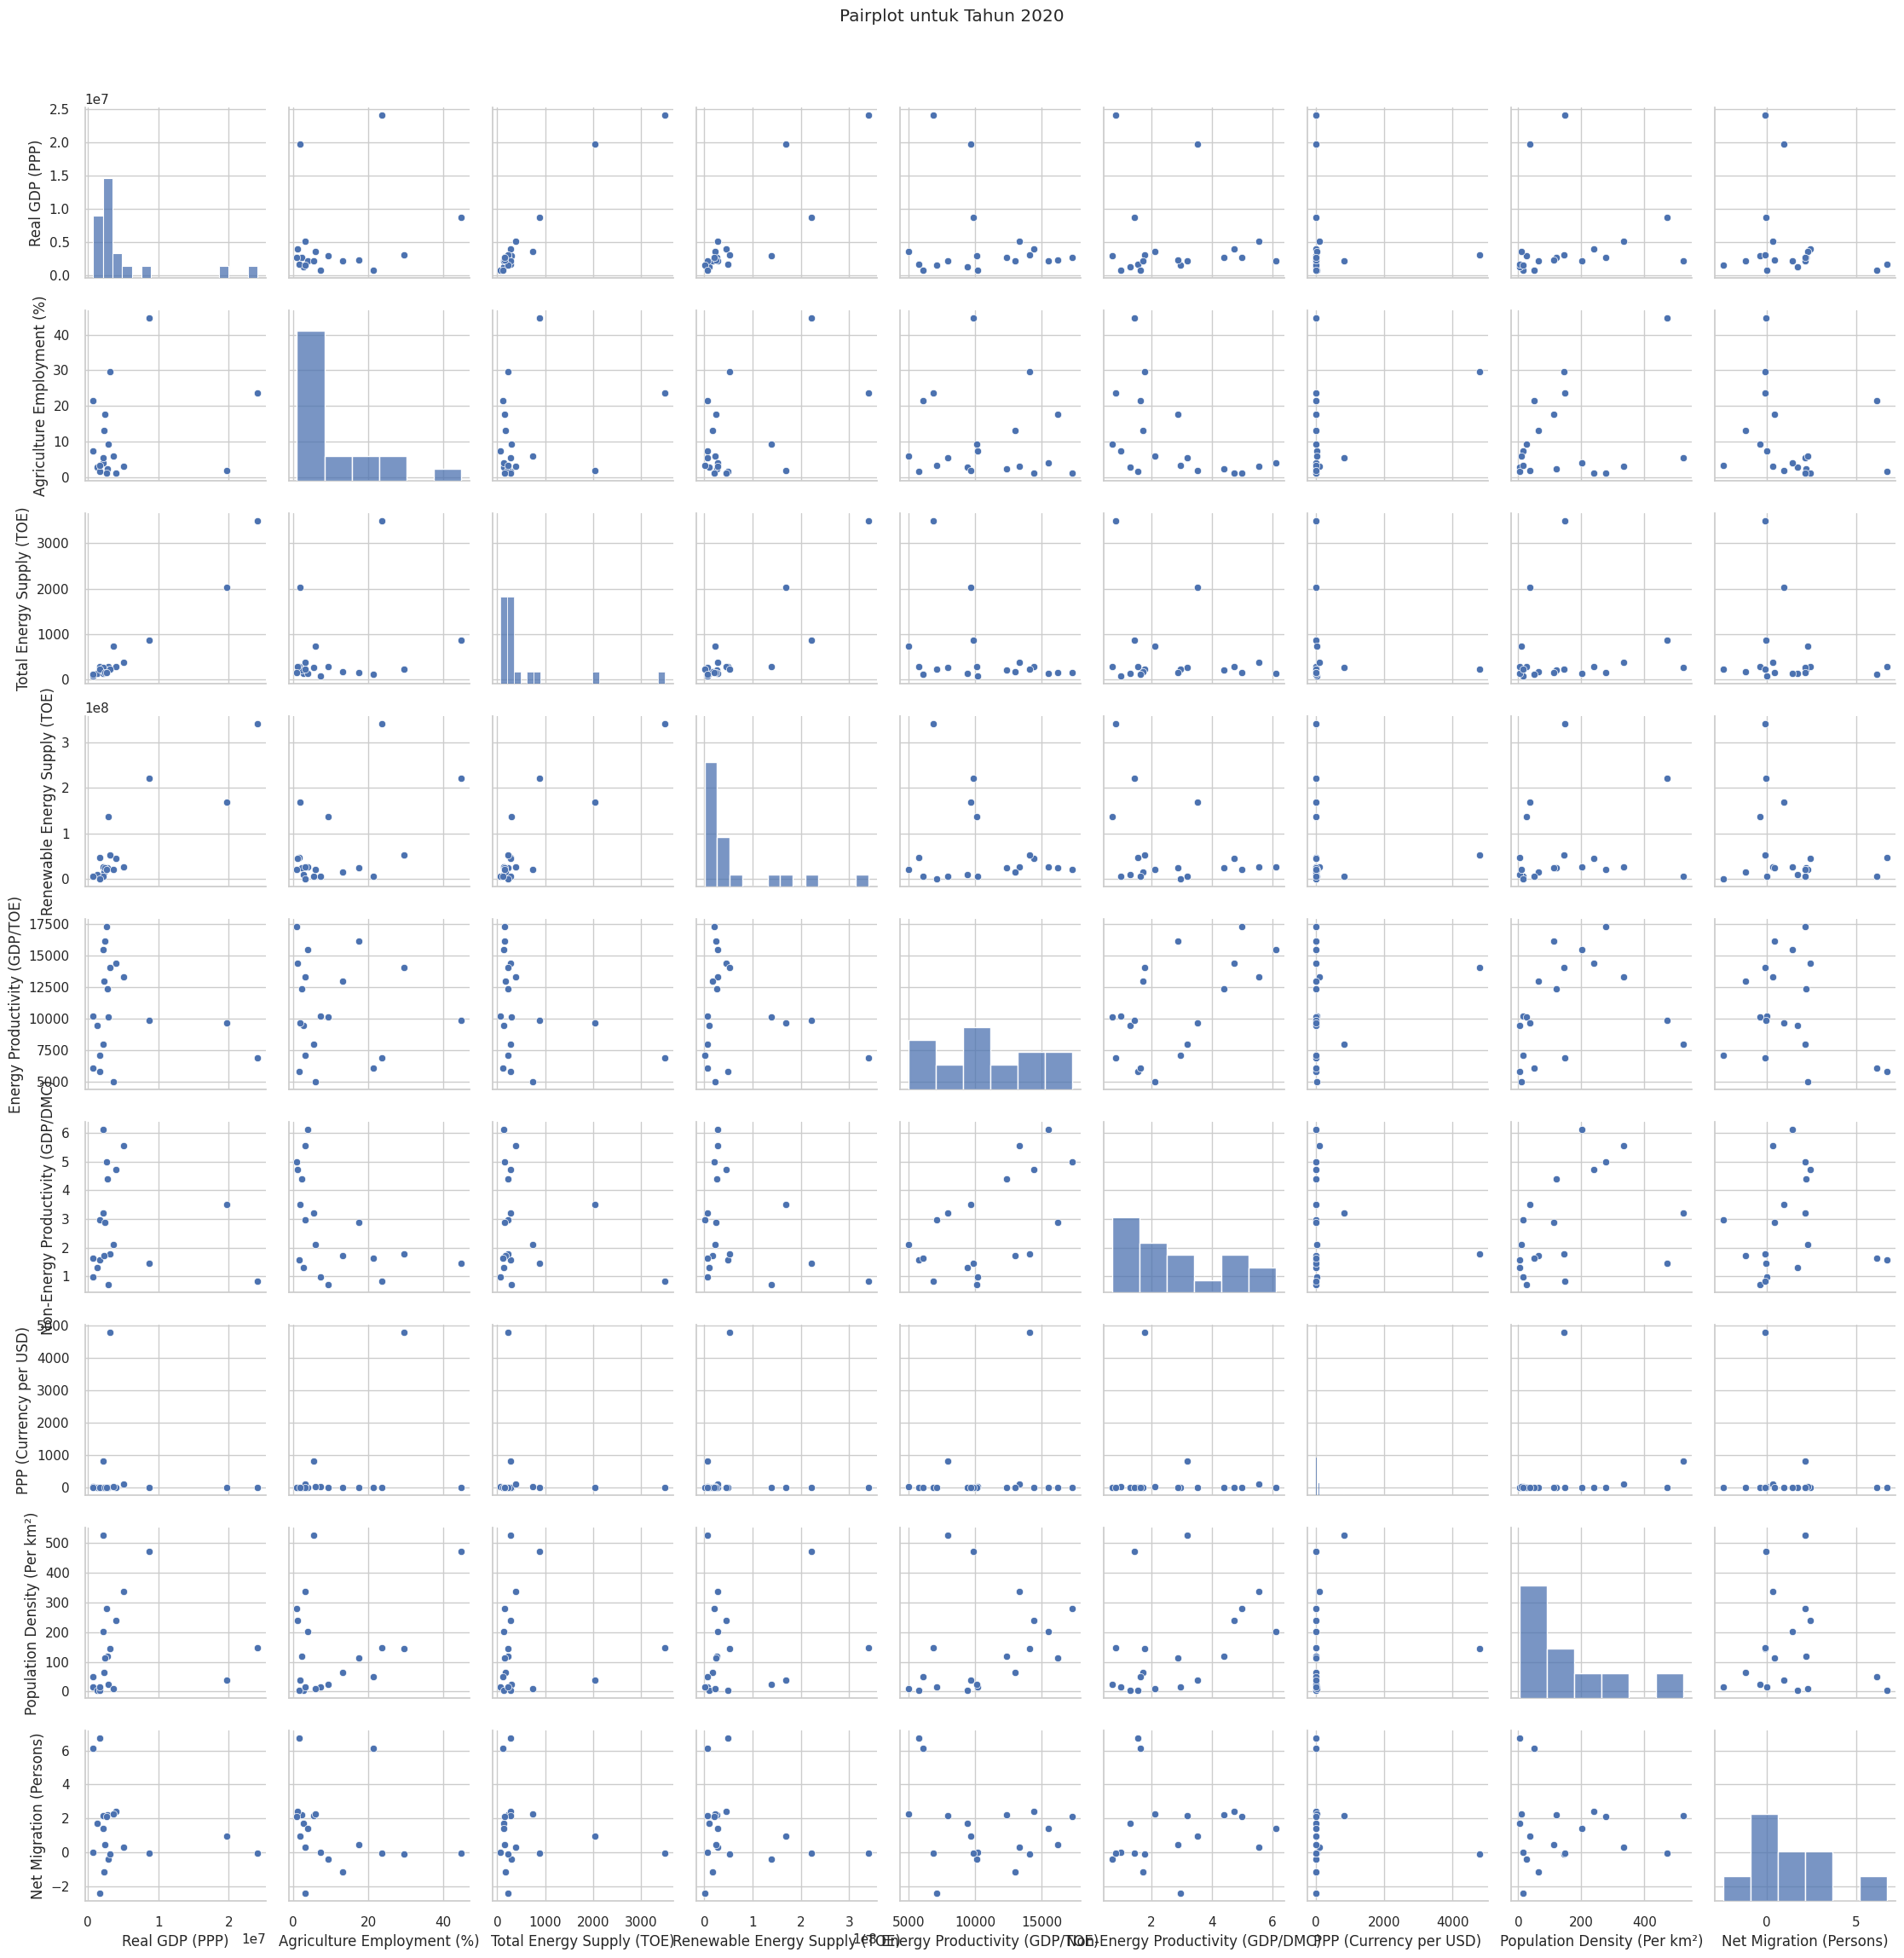

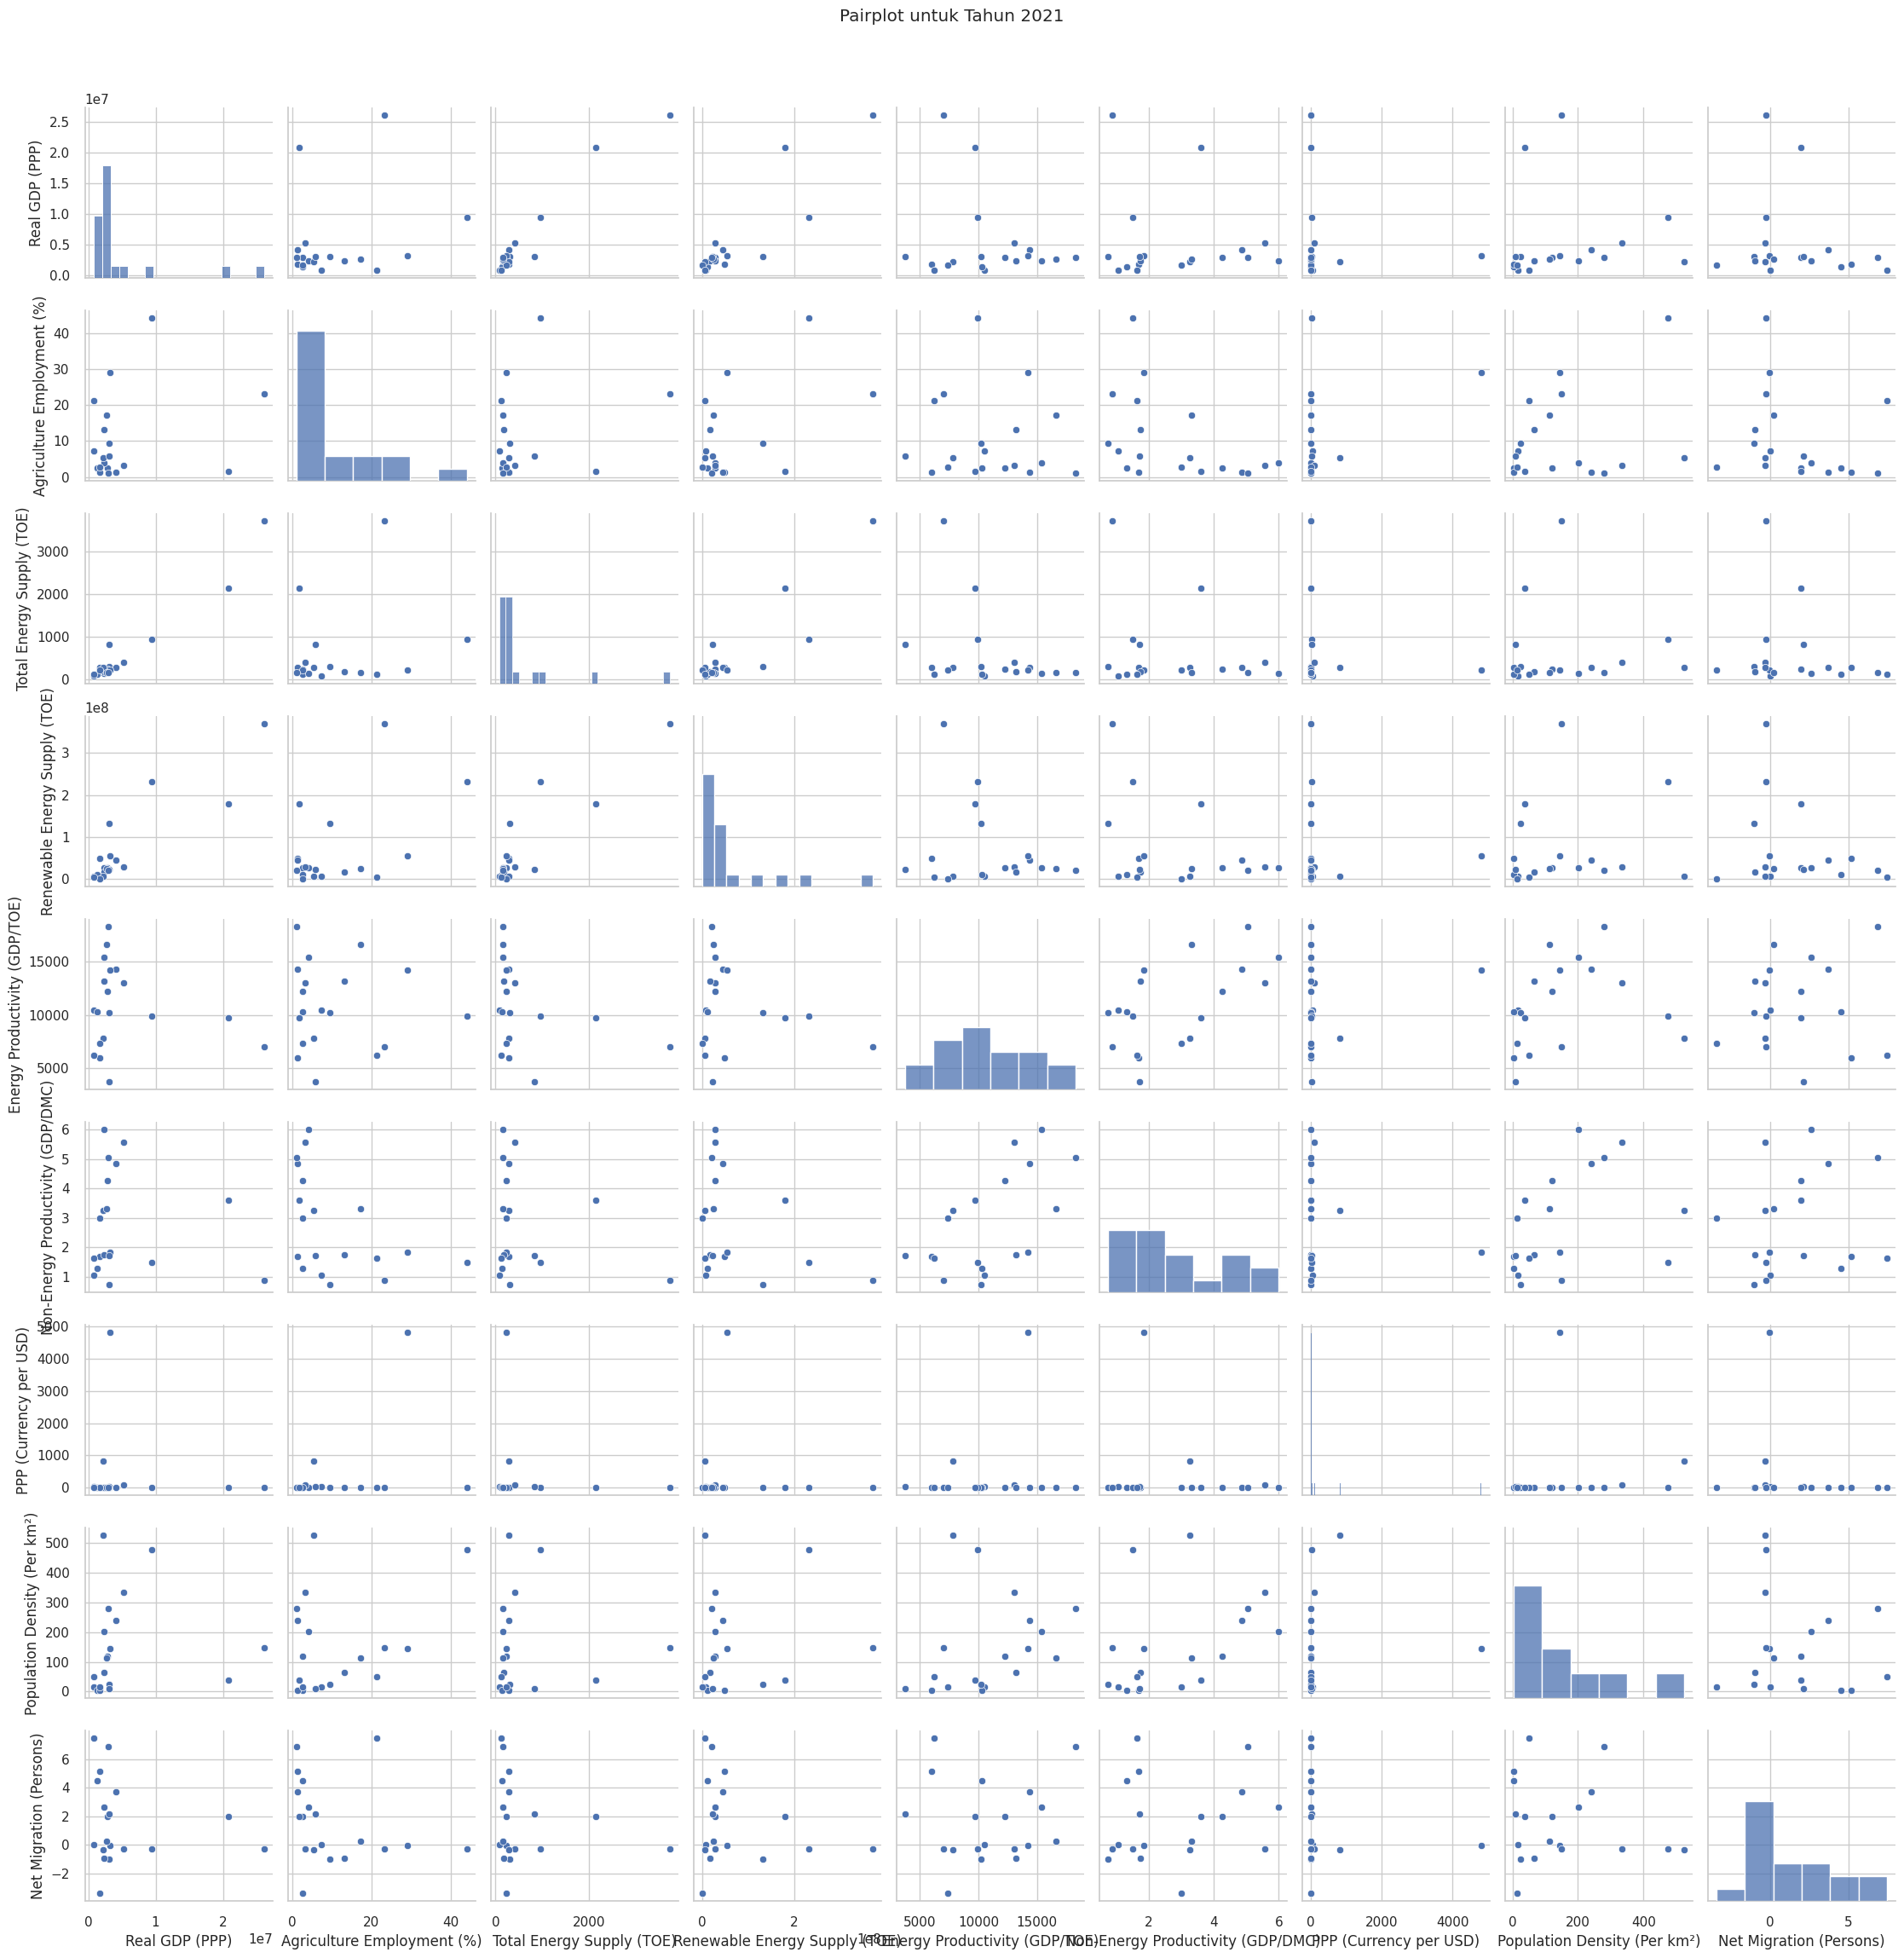

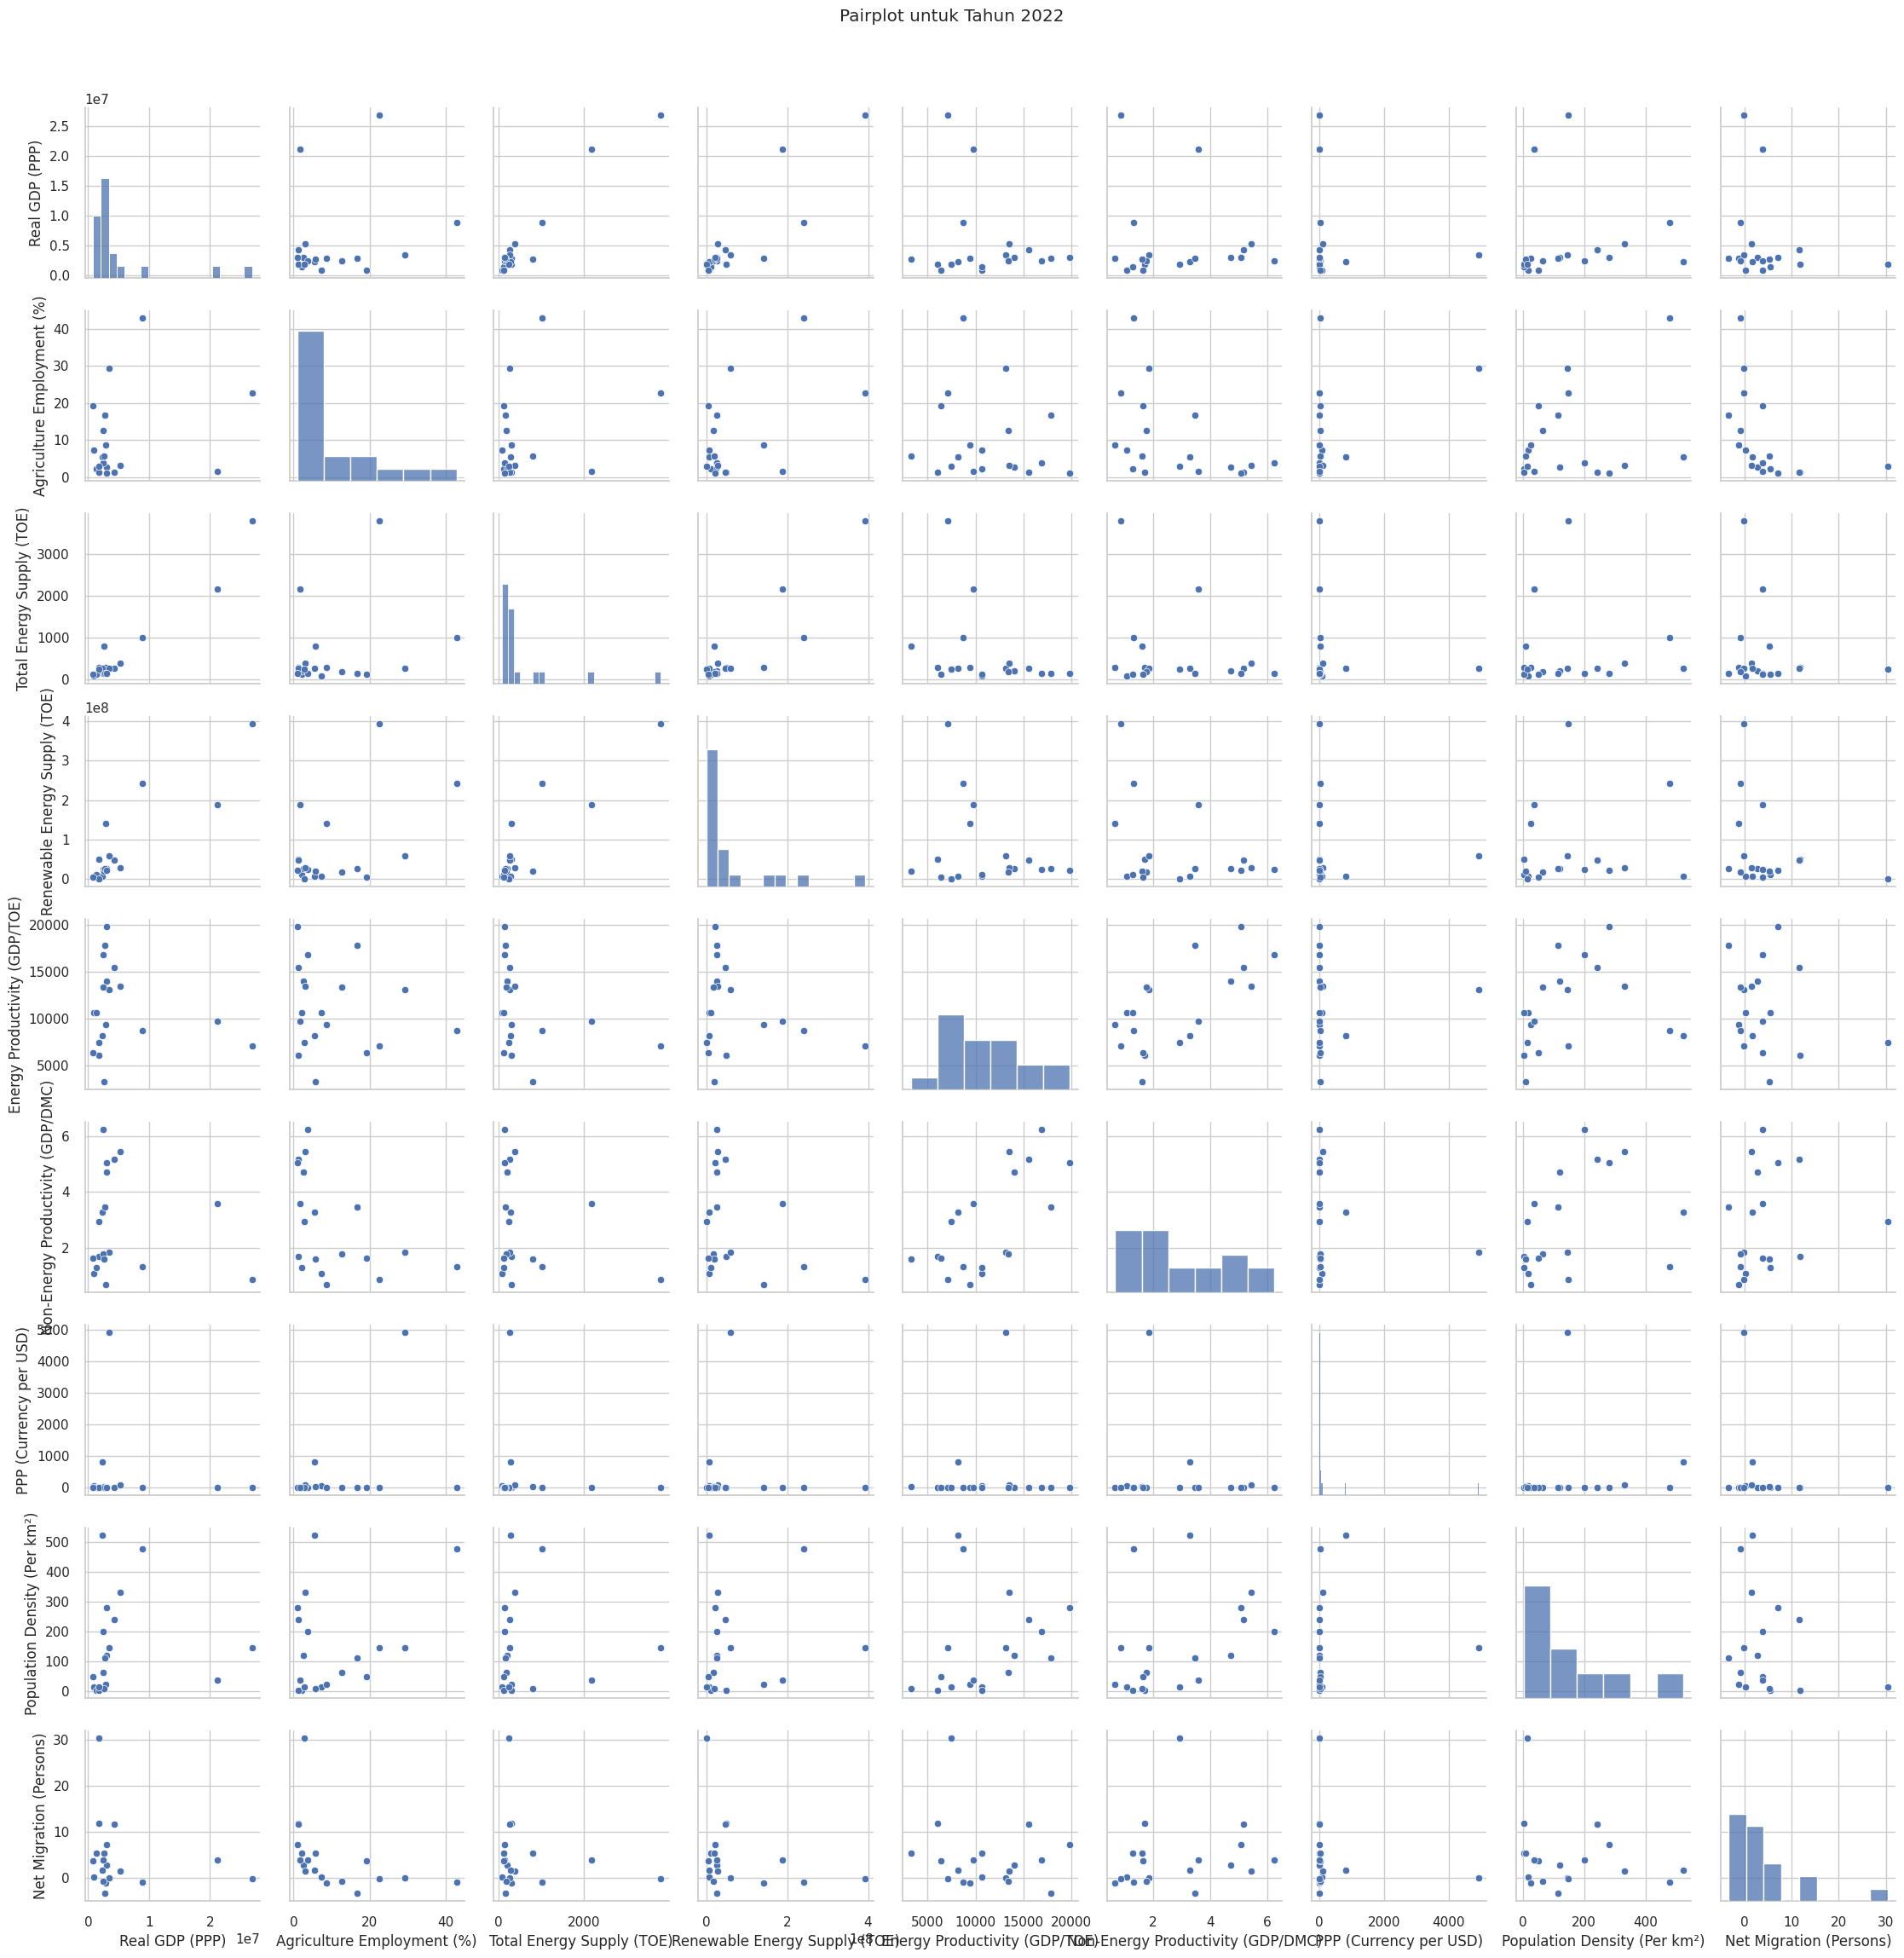

In [61]:
# Mapping nama fitur menjadi lebih singkat untuk visualisasi
feature_rename_mapping = {
    'Real GDP (US dollars, PPP converted)': 'Real GDP (PPP)',
    'Employment in agriculture (Percentage of total employment) (modeled ILO estimate)': 'Agriculture Employment (%)',
    'Total energy supply (Tonnes of oil equivalent)': 'Total Energy Supply (TOE)',
    'Renewable energy supply (Tonnes of oil equivalent)': 'Renewable Energy Supply (TOE)',
    'Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)': 'Energy Productivity (GDP/TOE)',
    'Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)': 'Non-Energy Productivity (GDP/DMC)',
    'Purchasing power parity (National currency per US dollar)': 'PPP (Currency per USD)',
    'Population density (Inhabitants per square kilometre)': 'Population Density (Per km²)',
    'Net migration (Persons)': 'Net Migration (Persons)'
}

# Mendefinisikan fitur yang akan digunakan dalam pairplot (dengan nama yang sudah diganti)
features = list(feature_rename_mapping.values())

# Loop untuk setiap tahun unik di DataFrame
for year in df_exploration['Year'].unique():
    # Membuat subset DataFrame untuk data pada tahun tertentu
    year_data = df_exploration[df_exploration['Year'] == year]

    # Mengganti nama kolom dengan nama yang lebih singkat untuk mempermudah visualisasi
    year_data = year_data.rename(columns=feature_rename_mapping)

    # Membuat pairplot untuk data pada tahun tersebut tanpa hue dan menggunakan warna hijau untuk palet
    g = sns.pairplot(year_data[features])

    # Menambahkan judul pada seluruh plot
    g.fig.suptitle(f'Pairplot untuk Tahun {year}', y=1.02)

    # Mengatur tata letak agar lebih rapi dan mudah dibaca
    plt.tight_layout()
    plt.show()

* **Real GDP dan Total Energy Supply**: Pairplot menunjukkan bahwa negara dengan GDP lebih tinggi cenderung memiliki konsumsi energi yang lebih besar.

* **Real GDP dan Renewable Energy Supply**: Negara dengan GDP lebih tinggi juga cenderung menggunakan lebih banyak energi terbarukan.

* **Employment in Agriculture dan Renewable Energy Supply**: Negara dengan lebih banyak pekerjaan di sektor pertanian memiliki proporsi energi terbarukan yang lebih besar, meskipun hubungan ini tidak sekuat dengan GDP.

* **Employment in Agriculture dan Non-Energy Materials Productivity**: Negara dengan lebih banyak pekerjaan di sektor pertanian cenderung memiliki produktivitas bahan non-energi yang lebih rendah.

### **Geographic Coordinates**

In [62]:
# Mapping nama fitur menjadi lebih singkat untuk visualisasi
columns_to_plot = {
    'Real GDP (US dollars, PPP converted)': 'Real GDP (PPP)',
    'Total energy supply (Tonnes of oil equivalent)': 'Total Energy Supply (TOE)',
    'Renewable energy supply (Tonnes of oil equivalent)': 'Renewable Energy Supply (TOE)',
    'Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)': 'Energy Productivity (GDP/TOE)',
    'Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)': 'Non-Energy Productivity (GDP/DMC)',
    'Purchasing power parity (National currency per US dollar)': 'PPP (Currency per USD)',
    'Population density (Inhabitants per square kilometre)': 'Population Density (Per km²)',
    'Net migration (Persons)': 'Net Migration (Persons)'
}

# Loop untuk membuat visualisasi
for column, short_name in columns_to_plot.items():
    fig = px.choropleth(
        df_exploration,
        locations="Country",
        locationmode='country names',
        color=column,
        hover_name="Country",
        hover_data=["Year"],  # Menampilkan tahun saat hover
        animation_frame="Year",  # Animasi berdasarkan tahun
        color_continuous_scale="Blues",  # Skema warna biru
        title=f"{short_name} Over Time",  # Judul peta
        range_color=[df_exploration[column].min(), df_exploration[column].max()]  # Rentang warna sesuai data kolom
    )

    # Menyesuaikan judul legend agar mengikuti short_name
    fig.update_layout(
        coloraxis_colorbar_title=short_name  # Mengubah judul legend
    )

    # Menampilkan peta
    fig.show()

* **Pertumbuhan Real GDP dan Total Energy Supply (USA dan China)**: Pada peta visualisasi, terlihat bahwa warna biru semakin gelap pada negara Amerika Serikat dan China antara tahun 2020-2022, menunjukkan peningkatan signifikan dalam Real GDP dan Total Energy Supply di kedua negara ini.

* **Population Density (India dan Australia)**: India terlihat dengan warna biru yang lebih pekat, menandakan kepadatan populasi yang lebih tinggi dibandingkan negara lainnya. Sebaliknya, Australia memiliki warna biru yang sangat pudar, menunjukkan kepadatan populasi yang jauh lebih rendah.

In [63]:
# Mapping nama fitur menjadi lebih singkat untuk visualisasi
columns_to_plot = {
    'Employment in agriculture (Percentage of total employment) (modeled ILO estimate)': 'Agriculture Employment (%)'
}

# Kolom yang ingin dipilih untuk analisis persentase
percentage_column = 'Employment in agriculture (Percentage of total employment) (modeled ILO estimate)'

# Hitung rata-rata berdasarkan negara
average_percentage = (
    df_exploration.groupby('Country')[percentage_column]
    .mean()
    .reset_index()
)

# Gabungkan data rata-rata dengan dataframe eksplorasi
df_average = pd.merge(
    df_exploration,
    average_percentage,
    on='Country',
    suffixes=('', '_average')
)

# Visualisasi berdasarkan rata-rata persentase
short_name = columns_to_plot[percentage_column]  # Menggunakan nama pendek untuk kolom ini

fig = px.choropleth(
    df_average,
    locations="Country",
    locationmode='country names',
    color=f"{percentage_column}_average",  # Gunakan kolom rata-rata
    hover_name="Country",
    color_continuous_scale="Greens",  # Skema warna hijau
    title=f"Average {short_name} by Country",  # Judul dengan nama pendek
    range_color=[
        df_average[f"{percentage_column}_average"].min(),
        df_average[f"{percentage_column}_average"].max()
    ]
)

# Menyesuaikan judul legend agar sesuai dengan short_name
fig.update_layout(
    coloraxis_colorbar_title=short_name  # Mengubah judul legend dengan short_name
)

# Menampilkan peta
fig.show()

* **Employment in Agriculture (India)**: Pada visualisasi peta, India terlihat dengan warna hijau gelap yang lebih pekat, menunjukkan bahwa sekitar 43% dari total pekerjaannya terlibat dalam sektor pertanian.

* **Negara dengan Tingkat Pekerjaan Pertanian Sedang**: Negara seperti Indonesia, China, dan South Africa memiliki nilai sekitar 20%, dengan warna hijau yang lebih terang, menandakan proporsi pekerjaan di sektor pertanian yang moderat.

* **Negara dengan Pekerjaan Pertanian Rendah (Canada, USA, Australia)**: Negara-negara seperti Kanada, Amerika Serikat, dan Australia memiliki warna hijau yang sangat pudar, dengan nilai antara 1-2%, menunjukkan sangat sedikitnya pekerja yang terlibat dalam sektor pertanian.

# **Data Modelling**

## **Feature Selection**

In [64]:
# Membuat salinan dari DataFrame untuk proses clustering gabungan semua tahun
df_all_years = df.copy()

In [65]:
# Tahun yang akan dianalisis
years = [2020, 2021, 2022]

# Feature-feature yang digunakan
columns_to_use = [
    'Country',
    'Real GDP (US dollars, PPP converted)',
    'Employment in agriculture (Percentage of total employment) (modeled ILO estimate)',
    'Total energy supply (Tonnes of oil equivalent)',
    'Renewable energy supply (Tonnes of oil equivalent)',
    'Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)',
    'Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)',
    'Purchasing power parity (National currency per US dollar)',
    'Population density (Inhabitants per square kilometre)',
    'Net migration (Persons)'
]

## **Normalize**

In [66]:
# Gabungkan data dari seluruh tahun
df_all_years = pd.concat([df_all_years[df_all_years['Year'] == year][columns_to_use] for year in years])

# Normalisasi data untuk feature numerik
columns_to_scale = columns_to_use[1:]  # Kolom numerik yang akan diskalakan
scaler = MinMaxScaler()
df_all_years[columns_to_scale] = scaler.fit_transform(df_all_years[columns_to_scale])

# Output: Menampilkan data yang telah digabungkan dan dinormalisasi
print("Data after merging and normalization:")
df_all_years.head()


Data after merging and normalization:


,Country,"Real GDP (US dollars, PPP converted)",Employment in agriculture (Percentage of total employment) (modeled ILO estimate),Total energy supply (Tonnes of oil equivalent),Renewable energy supply (Tonnes of oil equivalent),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)","Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)",Purchasing power parity (National currency per US dollar),Population density (Inhabitants per square kilometre),Net migration (Persons)
0,Argentina,0.000291,0.143822,0.000000,0.017080,0.419079,0.057451,0.005342,0.024656,0.102572
3,Australia,0.020114,0.040326,0.016296,0.024976,0.373636,0.114901,0.000169,0.000000,0.153414
6,Brazil,0.082935,0.190268,0.057346,0.350230,0.415203,0.005386,0.000337,0.041496,0.091043
9,Canada,0.034798,0.012626,0.056699,0.122074,0.153552,0.159785,0.000122,0.001632,0.300916
12,France,0.074809,0.030801,0.038802,0.065574,0.550287,0.671454,0.000018,0.223093,0.167603


## **Dimensionality Reduction**

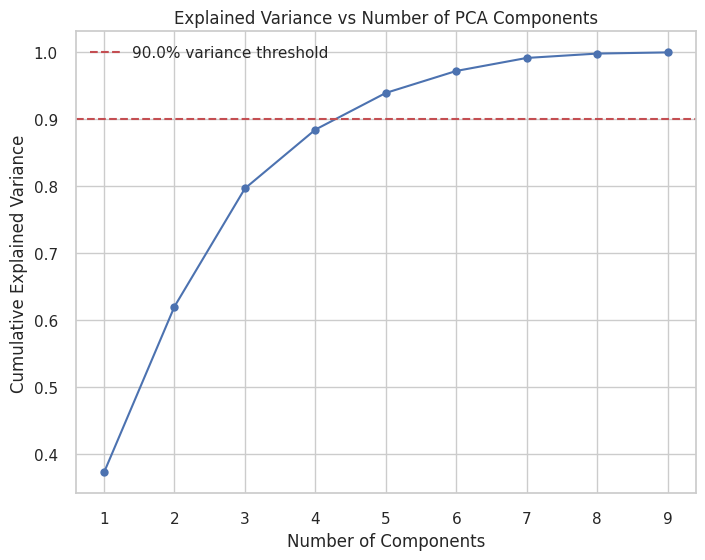

Optimal PCA components: 5
Data after PCA reduction to 5 components:
[[-0.05961642 -0.45424703  0.08241252 -0.00653697 -0.12138422]
 [-0.09058874 -0.46523906 -0.02858146 -0.01902944 -0.0474301 ]
 [ 0.19998854 -0.36101622  0.04779024  0.01803419 -0.17649919]
 [ 0.00138271 -0.49858219 -0.1167943  -0.14397698  0.11323226]
 [-0.33979582  0.05500999 -0.1741878   0.04259291 -0.00403121]]


In [67]:
# Tentukan jumlah komponen PCA berdasarkan explained variance
def find_optimal_pca_components(data, variance_threshold=0.9):
    pca_temp = PCA()
    pca_temp.fit(data)
    cumulative_variance = np.cumsum(pca_temp.explained_variance_ratio_)

    # Cari jumlah komponen yang memenuhi threshold
    optimal_components = np.argmax(cumulative_variance >= variance_threshold) + 1
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
    plt.axhline(y=variance_threshold, color='r', linestyle='--', label=f'{variance_threshold*100}% variance threshold')
    plt.title("Explained Variance vs Number of PCA Components")
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.legend()
    plt.show()

    return optimal_components

# Cari jumlah komponen terbaik untuk PCA
optimal_pca_components = find_optimal_pca_components(df_all_years[columns_to_scale])
print(f"Optimal PCA components: {optimal_pca_components}")

# Terapkan PCA dengan jumlah komponen terbaik
pca = PCA(n_components=optimal_pca_components)
X_pca = pca.fit_transform(df_all_years[columns_to_scale])

# Output: Data hasil reduksi PCA
print(f"Data after PCA reduction to {optimal_pca_components} components:")
print(X_pca[:5])  # Menampilkan 5 data pertama setelah PCA

## **Elbow Method**

Elbow Method to determine the number of clusters to be formed:


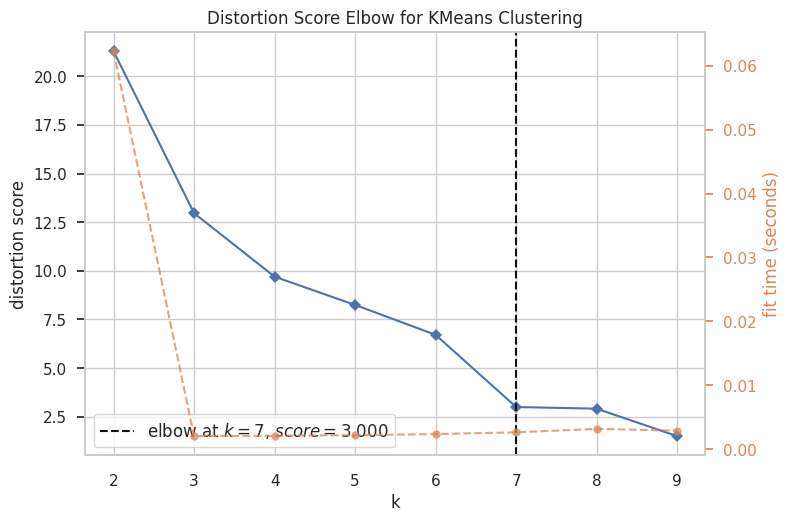

Optimal number of clusters (k): 7


In [68]:
# Quick examination of elbow method to find numbers of clusters to make.
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(random_state=42), k=(2, 10))  # k=range untuk jumlah cluster
Elbow_M.fit(X_pca)  # X_pca adalah dataset hasil PCA atau dataset yang dianalisis
Elbow_M.show()  # Menampilkan plot Elbow Method

# Mendapatkan jumlah cluster optimal
optimal_k = Elbow_M.elbow_value_
print(f"Optimal number of clusters (k): {optimal_k}")

## **Evaluation Model**

In [69]:
# Clustering dengan KMeans
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
silhouette_kmeans = silhouette_score(X_pca, kmeans_labels)
print(f"Silhouette Score (KMeans, all years): {silhouette_kmeans}")

# Clustering dengan DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
if len(set(dbscan_labels)) > 1:
    silhouette_dbscan = silhouette_score(X_pca, dbscan_labels)
    print(f"Silhouette Score (DBSCAN, all years): {silhouette_dbscan}")
else:
    silhouette_dbscan = -1  # Tidak valid jika hanya 1 cluster
    print("DBSCAN failed to form clusters for all years")

# Clustering dengan Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k)
agg_labels = agg_clustering.fit_predict(X_pca)
silhouette_agg = silhouette_score(X_pca, agg_labels)
print(f"Silhouette Score (Agglomerative, all years): {silhouette_agg}")


Silhouette Score (KMeans, all years): 0.6609437558728966
Silhouette Score (DBSCAN, all years): 0.38727206383168894
Silhouette Score (Agglomerative, all years): 0.6609437558728966


In [70]:
# Memilih model terbaik berdasarkan silhouette score
best_model = max(
    [
        ('KMeans', silhouette_kmeans, kmeans_labels),
        ('DBSCAN', silhouette_dbscan, dbscan_labels),
        ('Agglomerative', silhouette_agg, agg_labels),
    ],
    key=lambda x: x[1]  # Pilih model dengan silhouette tertinggi
)

best_model_name, best_score, best_labels = best_model
print(f"Best model for all years: {best_model_name} with silhouette score {best_score}")

# Menambahkan hasil clustering ke DataFrame
df_all_years['Cluster_Best'] = best_labels

# Output: Hasil clustering terbaik
print("Clustering results added to the DataFrame:")
print(df_all_years[['Country', 'Cluster_Best']].head())


Best model for all years: KMeans with silhouette score 0.6609437558728966
Clustering results added to the DataFrame:
      Country  Cluster_Best
0   Argentina             0
3   Australia             0
6      Brazil             0
9      Canada             0
12     France             1


Berikut adalah insight singkat dari hasil analisis:

- **PCA**: Pengurangan dimensi berhasil mengurangi data ke dalam 5 komponen utama dengan variasi yang cukup signifikan, memungkinkan representasi data yang lebih sederhana dan efisien.
  
- **Jumlah Cluster Optimal**: Berdasarkan analisis elbow, jumlah cluster optimal yang ditemukan adalah 7, menunjukkan adanya 7 kelompok yang dapat diidentifikasi dalam data.

- **Skor Silhouette**:
  - **KMeans**: Memiliki skor silhouette tertinggi (0.66), yang menunjukkan bahwa cluster yang dihasilkan cukup terpisah dengan baik.
  - **DBSCAN**: Memiliki skor yang lebih rendah (0.39), mengindikasikan bahwa DBSCAN tidak memberikan hasil cluster yang baik pada data ini.
  - **Agglomerative Clustering**: Memiliki skor yang sama dengan KMeans (0.66), menunjukkan hasil clustering yang serupa dengan KMeans.

- **Model Terbaik**: Model clustering terbaik untuk semua tahun adalah **KMeans**, yang memiliki skor silhouette tertinggi, menunjukkan pemisahan cluster yang paling baik.

## **Model Visualization**

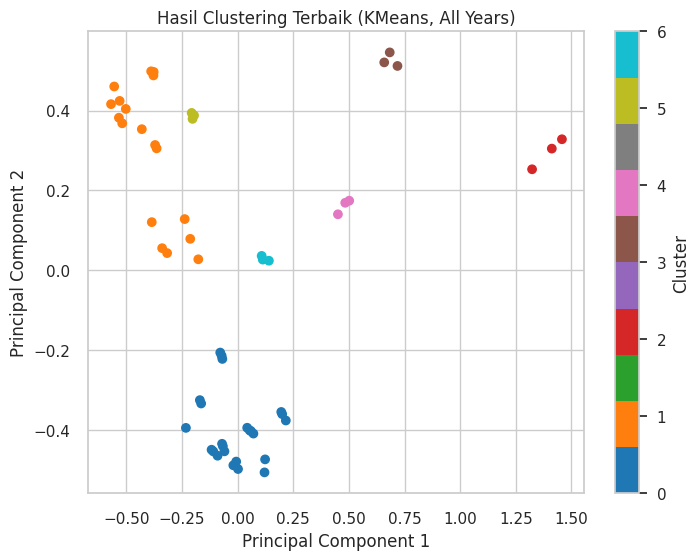

In [71]:
# Visualisasi hasil clustering terbaik
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap=plt.cm.tab10)
plt.title(f'Hasil Clustering Terbaik ({best_model_name}, All Years)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

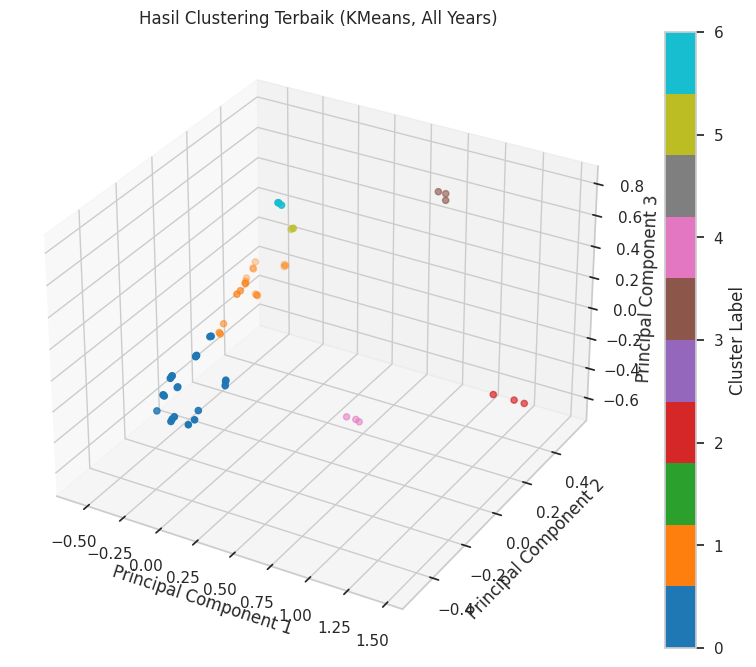

In [72]:
# Membuat plot 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot data dengan label cluster
colors = [plt.cm.tab10(i) for i in range(7)]  # Ambil 7 warna dari colormap tab10
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=best_labels, cmap=plt.cm.tab10)

# Menambahkan label dan judul
ax.set_title(f'Hasil Clustering Terbaik ({best_model_name}, All Years)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Menampilkan color bar untuk menggambarkan cluster
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster Label')

# Menampilkan plot
plt.show()

In [73]:
import plotly.graph_objects as go

# Warna dari Tab10 untuk 7 kategori
tab10_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

# Konversi warna Tab10 ke colorscale
tab10_colorscale = [[i / (len(tab10_colors) - 1), color] for i, color in enumerate(tab10_colors)]

# Tambahkan peta dasar menggunakan Choropleth
fig = go.Figure(data=go.Choropleth(
    locations=df_all_years['Country'],
    locationmode='country names',
    z=df_all_years['Cluster_Best'],
    text=df_all_years['Cluster_Best'],  # Nama kluster sebagai teks
    colorscale=tab10_colorscale,  # Warna Tab10
    colorbar_title="Cluster",
    colorbar=dict(lenmode="fraction", len=0.5, y=0.5)  # Sesuaikan panjang dan posisi legenda
))

# Tambahkan teks di peta tanpa legenda untuk trace
for _, row in df_all_years.iterrows():
    fig.add_trace(go.Scattergeo(
        locationmode='country names',
        locations=[row['Country']],
        text=row['Cluster_Best'],  # Menampilkan nama kluster
        mode='text',
        showlegend=False,  # Menyembunyikan legend untuk trace ini
        textfont=dict(color='black', size=10)  # Penyesuaian tampilan teks
    ))

# Perbarui tata letak peta
fig.update_layout(
    title="Clustering Results (All Years) - Map Visualization",
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    legend_title="Cluster Categories",  # Judul legenda
    legend=dict(
        title=dict(text="Cluster Categories", font=dict(size=14)),
        font=dict(size=12),
        yanchor="top",
        y=1.0,
        xanchor="left",
        x=1.0  # Posisi legenda
    )
)

fig.show()

In [74]:
# Analisis per cluster untuk gabungan semua tahun
print("\nCluster analysis for all years:")

# Iterasi melalui cluster, memastikan urutannya
for cluster_label in sorted(df_all_years['Cluster_Best'].unique()):
    cluster_members = df_all_years[df_all_years['Cluster_Best'] == cluster_label]
    average_conditions = cluster_members[columns_to_scale].mean()
    unique_countries = set(cluster_members['Country'])  # Ambil negara unik

    print(f"Cluster {cluster_label}:")
    print("Unique Countries:", list(unique_countries))  # Konversi kembali ke list untuk ditampilkan
    print("Average conditions:")
    print(average_conditions)
    print("-" * 40)


Cluster analysis for all years:
Cluster 0:
Unique Countries: ['Australia', 'Saudi Arabia', 'Russia', 'Argentina', 'South Africa', 'Brazil', 'Canada', 'Mexico']
Average conditions:
Real GDP (US dollars, PPP converted)                                                 0.042069
Employment in agriculture (Percentage of total employment) (modeled ILO estimate)    0.156441
Total energy supply (Tonnes of oil equivalent)                                       0.051294
Renewable energy supply (Tonnes of oil equivalent)                                   0.078679
Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)    0.310280
Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)    0.167564
Purchasing power parity (National currency per US dollar)                            0.002179
Population density (Inhabitants per square kilometre)                                0.038694
Net migration (Persons)                                            

Insights Karakteristik Setiap Cluster

**Cluster 0**: Negara Berkembang dengan Ekonomi Menengah
- **Negara**: Mexico, Argentina, Saudi Arabia, Canada, Russia, Brazil, South Africa, Australia.
- **Karakteristik**:
  - Ekonomi relatif stabil dengan kontribusi besar dari sektor non-pertanian.
  - Penggunaan energi total dan energi terbarukan cukup tinggi.
  - Produktivitas energi dan material sedang.
  - Kepadatan populasi rendah hingga sedang.
  - Negara-negara ini cenderung memiliki kontribusi besar pada energi dan bahan baku global.

---

 **Cluster 1**: Negara Industri Maju
- **Negara**: Italy, Japan, Türkiye, United Kingdom, France, Germany.
- **Karakteristik**:
  - Ekonomi maju dengan tingkat produktivitas energi dan material tinggi.
  - Ketergantungan pada sektor pertanian sangat rendah.
  - Kepadatan populasi tinggi.
  - Tingkat migrasi stabil, menunjukkan daya tarik ekonomi dan sosial.

---

 **Cluster 2**: Raksasa Ekonomi dengan Pertanian Besar
- **Negara**: People's Republic of China.
- **Karakteristik**:
  - Ekonomi besar dengan total pasokan energi tertinggi di antara cluster lainnya.
  - Ketergantungan signifikan pada sektor pertanian.
  - Produktivitas energi dan material rendah.
  - Kepadatan populasi sedang dengan migrasi rendah.

---

 **Cluster 3**: Negara Berkembang dengan Ketergantungan Tinggi pada Pertanian
- **Negara**: India.
- **Karakteristik**:
  - Ketergantungan sangat tinggi pada sektor pertanian.
  - Pasokan energi total sedang, tetapi kontribusi energi terbarukan signifikan.
  - Kepadatan populasi sangat tinggi.
  - Produktivitas energi dan material rendah dibandingkan rata-rata global.

---

 **Cluster 4**: Superpower Ekonomi
- **Negara**: United States.
- **Karakteristik**:
  - Ekonomi besar dengan produktivitas material tinggi.
  - Ketergantungan rendah pada sektor pertanian.
  - Pasokan energi dan penggunaan energi terbarukan tinggi.
  - Kepadatan populasi rendah, tetapi migrasi tinggi, mencerminkan daya tarik ekonomi.

---

 **Cluster 5**: Negara Industri Modern dengan Kepadatan Tinggi
- **Negara**: Republic of Korea.
- **Karakteristik**:
  - Ekonomi kecil hingga menengah dengan produktivitas material sangat tinggi.
  - Kepadatan populasi tertinggi di antara cluster lainnya.
  - Ketergantungan rendah pada energi terbarukan.
  - Migrasi stabil dengan kontribusi minimal dari sektor pertanian.

---

 **Cluster 6**: Negara Berkembang dengan Peran Energi Terbarukan
- **Negara**: Indonesia.
- **Karakteristik**:
  - Ketergantungan signifikan pada sektor pertanian.
  - Penggunaan energi terbarukan cukup tinggi dibandingkan dengan pasokan total energi.
  - Kepadatan populasi sedang.
  - Produktivitas energi sedang, tetapi produktivitas material rendah.

---

 Kesimpulan Umum
Setiap cluster menunjukkan tingkat perkembangan ekonomi, ketergantungan pada sektor pertanian, dan pola konsumsi energi yang berbeda. Negara maju cenderung memiliki produktivitas tinggi dengan ketergantungan rendah pada pertanian, sedangkan negara berkembang menunjukkan kontribusi besar sektor pertanian dan energi terbarukan.

In [75]:
# Membuat salinan DataFrame untuk proses clustering
df_cluster = df.copy()

In [76]:
# Tahun yang akan dianalisis
years = [2020, 2021, 2022]

# Feature-feature yang digunakan
columns_to_use = [
    'Country',
    'Real GDP (US dollars, PPP converted)',
    'Employment in agriculture (Percentage of total employment) (modeled ILO estimate)',
    'Total energy supply (Tonnes of oil equivalent)',
    'Renewable energy supply (Tonnes of oil equivalent)',
    'Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)',
    'Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)',
    'Purchasing power parity (National currency per US dollar)',
    'Population density (Inhabitants per square kilometre)',
    'Net migration (Persons)'
]

Processing year: 2020
----------------------------------------
Data for 2020 after normalization:


,Country,"Real GDP (US dollars, PPP converted)",Employment in agriculture (Percentage of total employment) (modeled ILO estimate),Total energy supply (Tonnes of oil equivalent),Renewable energy supply (Tonnes of oil equivalent),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)","Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)",Purchasing power parity (National currency per US dollar),Population density (Inhabitants per square kilometre),Net migration (Persons)
0,Argentina,0.000326,0.143252,0.000000,0.019747,0.423521,0.053506,0.005482,0.024656,0.265060
3,Australia,0.022542,0.039686,0.017777,0.028876,0.362304,0.112546,0.000167,0.000000,0.453450
6,Brazil,0.092948,0.189729,0.062560,0.404918,0.418299,0.000000,0.000340,0.041496,0.222344
9,Canada,0.039000,0.011968,0.061854,0.141136,0.065827,0.158672,0.000119,0.001632,1.000000
12,France,0.083841,0.030155,0.042329,0.075814,0.600271,0.684502,0.000013,0.223093,0.506024



Finding optimal PCA components...


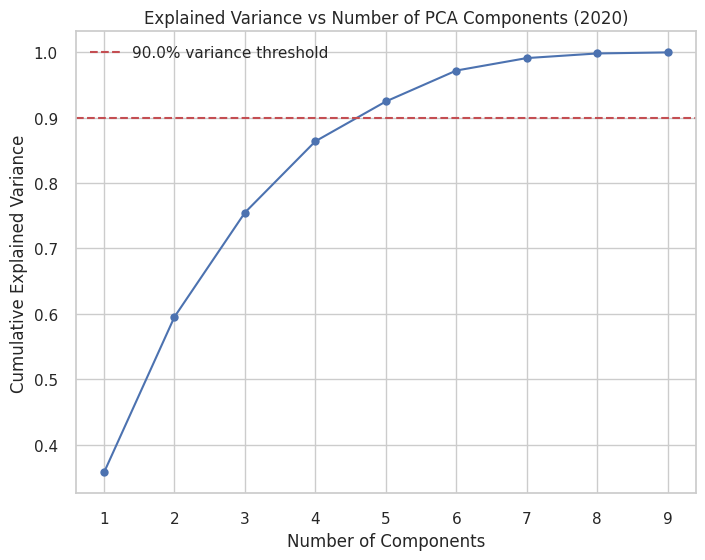

Optimal PCA components for 2020: 5
PCA-transformed data for 2020 (first 5 rows):
[[-6.03733844e-02 -4.08158263e-01  1.44334466e-01 -2.08686820e-01
  -1.77580796e-01]
 [-8.86325031e-02 -4.72839615e-01 -2.55493304e-04 -9.74650036e-02
  -5.40167211e-02]
 [ 2.32809965e-01 -2.78368427e-01  1.19700717e-01 -2.40510182e-01
  -1.88154593e-01]
 [ 1.79030423e-02 -6.78338667e-01 -1.93457690e-01  3.54012302e-01
   2.44622802e-01]
 [-3.66409220e-01  4.22019978e-02 -2.05671215e-01 -1.54305236e-02
   7.05633614e-02]]
Elbow Method to determine the number of clusters to be formed:


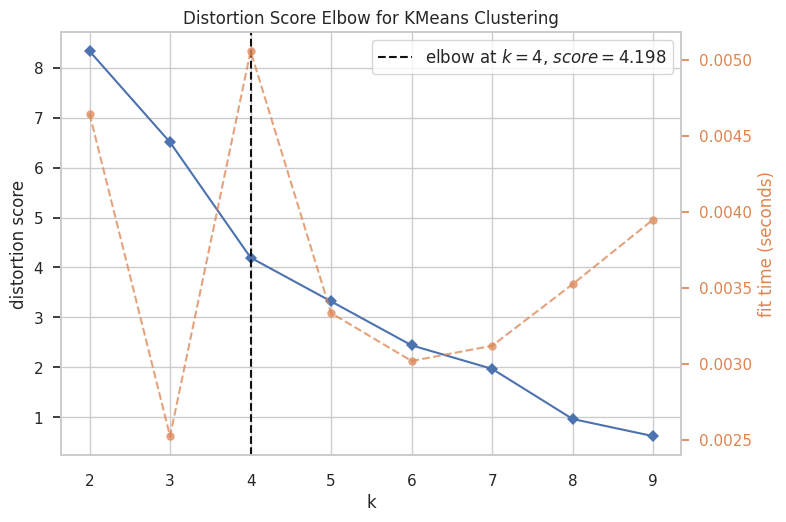

Optimal number of clusters (k): 4

Clustering with different methods...
Silhouette Score (KMeans, 2020): 0.33080105019906325
Silhouette Score (DBSCAN, 2020): 0.25845282073039916
Silhouette Score (Agglomerative, 2020): 0.35736198014557774
Best model for 2020: Agglomerative with silhouette score 0.35736198014557774


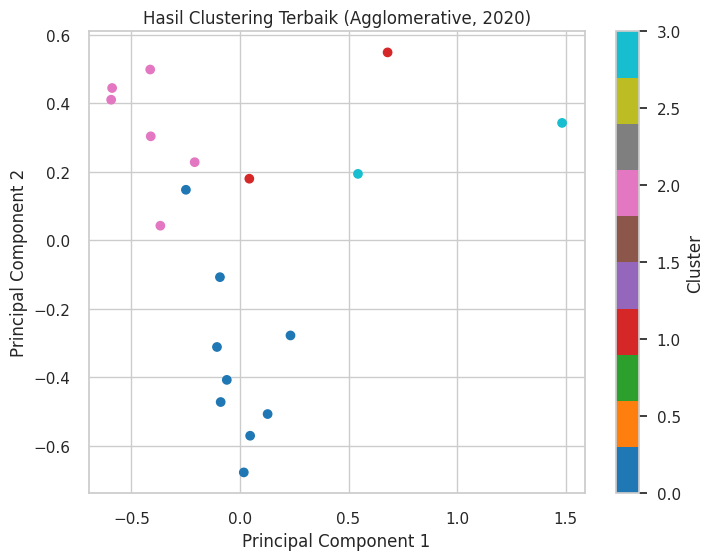

Processing year: 2021
----------------------------------------
Data for 2021 after normalization:


,Country,"Real GDP (US dollars, PPP converted)",Employment in agriculture (Percentage of total employment) (modeled ILO estimate),Total energy supply (Tonnes of oil equivalent),Renewable energy supply (Tonnes of oil equivalent),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)","Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)",Purchasing power parity (National currency per US dollar),Population density (Inhabitants per square kilometre),Net migration (Persons)
1,Argentina,0.002064,0.146377,0.000000,0.018420,0.464826,0.060837,0.007937,0.024681,0.313653
4,Australia,0.022237,0.033969,0.014092,0.029373,0.450266,0.108365,0.000166,0.000000,0.727860
7,Brazil,0.090097,0.196601,0.060435,0.357039,0.446521,0.000000,0.000366,0.041660,0.220480
10,Canada,0.037992,0.007088,0.058151,0.130934,0.154936,0.180608,0.000116,0.001633,0.789668
13,France,0.082946,0.033887,0.042971,0.073497,0.583366,0.671103,0.000015,0.223705,0.496310



Finding optimal PCA components...


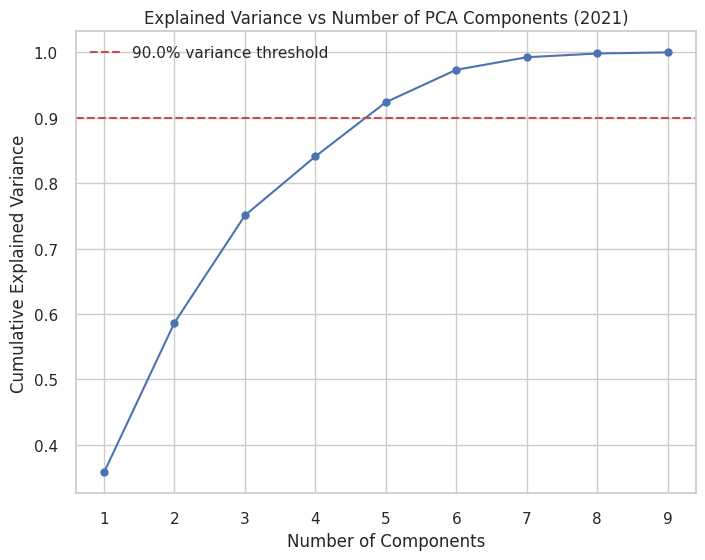

Optimal PCA components for 2021: 5
PCA-transformed data for 2021 (first 5 rows):
[[-0.05566039 -0.4452319   0.12641333 -0.16336241 -0.00180166]
 [-0.16130109 -0.48054523 -0.09503247  0.16754252  0.07406696]
 [ 0.23452106 -0.35260439  0.11266928 -0.20410257  0.01404207]
 [-0.05372233 -0.52920695 -0.21401329  0.23472443 -0.0818408 ]
 [-0.33704104  0.06236636 -0.16523724 -0.07352904  0.02443388]]
Elbow Method to determine the number of clusters to be formed:


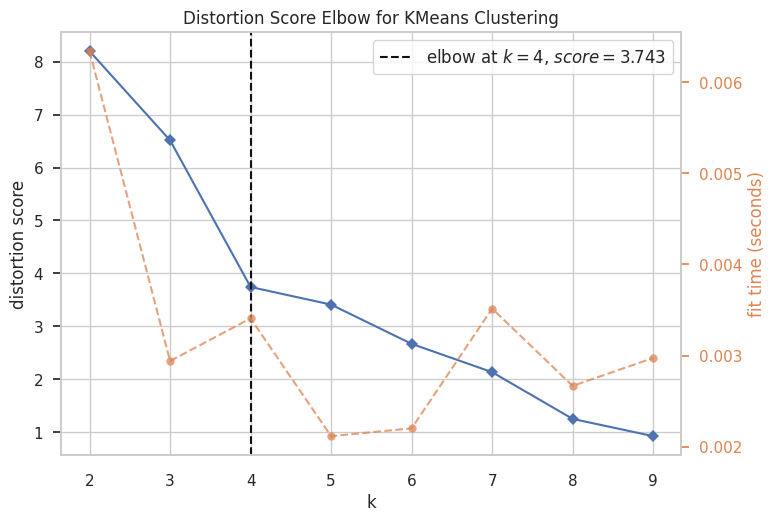

Optimal number of clusters (k): 4

Clustering with different methods...
Silhouette Score (KMeans, 2021): 0.34511460485267287
Silhouette Score (DBSCAN, 2021): 0.27568688221843435
Silhouette Score (Agglomerative, 2021): 0.34511460485267287
Best model for 2021: KMeans with silhouette score 0.34511460485267287


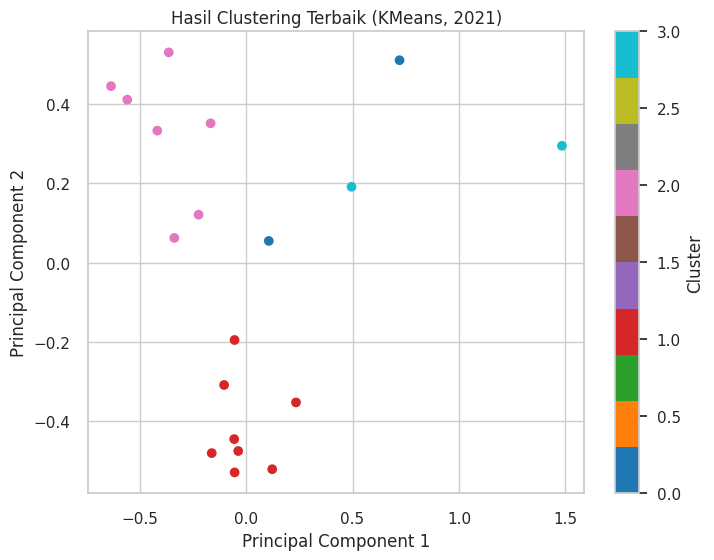

Processing year: 2022
----------------------------------------
Data for 2022 after normalization:


,Country,"Real GDP (US dollars, PPP converted)",Employment in agriculture (Percentage of total employment) (modeled ILO estimate),Total energy supply (Tonnes of oil equivalent),Renewable energy supply (Tonnes of oil equivalent),"Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)","Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)",Purchasing power parity (National currency per US dollar),Population density (Inhabitants per square kilometre),Net migration (Persons)
2,Argentina,0.003141,0.148150,0.000000,0.018561,0.444687,0.073609,0.012354,0.024714,0.105823
5,Australia,0.021742,0.028541,0.012121,0.030217,0.447910,0.109515,0.000156,0.000000,0.261307
8,Brazil,0.077940,0.184597,0.058748,0.359264,0.370813,0.000000,0.000368,0.041831,0.066509
11,Canada,0.038850,0.006733,0.057844,0.126684,0.170036,0.183124,0.000114,0.001654,0.452557
14,France,0.083067,0.037810,0.034710,0.066292,0.649108,0.727110,0.000014,0.224618,0.182383



Finding optimal PCA components...


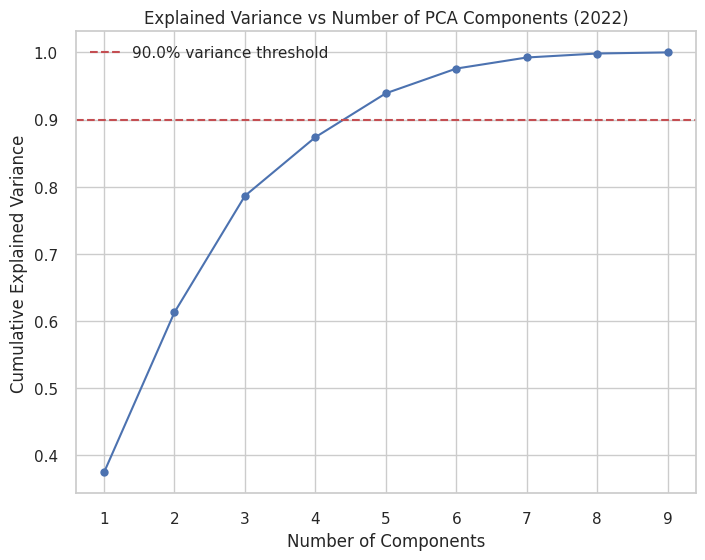

Optimal PCA components for 2022: 5
PCA-transformed data for 2022 (first 5 rows):
[[-0.06288237 -0.41377079  0.13314901 -0.1208028  -0.19603773]
 [-0.12327071 -0.44749971 -0.0120737  -0.07711004 -0.10677791]
 [ 0.22752292 -0.35930458  0.08933318 -0.10675835 -0.22421321]
 [-0.03244536 -0.52769168 -0.14460069  0.14819987  0.05758147]
 [-0.38187117  0.1310797  -0.15175918 -0.11732939 -0.05061131]]
Elbow Method to determine the number of clusters to be formed:


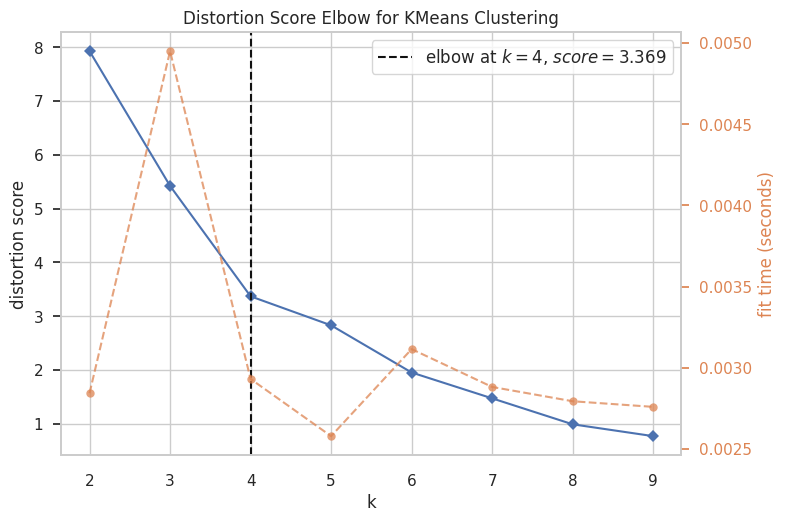

Optimal number of clusters (k): 4

Clustering with different methods...
Silhouette Score (KMeans, 2022): 0.3998086586685493
Silhouette Score (DBSCAN, 2022): 0.32894939167765347
Silhouette Score (Agglomerative, 2022): 0.3998086586685493
Best model for 2022: KMeans with silhouette score 0.3998086586685493


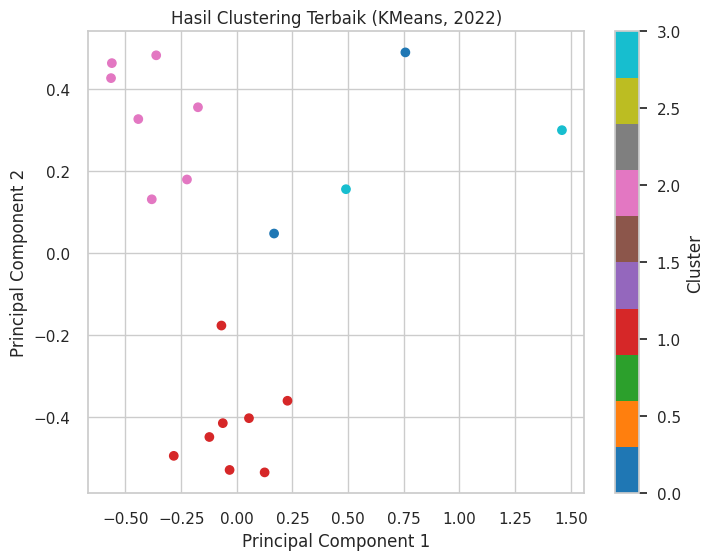

In [77]:
# Persiapan hasil clustering untuk setiap tahun
results_per_year = {}

for year in years:
    print(f"Processing year: {year}\n{'-'*40}")

    # Filter data untuk tahun tertentu
    df_year = df_cluster[df_cluster['Year'] == year][columns_to_use].copy()

    # Normalisasi data untuk feature numerik
    columns_to_scale = columns_to_use[1:]  # Kolom numerik
    scaler = MinMaxScaler()
    df_year[columns_to_scale] = scaler.fit_transform(df_year[columns_to_scale])

    # Output: Menampilkan data yang telah dinormalisasi
    print(f"Data for {year} after normalization:")
    display(df_year.head())

    # --- PCA untuk reduksi dimensi ---
    print("\nFinding optimal PCA components...")
    def find_optimal_pca_components(data, variance_threshold=0.9):
        pca_temp = PCA()
        pca_temp.fit(data)
        cumulative_variance = np.cumsum(pca_temp.explained_variance_ratio_)
        optimal_components = np.argmax(cumulative_variance >= variance_threshold) + 1

        # Plot explained variance
        plt.figure(figsize=(8, 6))
        plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
        plt.axhline(y=variance_threshold, color='r', linestyle='--', label=f'{variance_threshold*100}% variance threshold')
        plt.title(f"Explained Variance vs Number of PCA Components ({year})")
        plt.xlabel("Number of Components")
        plt.ylabel("Cumulative Explained Variance")
        plt.legend()
        plt.show()

        return optimal_components

    # Cari jumlah komponen optimal
    optimal_pca_components = find_optimal_pca_components(df_year[columns_to_scale])
    print(f"Optimal PCA components for {year}: {optimal_pca_components}")

    # Terapkan PCA
    pca = PCA(n_components=optimal_pca_components)
    X_pca = pca.fit_transform(df_year[columns_to_scale])

    print(f"PCA-transformed data for {year} (first 5 rows):")
    print(X_pca[:5])

    # Quick examination of elbow method to find numbers of clusters to make.
    print('Elbow Method to determine the number of clusters to be formed:')
    Elbow_M = KElbowVisualizer(KMeans(random_state=42), k=(2, 10))  # k=range untuk jumlah cluster
    Elbow_M.fit(X_pca)  # PCA_ds adalah dataset setelah PCA diterapkan
    Elbow_M.show()  # Menampilkan plot Elbow Method

    # Mendapatkan jumlah cluster optimal
    optimal_k = Elbow_M.elbow_value_
    print(f"Optimal number of clusters (k): {optimal_k}")

    # --- Clustering dengan Berbagai Metode ---
    print("\nClustering with different methods...")

    # KMeans
    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_pca)
    silhouette_kmeans = silhouette_score(X_pca, kmeans_labels)
    print(f"Silhouette Score (KMeans, {year}): {silhouette_kmeans}")

    # DBSCAN
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_pca)
    if len(set(dbscan_labels)) > 1:
        silhouette_dbscan = silhouette_score(X_pca, dbscan_labels)
        print(f"Silhouette Score (DBSCAN, {year}): {silhouette_dbscan}")
    else:
        silhouette_dbscan = -1
        print(f"DBSCAN failed to form clusters for {year}")

    # Agglomerative Clustering
    agg_clustering = AgglomerativeClustering(n_clusters=optimal_k)
    agg_labels = agg_clustering.fit_predict(X_pca)
    silhouette_agg = silhouette_score(X_pca, agg_labels)
    print(f"Silhouette Score (Agglomerative, {year}): {silhouette_agg}")

    # --- Pilih Model Terbaik ---
    best_model = max(
        [
            ('KMeans', silhouette_kmeans, kmeans_labels),
            ('DBSCAN', silhouette_dbscan, dbscan_labels),
            ('Agglomerative', silhouette_agg, agg_labels),
        ],
        key=lambda x: x[1]  # Pilih model dengan silhouette tertinggi
    )
    best_model_name, best_score, best_labels = best_model
    print(f"Best model for {year}: {best_model_name} with silhouette score {best_score}")

    # Tambahkan hasil clustering ke DataFrame
    df_year['Cluster_Best'] = best_labels

    # --- Simpan Hasil untuk Tahun Tersebut ---
    results_per_year[year] = {
        'data': df_year,
        'pca': X_pca,
        'best_model_name': best_model_name,
        'best_score': best_score,
        'best_labels': best_labels
    }

    # Visualisasi hasil clustering terbaik
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap=plt.cm.tab10)
    plt.title(f"Hasil Clustering Terbaik ({best_model_name}, {year})")
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.colorbar(label='Cluster')
    plt.show()

In [78]:
import plotly.graph_objects as go

# Warna hijau dari skala warna Viridis (atau bisa memilih skala warna lain yang dominan hijau)
colorscale = 'Greens'

for year in years:
    # Ambil hasil clustering terbaik dari tahun yang sedang diproses
    df_year = results_per_year[year]['data']
    best_labels = results_per_year[year]['best_labels']

    # Ubah hasil clustering menjadi kategori (misalnya menggunakan cluster label sebagai kategori)
    df_year['Cluster_Best'] = best_labels.astype(str)  # Ubah menjadi string untuk visualisasi kategori

    # Tambahkan label yang akan muncul di peta (misalnya, nama negara dan cluster)
    df_year['Label'] = df_year['Cluster_Best']

    # Visualisasi hasil clustering pada peta choropleth menggunakan go.Figure
    fig = go.Figure(data=go.Choropleth(
        locations=df_year['Country'],
        locationmode='country names',
        z=df_year['Cluster_Best'],
        text=df_year['Label'],  # Menampilkan label dengan negara dan cluster
        colorscale=colorscale,  # Warna Viridis (hijau)
        colorbar_title="Cluster",
        colorbar=dict(lenmode="fraction", len=0.5, y=0.5)  # Sesuaikan panjang dan posisi legenda
    ))

    # Tambahkan teks di peta untuk setiap negara tanpa legenda untuk trace ini
    for _, row in df_year.iterrows():
        fig.add_trace(go.Scattergeo(
            locationmode='country names',
            locations=[row['Country']],
            text=row['Label'],  # Menampilkan nama cluster dan negara
            mode='text',
            showlegend=False,  # Menyembunyikan legend untuk trace ini
            textfont=dict(color='black', size=10)  # Penyesuaian tampilan teks
        ))

    # Perbarui tata letak peta
    fig.update_layout(
        title=f"Hasil Clustering ({year}) - Visualisasi Choropleth",
        geo=dict(showcoastlines=True, coastlinecolor='Black', projection_type='natural earth')
    )

    fig.show()

In [79]:
# Analisis per cluster untuk setiap tahun
for year in years:
    print(f"\nCluster analysis for {year}:")

    # Ambil hasil clustering terbaik untuk tahun tersebut
    df_year = results_per_year[year]['data']

    # Pastikan cluster label diurutkan untuk iterasi
    for cluster_label in sorted(df_year['Cluster_Best'].unique()):
        # Ambil data negara-negara yang termasuk dalam cluster ini
        cluster_members = df_year[df_year['Cluster_Best'] == cluster_label]

        # Hitung rata-rata kondisi untuk setiap feature yang digunakan dalam clustering
        average_conditions = cluster_members[columns_to_scale].mean()

        # Menampilkan hasil analisis
        print(f"\nCluster {cluster_label}:")
        print("Countries:", cluster_members['Country'].tolist())
        print("Average conditions:")
        print(average_conditions)
        print("-" * 40)

    print("\n\n")  # Pemisah antar tahun



Cluster analysis for 2020:

Cluster 0:
Countries: ['Argentina', 'Australia', 'Brazil', 'Canada', 'Mexico', 'Russia', 'Saudi Arabia', 'South Africa', 'Türkiye']
Average conditions:
Real GDP (US dollars, PPP converted)                                                 0.050060
Employment in agriculture (Percentage of total employment) (modeled ILO estimate)    0.185714
Total energy supply (Tonnes of oil equivalent)                                       0.049359
Renewable energy supply (Tonnes of oil equivalent)                                   0.088018
Energy productivity, GDP per unit of TES (US dollars per tonne of oil equivalent)    0.343520
Non-energy material productivity, GDP per unit of DMC (US dollars per kilogramme)    0.196187
Purchasing power parity (National currency per US dollar)                            0.001632
Population density (Inhabitants per square kilometre)                                0.057202
Net migration (Persons)                                            

Berikut adalah ringkasan hasil analisis PCA dan klasterisasi untuk tahun 2020, 2021, dan 2022:

 Tahun 2020

**Komponen PCA Optimal untuk 2020:** 5  
**Data hasil transformasi PCA untuk 2020 (5 baris pertama):**
- Nilai PCA untuk data negara-negara pada tahun 2020 dalam 5 komponen utama.

**Jumlah klaster optimal (k):** 4  
**Hasil klasterisasi menggunakan berbagai metode:**
- **KMeans:** Skor Silhouette 0.33
- **DBSCAN:** Skor Silhouette 0.26
- **Agglomerative:** Skor Silhouette 0.36

**Model terbaik untuk 2020:** Agglomerative dengan skor silhouette 0.36.

**Analisis klaster untuk 2020:**
- **Klaster 0**: Negara-negara seperti Argentina, Australia, Brasil, Kanada, Meksiko, Rusia, Arab Saudi, Afrika Selatan, dan Turki. Ciri khasnya adalah GDP rendah, ketergantungan tinggi pada pertanian, serta penggunaan energi terbarukan yang lebih rendah.
- **Klaster 1**: Negara seperti India dan Indonesia dengan GDP yang lebih tinggi dibandingkan klaster 0, namun masih memiliki ketergantungan yang tinggi pada sektor pertanian dan energi terbarukan yang lebih banyak.
- **Klaster 2**: Negara-negara maju seperti Prancis, Jerman, Italia, Jepang, Korea Selatan, dan Inggris dengan GDP lebih tinggi, penggunaan energi yang efisien, serta tingkat produktivitas yang lebih baik.
- **Klaster 3**: Negara besar seperti Tiongkok dan Amerika Serikat, dengan GDP sangat tinggi, penggunaan energi yang besar, serta ketergantungan pada sektor pertanian yang lebih rendah.

---

 Tahun 2021

**Komponen PCA Optimal untuk 2021:** 5  
**Data hasil transformasi PCA untuk 2021 (5 baris pertama):**
- Nilai PCA untuk data negara-negara pada tahun 2021 dalam 5 komponen utama.

**Jumlah klaster optimal (k):** 4  
**Hasil klasterisasi menggunakan berbagai metode:**
- **KMeans:** Skor Silhouette 0.35
- **DBSCAN:** Skor Silhouette 0.28
- **Agglomerative:** Skor Silhouette 0.35

**Model terbaik untuk 2021:** KMeans dengan skor silhouette 0.35.

**Analisis klaster untuk 2021:**
- **Klaster 0**: Negara-negara seperti India dan Indonesia dengan ciri khas yang serupa dengan klaster sebelumnya, yakni GDP rendah, ketergantungan pada pertanian yang tinggi, dan pertumbuhan energi terbarukan.
- **Klaster 1**: Negara-negara seperti Argentina, Australia, Brasil, Kanada, Meksiko, Rusia, Arab Saudi, Afrika Selatan, dengan rata-rata kondisi yang mirip dengan 2020, namun dengan beberapa perubahan dalam faktor ekonomi dan energi.
- **Klaster 2**: Negara maju seperti Prancis, Jerman, Italia, Jepang, Korea Selatan, Turki, dan Inggris dengan ciri khas yang serupa dengan klaster 2020, termasuk GDP tinggi dan produktivitas energi yang efisien.
- **Klaster 3**: Negara-negara besar seperti Tiongkok dan Amerika Serikat, yang menunjukkan pola yang mirip dengan 2020, dengan GDP sangat tinggi dan ketergantungan lebih rendah pada sektor pertanian.

---

 Tahun 2022

**Komponen PCA Optimal untuk 2022:** 5  
**Data hasil transformasi PCA untuk 2022 (5 baris pertama):**
- Nilai PCA untuk data negara-negara pada tahun 2022 dalam 5 komponen utama.

**Jumlah klaster optimal (k):** 4  
**Hasil klasterisasi menggunakan berbagai metode:**
- **KMeans:** Skor Silhouette 0.40
- **DBSCAN:** Skor Silhouette 0.33
- **Agglomerative:** Skor Silhouette 0.40

**Model terbaik untuk 2022:** KMeans dengan skor silhouette 0.40.

**Analisis klaster untuk 2022:**
- **Klaster 0**: Negara seperti India dan Indonesia dengan pola yang mirip dengan tahun sebelumnya, menunjukkan ketergantungan tinggi pada sektor pertanian dan energi terbarukan.
- **Klaster 1**: Negara-negara seperti Argentina, Australia, Brasil, Kanada, Meksiko, Rusia, Arab Saudi, Afrika Selatan, dengan kondisi ekonomi dan energi yang berkembang lebih baik dibandingkan sebelumnya.
- **Klaster 2**: Negara-negara maju dengan GDP tinggi dan efisiensi energi yang lebih baik, mirip dengan pola pada tahun 2020 dan 2021.
- **Klaster 3**: Negara besar seperti Tiongkok dan Amerika Serikat, menunjukkan pola yang konsisten dengan tahun-tahun sebelumnya dengan GDP sangat tinggi dan penggunaan energi yang besar.

# **Business Solution (Rekomendasi)**
1. **Inovasi Pertanian**: Negara berkembang harus mengadopsi teknologi pertanian modern, seperti irigasi hemat air dan pertanian presisi. Negara maju harus lebih fokus pada pertanian berkelanjutan dan penggunaan energi terbarukan.
   
2. **Pertanian Milenial**: Generasi muda perlu terlibat dalam pertanian berbasis teknologi digital dan ramah lingkungan. Program pelatihan untuk petani muda harus didorong untuk menciptakan petani yang lebih terampil.

3. **Diversifikasi dan Keberlanjutan**: Negara dengan sektor pertanian besar harus mengeksplorasi pertanian organik dan energi terbarukan untuk mendukung ekonomi hijau.

4. **Kebijakan Pemerintah**: Pemerintah perlu memberikan insentif untuk riset dan pengembangan pertanian berkelanjutan, serta mendukung petani dengan kebijakan yang ramah lingkungan.

### Kesimpulan
Sektor pertanian masih relevan, namun harus bertransformasi dengan teknologi dan praktik hijau. Dengan dukungan teknologi dan kebijakan yang tepat, pertanian dapat beradaptasi dengan ekonomi hijau dan terus mendukung ketahanan pangan global.